# Baseline Classification for Parkinson's Disease (Acoustic Features Only)

**This is a standalone notebook with all dependencies included.**

## Overview

This notebook implements a baseline classification pipeline:
1. Data loading and preprocessing (static audio features only - no demographics)
2. Baseline classifier training on real data
3. Evaluation on test data

**All code is self-contained - no external dependencies on other notebooks.**


## 1. Setup and Imports

In [3]:
# ============================================================
# All Required Imports
# ============================================================

import os
import json
from pathlib import Path
from datetime import datetime
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

print("✓ All imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ All imports loaded successfully!
PyTorch version: 2.8.0+cu128
CUDA available: True


## 2. Configuration

In [4]:
# ============================================================
# Configuration
# ============================================================

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# Feature Selection: Phenotype vs Acoustic Only
# ============================================================
# Set to True to include phenotype/demographic features
# Set to False to use only acoustic/static features
USE_PHENOTYPE_FEATURES = False  # ACOUSTIC-ONLY VERSION

print("=" * 60)
print("FEATURE CONFIGURATION")
print("=" * 60)
if USE_PHENOTYPE_FEATURES:
    print("✓ Using: Phenotype/Demographic features + Acoustic features")
else:
    print("✓ Using: Acoustic features only (no phenotype/demographics)")
print("=" * 60)

# Paths
ROOT = Path.cwd()
DATA_PATH = ROOT / 'physionet.org' / 'files' / 'b2ai-voice' / '2.0.1'
OUTPUT_DIR = ROOT / 'outputs' / 'vae_standalone'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data files
PHENOTYPE_FILE = DATA_PATH / 'phenotype.tsv'
STATIC_FILE = DATA_PATH / 'static_features.tsv'

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"✓ Using CUDA: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("✓ Using MPS (Apple Silicon)")
else:
    DEVICE = torch.device('cpu')
    print("✓ Using CPU")

print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"Random seed: {SEED}")
print(f"Data path: {DATA_PATH}")

# Check file existence
print("\n" + "=" * 60)
print("File Existence Check")
print("=" * 60)
print(f"Phenotype file exists: {PHENOTYPE_FILE.exists()}")
print(f"Static features file exists: {STATIC_FILE.exists()}")
print("=" * 60)


FEATURE CONFIGURATION
✓ Using: Acoustic features only (no phenotype/demographics)
✓ Using CUDA: NVIDIA GeForce RTX 2080 Ti

Output directory: /home/Phenotype and Voice for PD/outputs/vae_standalone
Random seed: 42
Data path: /home/Phenotype and Voice for PD/physionet.org/files/b2ai-voice/2.0.1

File Existence Check
Phenotype file exists: True
Static features file exists: True


## 3. Data Loading and Label Creation

In [5]:
# ============================================================
# Load Data and Create Labels
# ============================================================

print("=" * 60)
print("LOADING DATA AND CREATING LABELS")
print("=" * 60)

# Load phenotype data
if not PHENOTYPE_FILE.exists():
    raise FileNotFoundError(f"Phenotype file not found: {PHENOTYPE_FILE}")

phenotype_df = pd.read_csv(PHENOTYPE_FILE, sep='\t', low_memory=False)
print(f"✓ Phenotype shape: {phenotype_df.shape}")

# Detect control and Parkinson's columns
control_col = None
for c in phenotype_df.columns:
    if "control" in c.lower() or "healthy" in c.lower():
        control_col = c
        break

if "parkinsons" in phenotype_df.columns:
    pd_col = "parkinsons"
elif "parkinson" in phenotype_df.columns:
    pd_col = "parkinson"
else:
    raise RuntimeError("Cannot detect Parkinson's column")

print(f"✓ Control column: {control_col}")
print(f"✓ Parkinson's column: {pd_col}")

# Create labels
phenotype_df['pd_label'] = phenotype_df[pd_col].astype(str).str.lower().eq("checked").astype(int)
phenotype_df['control_label'] = phenotype_df[control_col].astype(str).str.lower().eq("yes").astype(int)
phenotype_df['label'] = phenotype_df['pd_label']
phenotype_df.loc[phenotype_df['control_label'] == 1, 'label'] = 0

# Keep only Parkinsons and controls
phenotype_df = phenotype_df[(phenotype_df['pd_label'] == 1) | (phenotype_df['control_label'] == 1)]

print(f"\n✓ Label distribution:")
print(phenotype_df['label'].value_counts())

# ============================================================
# Prepare Screening Demographics (if USE_PHENOTYPE_FEATURES is True)
# ============================================================
if USE_PHENOTYPE_FEATURES:
    print("\n" + "=" * 60)
    print("PREPARING SCREENING DEMOGRAPHICS")
    print("=" * 60)
else:
    print("\n" + "=" * 60)
    print("SKIPPING PHENOTYPE FEATURES (Acoustic-only mode)")
    print("=" * 60)
    screening_cols_to_merge = []
    screening_categorical_vars = []
    screening_numeric_vars = []

if USE_PHENOTYPE_FEATURES:
    # Clean age
    if 'age' in phenotype_df.columns:
        def extract_age(value):
            if pd.isna(value):
                return np.nan
            value_str = str(value)
            if 'and above' in value_str.lower() or '90+' in value_str:
                return 90.0
            import re
            matches = re.findall(r'\b([1-9][0-9])\b', value_str)
            if matches:
                for match in matches:
                    age_val = float(match)
                    if 10 <= age_val <= 120:
                        return age_val
            try:
                age_val = float(value_str)
                if 10 <= age_val <= 120:
                    return age_val
            except:
                pass
            return np.nan
        
        phenotype_df['age_clean'] = phenotype_df['age'].apply(extract_age)
        phenotype_df['age_clean'] = pd.to_numeric(phenotype_df['age_clean'], errors='coerce')

    # Calculate BMI
    if 'weight' in phenotype_df.columns and 'height' in phenotype_df.columns:
        weight_data = pd.to_numeric(phenotype_df['weight'], errors='coerce')
        height_data = pd.to_numeric(phenotype_df['height'], errors='coerce')
        
        # Check units
        if 'unit' in phenotype_df.columns:
            units = phenotype_df['unit'].dropna().unique()
            use_metric = 'US customary units' not in str(units).lower() if len(units) > 0 else True
        else:
            use_metric = height_data.mean() > 100 if height_data.notna().any() else True
        
        # Convert to metric if needed
        if not use_metric:
            height_m = height_data * 0.0254  # inches to meters
            weight_kg = weight_data * 0.453592  # lbs to kg
        else:
            if height_data.mean() > 100:  # Likely cm
                height_m = height_data * 0.01  # cm to meters
            else:
                height_m = height_data
            weight_kg = weight_data
        
        # Calculate BMI
        bmi = weight_kg / (height_m ** 2)
        bmi = bmi[(bmi > 10) & (bmi < 60)]
        phenotype_df['bmi'] = np.nan
        phenotype_df.loc[bmi.index, 'bmi'] = bmi.values

    # Select screening variables to include
    # Note: Removed country, hydration_today, caffeine_intake_today
    # Note: Removed weight and height (keeping only BMI)
    screening_vars_to_include = {
        'age': 'age_clean' if 'age_clean' in phenotype_df.columns else 'age',
        'sex': 'sex_at_birth',
        'bmi': 'bmi',  # Only BMI, not weight/height separately
        'ethnicity': 'ethnicity',
        'alcohol_yn': 'alcohol_yn',
        'alcohol_freq': 'alcohol_freq',
        'alcohol_amt': 'alcohol_amt',
        'household_count': 'household_count',
        'caffeine_intake': 'caffeine_intake',  # Generic, not _today
        'hydration': 'hydration',  # Generic, not _today
        'tired_measure': 'tired_measure',
        'smoking_hx': 'smoking_hx',
    }

    # Create screening variables with prefix
    screening_cols_to_merge = []
    screening_categorical_vars = ['sex', 'ethnicity', 'alcohol_yn', 'alcohol_freq', 'alcohol_amt', 'smoking_hx']
    screening_numeric_vars = ['age', 'bmi', 'household_count', 'caffeine_intake', 'hydration', 'tired_measure']

    for var_name, col_name in screening_vars_to_include.items():
        if col_name in phenotype_df.columns:
            screening_var_name = f'screening_{var_name}'
            phenotype_df[screening_var_name] = phenotype_df[col_name]
            screening_cols_to_merge.append(screening_var_name)
            
            # Fill NaN values in screening variables before merging
            if var_name in screening_numeric_vars:
                # For numeric, fill with median or 0
                median_val = phenotype_df[screening_var_name].median()
                if pd.isna(median_val):
                    phenotype_df[screening_var_name] = phenotype_df[screening_var_name].fillna(0)
                else:
                    phenotype_df[screening_var_name] = phenotype_df[screening_var_name].fillna(median_val)
            # Categorical will be handled by encoding step below

    print(f"✓ Prepared {len(screening_cols_to_merge)} screening demographic variables")
    print(f"  Variables: {[v.replace('screening_', '') for v in screening_cols_to_merge]}")

    # ============================================================
    # Encode Categorical Screening Variables
    # ============================================================
    print("\n" + "=" * 60)
    print("ENCODING CATEGORICAL SCREENING VARIABLES")
    print("=" * 60)

    from sklearn.preprocessing import LabelEncoder

    # Store label encoders for potential inverse transform later
    screening_label_encoders = {}

    # For categorical variables, we'll use label encoding (convert to numeric)
    # This allows them to be included in the numeric feature matrix
    for var_name in screening_categorical_vars:
        screening_col = f'screening_{var_name}'
        if screening_col in phenotype_df.columns:
            # Fill missing values with 'unknown' before encoding
            nan_count = phenotype_df[screening_col].isna().sum()
            if nan_count > 0:
                print(f"  Filling {nan_count} NaN values in {var_name} with 'unknown'")
            phenotype_df[screening_col] = phenotype_df[screening_col].fillna('unknown')
            
            # Use label encoding to convert to numeric
            le = LabelEncoder()
            encoded_values = le.fit_transform(phenotype_df[screening_col].astype(str))
            phenotype_df[screening_col] = encoded_values
            
            # Store encoder for reference
            screening_label_encoders[screening_col] = le
            
            print(f"✓ Encoded {var_name}: {len(le.classes_)} unique values")
            print(f"  Classes: {list(le.classes_)[:5]}{'...' if len(le.classes_) > 5 else ''}")

    print(f"\n✓ Encoded {len(screening_label_encoders)} categorical screening variables")

# Load static features
if not STATIC_FILE.exists():
    raise FileNotFoundError(f"Static features file not found: {STATIC_FILE}")

static_df = pd.read_csv(STATIC_FILE, sep='\t', low_memory=False)
print(f"\n✓ Static features shape: {static_df.shape}")

# Merge datasets
merge_cols = ['participant_id', 'session_id']
if 'task_name' in static_df.columns and 'task_name' in phenotype_df.columns:
    merge_cols.append('task_name')

# Merge datasets (include screening demographics only if USE_PHENOTYPE_FEATURES is True)
if USE_PHENOTYPE_FEATURES:
    phenotype_cols_to_merge = merge_cols + ['label', 'pd_label'] + screening_cols_to_merge
else:
    # Acoustic-only mode: only merge labels, no screening demographics
    phenotype_cols_to_merge = merge_cols + ['label', 'pd_label']

merged_df = static_df.merge(
    phenotype_df[phenotype_cols_to_merge],
    on=merge_cols,
    how='inner'
)

print(f"\n✓ Merged dataset shape: {merged_df.shape}")
print(f"  Label distribution: {merged_df['label'].value_counts().to_dict()}")

# Verify both classes are present after merge
if 'label' in merged_df.columns:
    label_counts = merged_df['label'].value_counts()
    if 0 not in label_counts.index:
        raise ValueError("ERROR: No Control (0) samples after merge! Check merge keys.")
    if 1 not in label_counts.index:
        raise ValueError("ERROR: No Parkinson's (1) samples after merge! Check merge keys.")
    print(f"  ✓ Both classes present: Control={label_counts.get(0, 0)}, Parkinson's={label_counts.get(1, 0)}")

# Identify feature columns
id_cols = ['participant_id', 'session_id', 'task_name'] if 'task_name' in merged_df.columns else ['participant_id', 'session_id']
if 'transcription' in merged_df.columns:
    id_cols.append('transcription')
label_cols = ['label', 'pd_label', 'control_label']
feature_cols = [c for c in merged_df.columns if c not in id_cols + label_cols]

# Convert screening categorical variables to numeric if they're still object type after merge
# (Some might not have been encoded if they weren't in phenotype_df)
# Only do this if phenotype features are enabled
if USE_PHENOTYPE_FEATURES:
    for var_name in screening_categorical_vars:
        screening_col = f'screening_{var_name}'
        if screening_col in merged_df.columns:
            if merged_df[screening_col].dtype == 'object':
                # Fill missing and encode
                nan_count = merged_df[screening_col].isna().sum()
                if nan_count > 0:
                    print(f"  Post-merge: Filling {nan_count} NaN values in {var_name} with 'unknown'")
                merged_df[screening_col] = merged_df[screening_col].fillna('unknown').astype(str)
                # Use label encoder to convert to numeric
                le = LabelEncoder()
                merged_df[screening_col] = le.fit_transform(merged_df[screening_col])
                print(f"✓ Post-merge encoded {var_name}: {len(le.classes_)} unique values")
            
            # Also ensure numeric screening variables don't have NaN after merge
            elif var_name in screening_numeric_vars:
                nan_count = merged_df[screening_col].isna().sum()
                if nan_count > 0:
                    median_val = merged_df[screening_col].median()
                    if pd.isna(median_val):
                        merged_df[screening_col] = merged_df[screening_col].fillna(0)
                        print(f"  Post-merge: Filled {nan_count} NaN values in {var_name} with 0")
                    else:
                        merged_df[screening_col] = merged_df[screening_col].fillna(median_val)
                        print(f"  Post-merge: Filled {nan_count} NaN values in {var_name} with median={median_val:.2f}")

# Filter to numeric columns only (now includes encoded categoricals)
feature_cols = [c for c in feature_cols if merged_df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

print(f"\n✓ Number of feature columns: {len(feature_cols)}")

# Check how many screening demographics are included
screening_features_included = [c for c in feature_cols if c.startswith('screening_')]
print(f"✓ Screening demographics included: {len(screening_features_included)}")
if len(screening_features_included) > 0:
    print(f"  Screening features: {[c.replace('screening_', '') for c in screening_features_included[:10]]}")
    if len(screening_features_included) > 10:
        print(f"  ... and {len(screening_features_included) - 10} more")
    
    # Show breakdown by type
    numeric_screening = [c for c in screening_features_included if c.replace('screening_', '') in screening_numeric_vars]
    categorical_screening = [c for c in screening_features_included if c.replace('screening_', '') in screening_categorical_vars]
    print(f"  - Numeric: {len(numeric_screening)}")
    print(f"  - Categorical (encoded): {len(categorical_screening)}")

print("=" * 60)


LOADING DATA AND CREATING LABELS
✓ Phenotype shape: (442, 1109)
✓ Control column: is_control_participant
✓ Parkinson's column: parkinsons

✓ Label distribution:
label
0    64
1    61
Name: count, dtype: int64

SKIPPING PHENOTYPE FEATURES (Acoustic-only mode)

✓ Static features shape: (19271, 135)

✓ Merged dataset shape: (4879, 137)
  Label distribution: {1: 2441, 0: 2438}
  ✓ Both classes present: Control=2438, Parkinson's=2441

✓ Number of feature columns: 131
✓ Screening demographics included: 0


## 4. Data Preprocessing and Participant-Level Splits

In [6]:
# ============================================================
# Data Cleaning and Participant-Level Splits
# ============================================================

print("=" * 60)
print("DATA CLEANING & PARTICIPANT-LEVEL SPLITS")
print("=" * 60)

# Extract features and labels
X_full = merged_df[feature_cols].copy()
y_full = merged_df['label'].astype(int).copy()
pid_full = merged_df['participant_id'].astype(str).copy()

# Clean: handle NaN and Inf
X_full = X_full.replace([np.inf, -np.inf], np.nan)

# Handle missing values: fill with column means/medians
# For columns that are all NaN, fill with 0
for col in X_full.columns:
    if X_full[col].isna().all():
        # If entire column is NaN, fill with 0
        X_full[col].fillna(0, inplace=True)
        print(f"⚠ Warning: Column '{col}' was entirely NaN, filled with 0")
    elif X_full[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
        # For numeric columns, fill with median (more robust than mean)
        col_median = X_full[col].median()
        if pd.isna(col_median):
            # If median is also NaN, use 0
            X_full[col].fillna(0, inplace=True)
        else:
            X_full[col].fillna(col_median, inplace=True)
    else:
        # For non-numeric, fill with mode or 0
        mode_val = X_full[col].mode()
        if len(mode_val) > 0:
            X_full[col].fillna(mode_val.iloc[0], inplace=True)
        else:
            X_full[col].fillna(0, inplace=True)

# Verify no NaN/Inf remain
remaining_nan = X_full.isna().sum().sum()
remaining_inf = np.isinf(X_full.select_dtypes(include=[np.number])).sum().sum()
if remaining_nan > 0 or remaining_inf > 0:
    print(f"⚠ Warning: Still have {remaining_nan} NaN and {remaining_inf} Inf values after cleaning")
    # Force fill any remaining NaN/Inf with 0
    X_full = X_full.fillna(0)
    X_full = X_full.replace([np.inf, -np.inf], 0)

# Participant-level splits (no data leakage)
unique_participants = pid_full.unique()
participant_labels = merged_df.groupby('participant_id')['label'].first()

# Split participants (not recordings)
pids_train_val, pids_test, y_p_train_val, y_p_test = train_test_split(
    unique_participants,
    participant_labels.loc[unique_participants],
    test_size=0.2,
    random_state=SEED,
    stratify=participant_labels.loc[unique_participants]
)

pids_train, pids_val, y_p_train, y_p_val = train_test_split(
    pids_train_val,
    y_p_train_val,
    test_size=0.2,
    random_state=SEED,
    stratify=y_p_train_val
)

# Map participant splits to recording level
train_mask = pid_full.isin(pids_train)
val_mask = pid_full.isin(pids_val)
test_mask = pid_full.isin(pids_test)

X_train_raw = X_full[train_mask].copy()
X_val_raw = X_full[val_mask].copy()
X_test_raw = X_full[test_mask].copy()

y_train_raw = y_full[train_mask].copy()
y_val_raw = y_full[val_mask].copy()
y_test_raw = y_full[test_mask].copy()

# Extract participant IDs for each split (CRITICAL for participant-level CV)
pid_train = pid_full[train_mask].values
pid_val = pid_full[val_mask].values
pid_test = pid_full[test_mask].values

print(f"\n✓ Recording-level splits:")
print(f"  Train: {len(X_train_raw)} ({y_train_raw.value_counts().to_dict()})")
print(f"  Val:   {len(X_val_raw)} ({y_val_raw.value_counts().to_dict()})")
print(f"  Test:  {len(X_test_raw)} ({y_test_raw.value_counts().to_dict()})")
print(f"\n✓ Unique participants per split:")
print(f"  Train: {len(np.unique(pid_train))}, Val: {len(np.unique(pid_val))}, Test: {len(np.unique(pid_test))}")

# Standardize using training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw.values.astype(np.float32))
X_val_scaled = scaler.transform(X_val_raw.values.astype(np.float32))
X_test_scaled = scaler.transform(X_test_raw.values.astype(np.float32))

# Clip extreme values
X_train_scaled = np.clip(X_train_scaled, -8.0, 8.0)
X_val_scaled = np.clip(X_val_scaled, -8.0, 8.0)
X_test_scaled = np.clip(X_test_scaled, -8.0, 8.0)

# Convert to DataFrames
X_train = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train_raw.index)
X_val = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val_raw.index)
X_test = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test_raw.index)

# Store global scaler for later use
global_scaler = scaler

feature_dim = len(feature_cols)
input_dim = feature_dim

print(f"\n✓ Feature dimension: {feature_dim}")
print(f"✓ Data cleaned and standardized")
print("=" * 60)


DATA CLEANING & PARTICIPANT-LEVEL SPLITS

✓ Recording-level splits:
  Train: 3071 ({1: 1557, 0: 1514})
  Val:   832 ({1: 421, 0: 411})
  Test:  976 ({0: 513, 1: 463})

✓ Unique participants per split:
  Train: 80, Val: 20, Test: 25

✓ Feature dimension: 131
✓ Data cleaned and standardized


## 5. Baseline Classifier Architecture

In [7]:
# ============================================================
# Baseline Classifier: RegularizedHybridNet
# ============================================================

class RegularizedHybridNet(nn.Module):
    """
    Regularized Hybrid Network for binary classification.
    Updated with increased dropout to reduce overfitting.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.fc_in = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.50),  # Increased from 0.35 to reduce overfitting
        )
        self.block1 = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.50),  # Increased from 0.35
        )
        self.block2 = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.50),  # Increased from 0.35
        )
        self.block3 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.45),  # Increased from 0.35
        )
        self.block4 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.40),  # Increased from 0.30
        )
        self.block5 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.35),  # Increased from 0.25
        )
        self.fc_out = nn.Linear(128, 1)
    
    def forward(self, x):
        x = self.fc_in(x)
        x = x + self.block1(x)
        x = x + self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        return self.fc_out(x).squeeze(1)

print("✓ RegularizedHybridNet defined")
test_model = RegularizedHybridNet(input_dim)
total_params = sum(p.numel() for p in test_model.parameters())
print(f"  Total parameters: {total_params:,}")
del test_model


✓ RegularizedHybridNet defined
  Total parameters: 2,931,457


## 6. Training Functions

In [8]:
# ============================================================
# Baseline Classifier Training Function
# ============================================================
import copy  # For proper model state deepcopy

def train_model_with_checkpointing(
    model, train_loader, val_loader,
    epochs=100, lr=6e-4, weight_decay=8e-3,  # Further reduced LR, increased weight decay
    min_delta=1e-4, gradient_clip=0.5,  # Reduced gradient clip for more stable gradients
    use_data_augmentation=True, noise_std=0.01,  # Reduced noise (was 0.03)
    label_smoothing=0.1,  # Add label smoothing to reduce overconfidence
    patience=6  # Early stopping patience
):
    """Train baseline classifier with checkpointing."""
    model = model.to(DEVICE)
    # Use label smoothing to reduce overconfidence and overfitting
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Use OneCycleLR for better convergence
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.2
    )
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'learning_rate': [],  # Fixed: added missing comma
        'val_roc_auc': [],  # Track validation ROC-AUC
    }
    
    best_val_roc_auc = -1.0  # Track best ROC-AUC (higher is better)
    best_model_state = None
    best_epoch = 0
    no_improve = 0  # Early stopping counter
    
    print(f"Training on device: {DEVICE}")
    print(f"Epochs: {epochs}, LR: {lr:.0e}, Weight decay: {weight_decay:.0e}")
    print("=" * 60)
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0
        running_correct = 0
        total = 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            # Squeeze labels to match logits shape (batch_size, 1) -> (batch_size,)
            yb = yb.squeeze(1) if yb.dim() > 1 else yb
            
            if use_data_augmentation and model.training:
                noise = torch.randn_like(xb) * noise_std
                xb = xb + noise
            
            optimizer.zero_grad()
            logits = model(xb)
            
            # Apply label smoothing if specified
            if label_smoothing > 0:
                # Smooth labels: 0 -> label_smoothing, 1 -> 1-label_smoothing
                yb_smooth = yb.float() * (1 - 2 * label_smoothing) + label_smoothing
                loss = criterion(logits, yb_smooth)
            else:
                loss = criterion(logits, yb.float())
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
            scheduler.step()  # Step scheduler per batch (OneCycleLR requirement)
            
            running_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            running_correct += (preds == yb).sum().item()
            total += xb.size(0)
        
        train_loss = running_loss / total
        train_acc = running_correct / total
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_all_probs = []
        val_all_labels = []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                
                # Squeeze labels to match logits shape (batch_size, 1) -> (batch_size,)
                yb = yb.squeeze(1) if yb.dim() > 1 else yb
                
                logits = model(xb)
                loss = criterion(logits, yb.float())
                val_loss += loss.item() * xb.size(0)
                preds = (torch.sigmoid(logits) >= 0.5).float()
                val_correct += (preds == yb).sum().item()
                # Get predictions and probabilities for ROC-AUC
                probs = torch.sigmoid(logits).cpu().numpy().flatten()
                preds = (probs >= 0.5).astype(int)  # Use numpy .astype() not .float()
                yb_np = yb.cpu().numpy()
                
                # Store for ROC-AUC calculation
                val_all_probs.extend(probs)
                val_all_labels.extend(yb_np)
                val_total += xb.size(0)
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        # Calculate validation ROC-AUC
        val_y_true = np.array(val_all_labels)
        val_y_probs = np.array(val_all_probs)
        if len(np.unique(val_y_true)) > 1:
            val_roc_auc = roc_auc_score(val_y_true, val_y_probs)
        else:
            val_roc_auc = 0.0  # Handle edge case with single class
        
        
        current_lr = optimizer.param_groups[0]['lr']
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_roc_auc'].append(val_roc_auc)
        history['learning_rate'].append(current_lr)
        
        # Select best model based on Validation ROC-AUC (higher is better)
        if val_roc_auc > best_val_roc_auc + min_delta:
            best_val_roc_auc = val_roc_auc
            best_model_state = copy.deepcopy(model.state_dict())  # Fixed: use deepcopy
            best_epoch = epoch
            no_improve = 0  # Reset counter on improvement
        else:
            no_improve += 1
            # Early stopping
            if no_improve >= patience:
                print(f"\n⏹ Early stopping at epoch {epoch+1}. Best epoch: {best_epoch+1} (AUC {best_val_roc_auc:.4f})")
                break
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}: "
                  f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
                  f"train_acc={train_acc:.3f}, val_acc={val_acc:.3f}, "
                  f"val_roc_auc={val_roc_auc:.4f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Loaded best model from epoch {best_epoch + 1} (Val ROC-AUC: {best_val_roc_auc:.4f})")
    
    return model, history, best_epoch

print("✓ Baseline training function defined")


✓ Baseline training function defined


## 7. Evaluation Functions

In [9]:
# ============================================================
# Evaluation Function
# ============================================================

def find_best_threshold(model, loader):
    """Find optimal threshold on validation set based on F1 score."""
    from sklearn.metrics import f1_score
    model.eval()
    probs, ys = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.squeeze(1).cpu().numpy().astype(int)
            p = torch.sigmoid(model(xb)).cpu().numpy().flatten()
            probs.append(p)
            ys.append(yb)
    probs = np.concatenate(probs)
    ys = np.concatenate(ys)
    
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 19):
        pred = (probs >= t).astype(int)
        f1 = f1_score(ys, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def evaluate_on_real(model, loader, threshold=0.5):
    """Evaluate model on real data with configurable threshold."""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            
            # Squeeze labels if needed
            yb = yb.squeeze(1) if yb.dim() > 1 else yb
            
            logits = model(xb)
            if logits.ndim > 1:
                logits = logits.squeeze(-1)
            
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy().ravel())
            all_labels.append(yb.cpu().numpy().ravel())
    
    y_prob = np.concatenate(all_probs).astype(float)
    y_true = np.concatenate(all_labels).astype(int)
    
    mask = np.isfinite(y_prob)
    if not np.all(mask):
        y_prob = y_prob[mask]
        y_true = y_true[mask]
    
    y_pred = (y_prob >= threshold).astype(int)  # Use configurable threshold
    
    acc = accuracy_score(y_true, y_pred)
    
    if len(np.unique(y_true)) < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(y_true, y_prob)
    
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Calculate precision and recall
    if len(np.unique(y_true)) < 2:
        prec = np.nan
        rec = np.nan
    else:
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
    
    return {
        'accuracy': acc,
        'roc_auc': auc,
        'f1': f1,
        'precision': prec,
        'recall': rec
    }

print("✓ Evaluation function defined")


✓ Evaluation function defined


## 8. Neural Network: Baseline Experiment

In [10]:
# ============================================================
# Device Selection with Safe CPU Fallback
# ============================================================

def get_device():
    # Try to use CUDA if available, otherwise CPU
    if torch.cuda.is_available():
        try:
            device = torch.device("cuda")
            # Try a tiny allocation to check if CUDA is actually usable
            _ = torch.tensor([0.0], device=device)
            print("✅ Using CUDA GPU")
            return device
        except RuntimeError as e:
            # If OOM or other CUDA error, fall back to CPU
            print(f"⚠️ CUDA error ({e}); falling back to CPU.")
            return torch.device("cpu")
    else:
        print("⚠️ CUDA not available, using CPU.")
        return torch.device("cpu")

DEVICE = get_device()
print("Final DEVICE:", DEVICE)

✅ Using CUDA GPU
Final DEVICE: cuda


In [11]:
# ============================================================
# Experiment 0: Train on Real Data (Baseline)
# ============================================================

print("=" * 60)
print("EXPERIMENT 0: Train on REAL Training Data → Test on REAL Test Data")
print("=" * 60)

# Prepare real training and validation data loaders
from sklearn.preprocessing import StandardScaler

X_train_np_real = X_train.values.astype(np.float32)
y_train_np_real = y_train_raw.values.astype(int).astype(np.float32)

# Clean: remove NaN/Inf
train_finite_mask = np.isfinite(X_train_np_real).all(axis=1) & np.isfinite(y_train_np_real)
X_train_np_real = X_train_np_real[train_finite_mask]
y_train_np_real = y_train_np_real[train_finite_mask]

# Prepare validation data
X_val_np_real = X_val.values.astype(np.float32)
y_val_np_real = y_val_raw.values.astype(int).astype(np.float32)

val_finite_mask = np.isfinite(X_val_np_real).all(axis=1) & np.isfinite(y_val_np_real)
X_val_np_real = X_val_np_real[val_finite_mask]
y_val_np_real = y_val_np_real[val_finite_mask]

# Standardize features (fit on train, transform train/val/test)
scaler = StandardScaler()
X_train_np_real = scaler.fit_transform(X_train_np_real)
X_val_np_real = scaler.transform(X_val_np_real)

print(f"Training samples: {len(X_train_np_real)}")
print(f"  - Control (0): {(y_train_np_real == 0).sum()}")
print(f"  - Parkinson's (1): {(y_train_np_real == 1).sum()}")

print(f"\nValidation samples: {len(X_val_np_real)}")
print(f"  - Control (0): {(y_val_np_real == 0).sum()}")
print(f"  - Parkinson's (1): {(y_val_np_real == 1).sum()}")

# Create DataLoaders
train_tensor_x = torch.tensor(X_train_np_real, dtype=torch.float32)
train_tensor_y = torch.tensor(y_train_np_real.reshape(-1, 1), dtype=torch.float32)

val_tensor_x = torch.tensor(X_val_np_real, dtype=torch.float32)
val_tensor_y = torch.tensor(y_val_np_real.reshape(-1, 1), dtype=torch.float32)

train_dataset = TensorDataset(train_tensor_x, train_tensor_y)
val_dataset = TensorDataset(val_tensor_x, val_tensor_y)

train_loader_real = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader_real = DataLoader(val_dataset, batch_size=128, shuffle=False)

# Prepare test loader (reuse from Experiment 1 setup, but create it here if not already defined)
# Prepare test data with standardization
if 'test_loader' not in globals():
    X_test_np = X_test.values.astype(np.float32)
    # Standardize test data using the same scaler fitted on training data
    X_test_np = scaler.transform(X_test_np)
    X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_raw.values.reshape(-1, 1), dtype=torch.float32)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Create and train model
print("\nTraining baseline model on real data...")

# nn_best_params should be set by grid search in section 8.0
# If grid search hasn't been run, use default parameters as fallback
if 'nn_best_params' not in globals() or nn_best_params is None:
    print("⚠ Grid search not run yet. Using default parameters.")
    nn_best_params = {
        'lr': 6e-4,
        'weight_decay': 8e-3,
        'noise_std': 0.01,
        'label_smoothing': 0.1,
        'gradient_clip': 0.5
    }
else:
    print(f"✓ Using grid search parameters: {nn_best_params}")

model_real_baseline = RegularizedHybridNet(input_dim).to(DEVICE)

model_real_baseline, hist_real_baseline, best_epoch_real_baseline = train_model_with_checkpointing(
    model_real_baseline,
    train_loader=train_loader_real,
    val_loader=val_loader_real,
    epochs=40,
    lr=nn_best_params['lr'],
    weight_decay=nn_best_params['weight_decay'],
    use_data_augmentation=True,
    noise_std=nn_best_params['noise_std'],
    label_smoothing=nn_best_params['label_smoothing'],
    gradient_clip=nn_best_params['gradient_clip'],
    patience=6  # Early stopping patience
)

# Find best threshold on validation set
print("\n" + "=" * 60)
print("TUNING THRESHOLD ON VALIDATION SET")
print("=" * 60)
best_threshold, best_val_f1 = find_best_threshold(model_real_baseline, val_loader_real)
print(f"Best threshold on validation: {best_threshold:.3f} (val F1={best_val_f1:.4f})")

# Evaluate on real test data with optimal threshold
print("\n" + "=" * 60)
print("EVALUATING ON REAL TEST DATA")
print("=" * 60)

metrics_real_baseline = evaluate_on_real(model_real_baseline, test_loader, threshold=best_threshold)

print("\nPerformance on REAL test data (trained on REAL training data - Baseline):")
for k, v in metrics_real_baseline.items():
    print(f"  {k}: {v:.4f}")
print(f"  (using threshold: {best_threshold:.3f})")

print("=" * 60)


EXPERIMENT 0: Train on REAL Training Data → Test on REAL Test Data
Training samples: 3071
  - Control (0): 1514
  - Parkinson's (1): 1557

Validation samples: 832
  - Control (0): 411
  - Parkinson's (1): 421

Training baseline model on real data...
⚠ Grid search not run yet. Using default parameters.
Training on device: cuda
Epochs: 40, LR: 6e-04, Weight decay: 8e-03
Epoch   1/40: train_loss=0.7110, val_loss=0.6906, train_acc=0.506, val_acc=0.477, val_roc_auc=0.5478
Epoch  10/40: train_loss=0.5359, val_loss=0.6525, train_acc=0.801, val_acc=0.659, val_roc_auc=0.7214

⏹ Early stopping at epoch 17. Best epoch: 11 (AUC 0.7530)

✓ Loaded best model from epoch 11 (Val ROC-AUC: 0.7530)

TUNING THRESHOLD ON VALIDATION SET
Best threshold on validation: 0.400 (val F1=0.7159)

EVALUATING ON REAL TEST DATA

Performance on REAL test data (trained on REAL training data - Baseline):
  accuracy: 0.6793
  roc_auc: 0.7653
  f1: 0.7173
  precision: 0.6165
  recall: 0.8575
  (using threshold: 0.400)


### 8.1. Neural Network: Hyperparameter Grid Search


In [12]:
# ============================================================
# Neural Network: Default Parameters
# ============================================================

print("=" * 60)
print("NEURAL NETWORK: DEFAULT PARAMETERS")
print("=" * 60)

# Set default parameters for Neural Network
nn_best_params = {
    'lr': 6e-4,
    'weight_decay': 8e-3,
    'noise_std': 0.01,
    'label_smoothing': 0.1,
    'gradient_clip': 0.5
}

print(f"\nUsing default parameters: {nn_best_params}")
print(f"\n✓ Parameters stored in 'nn_best_params' for use in 5-fold CV and final training")
print("=" * 60)


NEURAL NETWORK: DEFAULT PARAMETERS

Using default parameters: {'lr': 0.0006, 'weight_decay': 0.008, 'noise_std': 0.01, 'label_smoothing': 0.1, 'gradient_clip': 0.5}

✓ Parameters stored in 'nn_best_params' for use in 5-fold CV and final training


## 8.2. Neural Network: Cross-Validation Functions


In [13]:
# ============================================================
# Cross-Validation Functions (Participant-Level)
# ============================================================

from sklearn.model_selection import StratifiedKFold
from collections import defaultdict

def participant_level_cross_validation(
    X_full, y_full, pid_full, 
    n_splits=5,
    epochs=40,
    lr=6e-4,
    weight_decay=8e-3,
    use_data_augmentation=True,
    noise_std=0.01,
    label_smoothing=0.1,
    patience=6,
    verbose=True
):
    """
    Perform participant-level stratified k-fold cross-validation.
    
    This ensures no data leakage by splitting at the participant level,
    not the recording level.
    """
    print("=" * 60)
    print(f"PARTICIPANT-LEVEL {n_splits}-FOLD CROSS-VALIDATION")
    print("=" * 60)
    
    # Get unique participants and their labels
    # Ensure pid_full and y_full are aligned (convert to numpy for grouping)
    pid_full_np = pid_full.values if isinstance(pid_full, pd.Series) else pid_full
    y_full_np = y_full.values if isinstance(y_full, pd.Series) else y_full
    
    # Create a DataFrame to group by participant
    df_temp = pd.DataFrame({
        'participant_id': pid_full_np,
        'label': y_full_np
    })
    
    # Get unique participants and their labels (use first label per participant)
    participant_df = df_temp.groupby('participant_id')['label'].first().reset_index()
    unique_participants = participant_df['participant_id'].values
    participant_labels = participant_df['label'].values
    
    # Verify we have participants
    if len(unique_participants) == 0:
        raise ValueError("ERROR: No unique participants found! Check pid_full and y_full alignment.")
    if len(unique_participants) < n_splits:
        raise ValueError(f"ERROR: Only {len(unique_participants)} unique participants, but need at least {n_splits} for {n_splits}-fold CV!")
    
    print(f"✓ Found {len(unique_participants)} unique participants")
    print(f"  Label distribution: {pd.Series(participant_labels).value_counts().to_dict()}")
    
    # Create participant-level k-fold splitter
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    # Store results for each fold
    cv_results = {
        'fold': [],
        'train_acc': [],
        'val_acc': [],
        'val_roc_auc': [],
        'val_f1': [],
        'test_acc': [],
        'test_roc_auc': [],
        'test_f1': [],
        'best_epoch': [],
        'best_threshold': []
    }
    
    fold_models = []
    fold_histories = []
    
    for fold, (train_pid_idx, val_pid_idx) in enumerate(skf.split(unique_participants, participant_labels)):
        print(f"\n{'='*60}")
        print(f"FOLD {fold + 1}/{n_splits}")
        print(f"{'='*60}")
        
        # Get participant IDs for this fold
        train_pids = unique_participants[train_pid_idx]
        val_pids = unique_participants[val_pid_idx]
        
        # Map to recording level (use numpy version)
        pid_full_np = pid_full.values if isinstance(pid_full, pd.Series) else pid_full
        train_mask = np.isin(pid_full_np, train_pids)
        val_mask = np.isin(pid_full_np, val_pids)
        
        # Split train into train/val for early stopping
        # Use 80% of train_pids for training, 20% for validation
        train_pids_subset = unique_participants[train_pid_idx]
        train_pids_subset_labels = participant_labels[train_pid_idx]
        
        train_pids_train, train_pids_val, _, _ = train_test_split(
            train_pids_subset,
            train_pids_subset_labels,
            test_size=0.2,
            random_state=SEED,
            stratify=train_pids_subset_labels
        )
        
        # Create masks (use numpy version for consistency)
        pid_full_np = pid_full.values if isinstance(pid_full, pd.Series) else pid_full
        train_mask_final = np.isin(pid_full_np, train_pids_train)
        val_mask_final = np.isin(pid_full_np, train_pids_val)
        test_mask_final = np.isin(pid_full_np, val_pids)  # This is the CV test set
        
        # Extract data
        # Convert to numpy if needed
        if isinstance(X_full, pd.DataFrame):
            X_train_cv = X_full.loc[train_mask_final].values.astype(np.float32)
            X_val_cv = X_full.loc[val_mask_final].values.astype(np.float32)
            X_test_cv = X_full.loc[test_mask_final].values.astype(np.float32)
        else:
            X_train_cv = X_full[train_mask_final].astype(np.float32)
            X_val_cv = X_full[val_mask_final].astype(np.float32)
            X_test_cv = X_full[test_mask_final].astype(np.float32)
        
        if isinstance(y_full, pd.Series):
            y_train_cv = y_full.loc[train_mask_final].values.astype(int)
            y_val_cv = y_full.loc[val_mask_final].values.astype(int)
            y_test_cv = y_full.loc[test_mask_final].values.astype(int)
        else:
            y_train_cv = y_full[train_mask_final].astype(int)
            y_val_cv = y_full[val_mask_final].astype(int)
            y_test_cv = y_full[test_mask_final].astype(int)
        
        # Standardize
        scaler_cv = StandardScaler()
        X_train_cv = scaler_cv.fit_transform(X_train_cv)
        X_val_cv = scaler_cv.transform(X_val_cv)
        X_test_cv = scaler_cv.transform(X_test_cv)
        
        # Clip extreme values
        X_train_cv = np.clip(X_train_cv, -8.0, 8.0)
        X_val_cv = np.clip(X_val_cv, -8.0, 8.0)
        X_test_cv = np.clip(X_test_cv, -8.0, 8.0)
        
        print(f"Train: {len(X_train_cv)} samples ({np.sum(y_train_cv == 0)} Control, {np.sum(y_train_cv == 1)} PD)")
        print(f"Val (for early stopping): {len(X_val_cv)} samples ({np.sum(y_val_cv == 0)} Control, {np.sum(y_val_cv == 1)} PD)")
        print(f"Test (CV fold): {len(X_test_cv)} samples ({np.sum(y_test_cv == 0)} Control, {np.sum(y_test_cv == 1)} PD)")
        
        # Create data loaders
        train_dataset_cv = TensorDataset(
            torch.tensor(X_train_cv, dtype=torch.float32),
            torch.tensor(y_train_cv.reshape(-1, 1), dtype=torch.float32)
        )
        val_dataset_cv = TensorDataset(
            torch.tensor(X_val_cv, dtype=torch.float32),
            torch.tensor(y_val_cv.reshape(-1, 1), dtype=torch.float32)
        )
        test_dataset_cv = TensorDataset(
            torch.tensor(X_test_cv, dtype=torch.float32),
            torch.tensor(y_test_cv.reshape(-1, 1), dtype=torch.float32)
        )
        
        train_loader_cv = DataLoader(train_dataset_cv, batch_size=128, shuffle=True)
        val_loader_cv = DataLoader(val_dataset_cv, batch_size=128, shuffle=False)
        test_loader_cv = DataLoader(test_dataset_cv, batch_size=128, shuffle=False)
        
        # Train model
        model_cv = RegularizedHybridNet(input_dim).to(DEVICE)
        model_cv, hist_cv, best_epoch_cv = train_model_with_checkpointing(
            model_cv,
            train_loader=train_loader_cv,
            val_loader=val_loader_cv,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            use_data_augmentation=use_data_augmentation,
            noise_std=noise_std,
            label_smoothing=label_smoothing,
            patience=patience
        )
        
        # Find best threshold on validation set
        best_threshold_cv, best_val_f1_cv = find_best_threshold(model_cv, val_loader_cv)
        
        # Evaluate on validation set
        metrics_val_cv = evaluate_on_real(model_cv, val_loader_cv, threshold=best_threshold_cv)
        
        # Evaluate on test set (CV fold)
        metrics_test_cv = evaluate_on_real(model_cv, test_loader_cv, threshold=best_threshold_cv)
        
        # Store results
        cv_results['fold'].append(fold + 1)
        cv_results['train_acc'].append(hist_cv['train_acc'][-1])
        cv_results['val_acc'].append(metrics_val_cv['accuracy'])
        cv_results['val_roc_auc'].append(metrics_val_cv['roc_auc'])
        cv_results['val_f1'].append(metrics_val_cv['f1'])
        cv_results['test_acc'].append(metrics_test_cv['accuracy'])
        cv_results['test_roc_auc'].append(metrics_test_cv['roc_auc'])
        cv_results['test_f1'].append(metrics_test_cv['f1'])
        cv_results['best_epoch'].append(best_epoch_cv + 1)
        cv_results['best_threshold'].append(best_threshold_cv)
        
        fold_models.append(model_cv)
        fold_histories.append(hist_cv)
        
        if verbose:
            print(f"\nFold {fold + 1} Results:")
            print(f"  Validation - Acc: {metrics_val_cv['accuracy']:.4f}, ROC-AUC: {metrics_val_cv['roc_auc']:.4f}, F1: {metrics_val_cv['f1']:.4f}")
            print(f"  Test (CV)   - Acc: {metrics_test_cv['accuracy']:.4f}, ROC-AUC: {metrics_test_cv['roc_auc']:.4f}, F1: {metrics_test_cv['f1']:.4f}")
            print(f"  Best epoch: {best_epoch_cv + 1}, Best threshold: {best_threshold_cv:.3f}")
    
    # Calculate summary statistics
    print(f"\n{'='*60}")
    print("CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    
    cv_summary = {
        'metric': [],
        'mean': [],
        'std': [],
        'min': [],
        'max': []
    }
    
    for metric in ['val_acc', 'val_roc_auc', 'val_f1', 'test_acc', 'test_roc_auc', 'test_f1']:
        values = np.array(cv_results[metric])
        cv_summary['metric'].append(metric)
        cv_summary['mean'].append(np.mean(values))
        cv_summary['std'].append(np.std(values))
        cv_summary['min'].append(np.min(values))
        cv_summary['max'].append(np.max(values))
    
    cv_summary_df = pd.DataFrame(cv_summary)
    print("\nValidation Set Metrics:")
    print(cv_summary_df[cv_summary_df['metric'].str.startswith('val_')].to_string(index=False))
    print("\nTest Set (CV) Metrics:")
    print(cv_summary_df[cv_summary_df['metric'].str.startswith('test_')].to_string(index=False))
    
    return {
        'results': cv_results,
        'summary': cv_summary_df,
        'models': fold_models,
        'histories': fold_histories
    }

print("✓ Cross-validation function defined")


✓ Cross-validation function defined


In [14]:
# ============================================================
# Feature Importance Analysis
# ============================================================

def compute_feature_importance(model, X, y, feature_cols, n_iterations=10):
    """
    Compute feature importance using permutation importance.
    """
    print("=" * 60)
    print("COMPUTING FEATURE IMPORTANCE (Permutation Importance)")
    print("=" * 60)
    
    model.eval()
    baseline_probs = []
    baseline_labels = []
    
    # Get baseline predictions
    with torch.no_grad():
        X_tensor = torch.tensor(X.astype(np.float32), dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        baseline_probs = probs
        baseline_labels = y
    
    baseline_auc = roc_auc_score(baseline_labels, baseline_probs)
    
    # Permute each feature and measure impact
    importance_scores = []
    
    for i, feat_name in enumerate(feature_cols):
        if i % 20 == 0:
            print(f"  Processing feature {i+1}/{len(feature_cols)}: {feat_name}")
        
        # Permute feature multiple times and average
        permuted_aucs = []
        for _ in range(n_iterations):
            X_permuted = X.copy()
            np.random.shuffle(X_permuted[:, i])
            
            with torch.no_grad():
                X_tensor = torch.tensor(X_permuted.astype(np.float32), dtype=torch.float32).to(DEVICE)
                logits = model(X_tensor)
                probs = torch.sigmoid(logits).cpu().numpy().flatten()
            
            permuted_auc = roc_auc_score(baseline_labels, probs)
            permuted_aucs.append(permuted_auc)
        
        # Importance = drop in performance
        importance = baseline_auc - np.mean(permuted_aucs)
        importance_scores.append({
            'feature': feat_name,
            'importance': importance,
            'baseline_auc': baseline_auc,
            'permuted_auc_mean': np.mean(permuted_aucs),
            'permuted_auc_std': np.std(permuted_aucs)
        })
    
    importance_df = pd.DataFrame(importance_scores)
    importance_df = importance_df.sort_values('importance', ascending=False)
    
    print(f"\n✓ Computed importance for {len(feature_cols)} features")
    print(f"  Baseline AUC: {baseline_auc:.4f}")
    print(f"\nTop 10 Most Important Features:")
    print(importance_df.head(10)[['feature', 'importance']].to_string(index=False))
    
    return importance_df

print("✓ Feature importance function defined")


✓ Feature importance function defined


### 8.2.1. Neural Network: Run 5-Fold Cross-Validation


In [15]:
# ============================================================
# Run 5-Fold Cross-Validation
# ============================================================

# Prepare data for CV (use full training+validation data, exclude test)
# Ensure we have the correct indices
X_cv_full = pd.concat([X_train, X_val], axis=0)
y_cv_full = pd.concat([y_train_raw, y_val_raw], axis=0)

# Get participant IDs - need to use the original merged_df indices
train_indices = X_train.index
val_indices = X_val.index
all_indices = train_indices.union(val_indices)

# Get participant IDs from merged_df using these indices
pid_cv_full = merged_df.loc[all_indices, 'participant_id'].astype(str).values

# Verify alignment
if len(X_cv_full) != len(y_cv_full) or len(X_cv_full) != len(pid_cv_full):
    print(f"⚠ Warning: Length mismatch - X: {len(X_cv_full)}, y: {len(y_cv_full)}, pid: {len(pid_cv_full)}")
    # Re-align by resetting indices
    X_cv_full = X_cv_full.reset_index(drop=True)
    y_cv_full = y_cv_full.reset_index(drop=True)
    # Re-extract participant IDs
    all_indices_aligned = list(train_indices) + list(val_indices)
    pid_cv_full = merged_df.loc[all_indices_aligned, 'participant_id'].astype(str).values

print(f"✓ CV data prepared:")
print(f"  X shape: {X_cv_full.shape}")
print(f"  y shape: {y_cv_full.shape if hasattr(y_cv_full, 'shape') else len(y_cv_full)}")
print(f"  pid shape: {pid_cv_full.shape}")
print(f"  Unique participants: {len(np.unique(pid_cv_full))}")

# Run cross-validation
cv_results_dict = participant_level_cross_validation(
    X_full=X_cv_full,
    y_full=y_cv_full,
    pid_full=pid_cv_full,
    n_splits=5,
    epochs=40,
    lr=6e-4,
    weight_decay=8e-3,
    use_data_augmentation=True,
    noise_std=0.01,
    label_smoothing=0.1,
    patience=6,
    verbose=True
)

# Save CV results
cv_results_df = pd.DataFrame(cv_results_dict['results'])
cv_results_df.to_csv(OUTPUT_DIR / 'cv_results.csv', index=False)
print(f"\n✓ Saved CV results to: {OUTPUT_DIR / 'cv_results.csv'}")

# Display summary
print("\n" + "=" * 60)
print("CROSS-VALIDATION SUMMARY STATISTICS")
print("=" * 60)
print("\nTest Set Performance (CV):")
test_metrics = ['test_acc', 'test_roc_auc', 'test_f1']
for metric in test_metrics:
    values = np.array(cv_results_dict['results'][metric])
    print(f"  {metric}: {np.mean(values):.4f} ± {np.std(values):.4f} (range: {np.min(values):.4f} - {np.max(values):.4f})")


✓ CV data prepared:
  X shape: (3903, 131)
  y shape: (3903,)
  pid shape: (3903,)
  Unique participants: 100
PARTICIPANT-LEVEL 5-FOLD CROSS-VALIDATION
✓ Found 100 unique participants
  Label distribution: {0: 50, 1: 50}

FOLD 1/5
Train: 2457 samples (1146 Control, 1311 PD)
Val (for early stopping): 663 samples (404 Control, 259 PD)
Test (CV fold): 783 samples (375 Control, 408 PD)
Training on device: cuda
Epochs: 40, LR: 6e-04, Weight decay: 8e-03
Epoch   1/40: train_loss=0.7181, val_loss=0.7010, train_acc=0.501, val_acc=0.425, val_roc_auc=0.5105
Epoch  10/40: train_loss=0.5296, val_loss=0.6868, train_acc=0.808, val_acc=0.635, val_roc_auc=0.6830

⏹ Early stopping at epoch 19. Best epoch: 13 (AUC 0.7364)

✓ Loaded best model from epoch 13 (Val ROC-AUC: 0.7364)

Fold 1 Results:
  Validation - Acc: 0.6214, ROC-AUC: 0.7364, F1: 0.6357
  Test (CV)   - Acc: 0.7063, ROC-AUC: 0.7931, F1: 0.7537
  Best epoch: 13, Best threshold: 0.300

FOLD 2/5
Train: 2452 samples (1071 Control, 1381 PD)
Val (

### 8.2.2. Neural Network: Feature Importance Analysis


COMPUTING FEATURE IMPORTANCE (Permutation Importance)
  Processing feature 1/131: F0semitoneFrom27.5Hz_sma3nz_amean
  Processing feature 21/131: spectralFlux_sma3_amean
  Processing feature 41/131: F1frequency_sma3nz_amean
  Processing feature 61/131: hammarbergIndexV_sma3nz_amean
  Processing feature 81/131: spectralFluxUV_sma3nz_amean
  Processing feature 101/131: std_hnr_db
  Processing feature 121/131: ppq5_jitter

✓ Computed importance for 131 features
  Baseline AUC: 0.9145

Top 10 Most Important Features:
                      feature  importance
             mfcc3_sma3_amean    0.023135
   MeanVoicedSegmentLengthSec    0.019802
          mfcc4V_sma3nz_amean    0.017259
          mfcc2V_sma3nz_amean    0.016551
hammarbergIndexV_sma3nz_amean    0.014695
F3frequency_sma3nz_stddevNorm    0.014645
             mfcc2_sma3_amean    0.014583
                   std_f1_loc    0.014405
        HNRdBACF_sma3nz_amean    0.013803
     F1frequency_sma3nz_amean    0.012965

✓ Saved feature imp

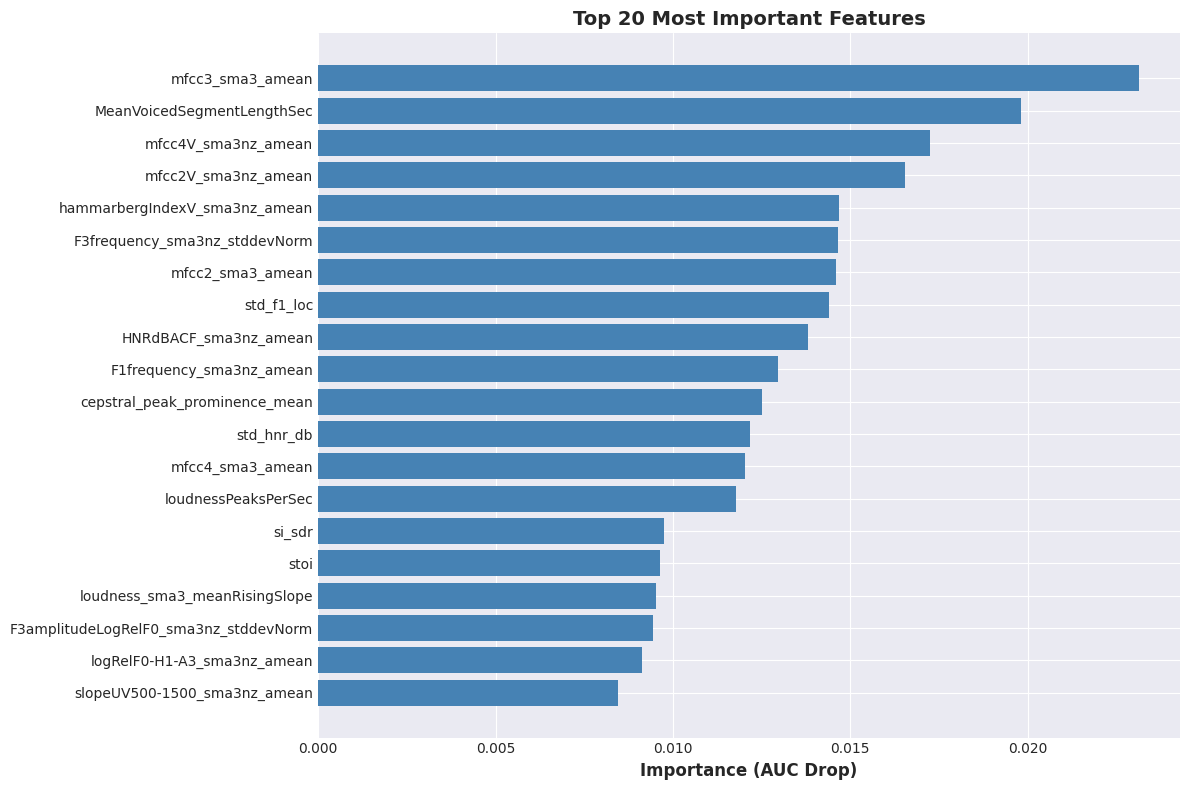

✓ Saved feature importance plot to: /home/Phenotype and Voice for PD/outputs/vae_standalone/feature_importance.png


In [16]:
# ============================================================
# Compute Feature Importance on Best Model
# ============================================================

# Use the baseline model trained on full training data
X_train_val_combined = np.vstack([X_train_np_real, X_val_np_real])
y_train_val_combined = np.concatenate([y_train_np_real, y_val_np_real])

# Compute feature importance
importance_df = compute_feature_importance(
    model_real_baseline,
    X_train_val_combined,
    y_train_val_combined,
    feature_cols,
    n_iterations=10
)

# Save feature importance
importance_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
print(f"\n✓ Saved feature importance to: {OUTPUT_DIR / 'feature_importance.csv'}")

# Plot top features
plt.figure(figsize=(12, 8))
top_n = 20
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance (AUC Drop)', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved feature importance plot to: {OUTPUT_DIR / 'feature_importance.png'}")


In [17]:
# ============================================================
# Standardized CV Results Visualization Function
# ============================================================

def plot_cv_results_standardized(cv_results_df, model_name, save_path=None):
    """
    Create standardized cross-validation visualization with box plots and line plots.
    
    Parameters:
    -----------
    cv_results_df : pd.DataFrame
        DataFrame containing CV results with columns: fold, test_acc, test_roc_auc, test_f1
    model_name : str
        Name of the model for title
    save_path : Path, optional
        Path to save the figure
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{model_name}: 5-Fold Cross-Validation Results', fontsize=16, fontweight='bold')
    
    folds = cv_results_df['fold'].values
    
    # Prepare data for box plots
    test_metrics = {
        'Accuracy': cv_results_df['test_acc'].values,
        'ROC-AUC': cv_results_df['test_roc_auc'].values,
        'F1 Score': cv_results_df['test_f1'].values
    }
    
    # 1. Box plot: Test metrics distribution
    ax1 = axes[0, 0]
    metrics_data = [test_metrics['Accuracy'], test_metrics['ROC-AUC'], test_metrics['F1 Score']]
    bp = ax1.boxplot(metrics_data, labels=['Accuracy', 'ROC-AUC', 'F1'], patch_artist=True)
    colors_box = ['steelblue', 'darkorange', 'forestgreen']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_title('Test Metrics Distribution Across Folds', fontsize=13, fontweight='bold')
    ax1.set_ylim([0, 1.05])
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add mean values as text
    for i, (metric_name, values) in enumerate(test_metrics.items(), 1):
        mean_val = np.mean(values)
        ax1.text(i, mean_val + 0.02, f'{mean_val:.3f}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
    
    # 2. Line plot: Test Accuracy across folds
    ax2 = axes[0, 1]
    ax2.plot(folds, test_metrics['Accuracy'], 'o-', linewidth=2.5, markersize=10, 
             color='steelblue', label='Test Accuracy', markerfacecolor='white', markeredgewidth=2)
    ax2.axhline(y=np.mean(test_metrics['Accuracy']), color='r', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(test_metrics["Accuracy"]):.4f}')
    ax2.fill_between(folds, 
                     np.mean(test_metrics['Accuracy']) - np.std(test_metrics['Accuracy']),
                     np.mean(test_metrics['Accuracy']) + np.std(test_metrics['Accuracy']),
                     alpha=0.2, color='gray', label=f'±1 std: {np.std(test_metrics["Accuracy"]):.4f}')
    ax2.set_xlabel('Fold', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('Test Accuracy Across Folds', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(folds)
    ax2.set_ylim([0, 1.05])
    
    # 3. Line plot: Test ROC-AUC across folds
    ax3 = axes[1, 0]
    ax3.plot(folds, test_metrics['ROC-AUC'], 'o-', linewidth=2.5, markersize=10,
             color='darkorange', label='Test ROC-AUC', markerfacecolor='white', markeredgewidth=2)
    ax3.axhline(y=np.mean(test_metrics['ROC-AUC']), color='r', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(test_metrics["ROC-AUC"]):.4f}')
    ax3.fill_between(folds,
                     np.mean(test_metrics['ROC-AUC']) - np.std(test_metrics['ROC-AUC']),
                     np.mean(test_metrics['ROC-AUC']) + np.std(test_metrics['ROC-AUC']),
                     alpha=0.2, color='gray', label=f'±1 std: {np.std(test_metrics["ROC-AUC"]):.4f}')
    ax3.set_xlabel('Fold', fontsize=12, fontweight='bold')
    ax3.set_ylabel('ROC-AUC', fontsize=12, fontweight='bold')
    ax3.set_title('Test ROC-AUC Across Folds', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xticks(folds)
    ax3.set_ylim([0, 1.05])
    
    # 4. Line plot: Test F1 Score across folds
    ax4 = axes[1, 1]
    ax4.plot(folds, test_metrics['F1 Score'], 'o-', linewidth=2.5, markersize=10,
             color='forestgreen', label='Test F1 Score', markerfacecolor='white', markeredgewidth=2)
    ax4.axhline(y=np.mean(test_metrics['F1 Score']), color='r', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(test_metrics["F1 Score"]):.4f}')
    ax4.fill_between(folds,
                     np.mean(test_metrics['F1 Score']) - np.std(test_metrics['F1 Score']),
                     np.mean(test_metrics['F1 Score']) + np.std(test_metrics['F1 Score']),
                     alpha=0.2, color='gray', label=f'±1 std: {np.std(test_metrics["F1 Score"]):.4f}')
    ax4.set_xlabel('Fold', fontsize=12, fontweight='bold')
    ax4.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
    ax4.set_title('Test F1 Score Across Folds', fontsize=13, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_xticks(folds)
    ax4.set_ylim([0, 1.05])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved CV visualization to: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\n{model_name} - CV Summary Statistics:")
    print(f"  Test Accuracy: {np.mean(test_metrics['Accuracy']):.4f} ± {np.std(test_metrics['Accuracy']):.4f}")
    print(f"  Test ROC-AUC:  {np.mean(test_metrics['ROC-AUC']):.4f} ± {np.std(test_metrics['ROC-AUC']):.4f}")
    print(f"  Test F1 Score: {np.mean(test_metrics['F1 Score']):.4f} ± {np.std(test_metrics['F1 Score']):.4f}")

print("✓ Standardized CV visualization function defined")


✓ Standardized CV visualization function defined


### 8.3. Neural Network: CV Results Visualization


NEURAL NETWORK: CV RESULTS VISUALIZATION
✓ Saved CV visualization to: /home/Phenotype and Voice for PD/outputs/vae_standalone/nn_cv_results_visualization.png


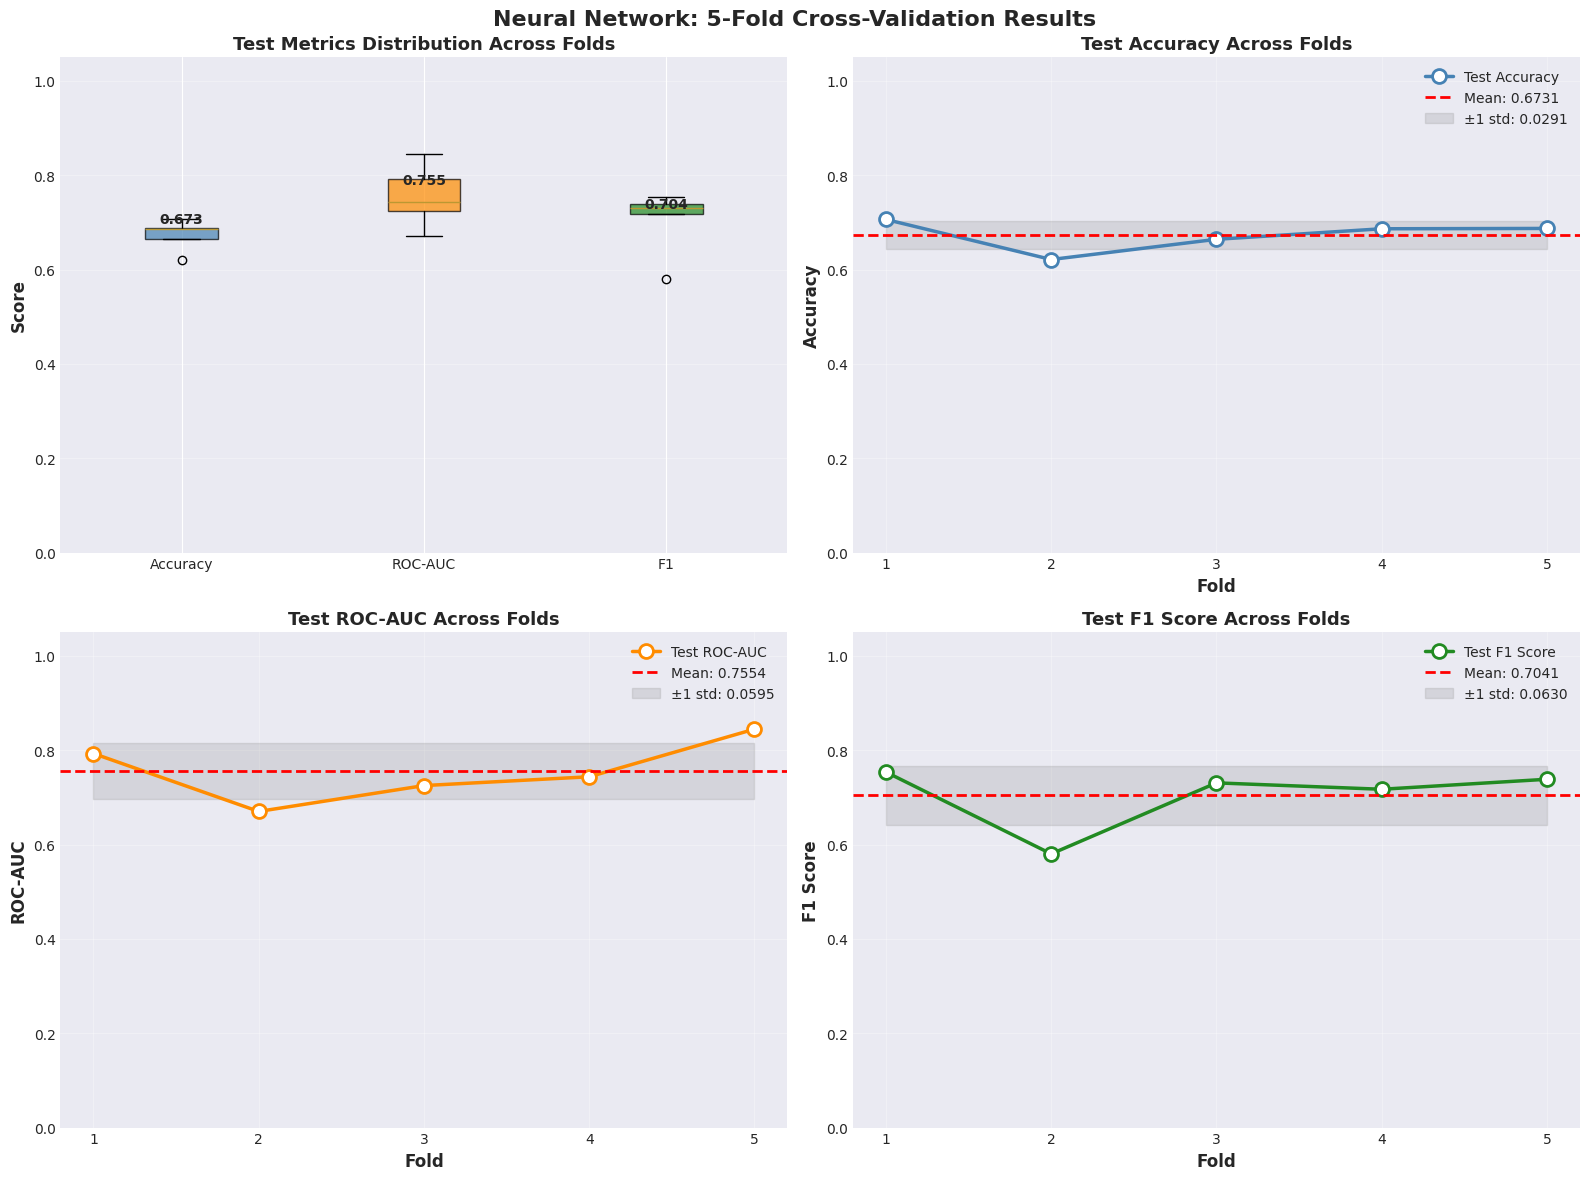


Neural Network - CV Summary Statistics:
  Test Accuracy: 0.6731 ± 0.0291
  Test ROC-AUC:  0.7554 ± 0.0595
  Test F1 Score: 0.7041 ± 0.0630


In [18]:
# ============================================================
# Neural Network: CV Results Visualization
# ============================================================

print("=" * 60)
print("NEURAL NETWORK: CV RESULTS VISUALIZATION")
print("=" * 60)

if 'cv_results_dict' in globals() and 'results' in cv_results_dict:
    # Convert to DataFrame for standardized function
    cv_results_nn_df = pd.DataFrame(cv_results_dict['results'])
    
    plot_cv_results_standardized(
        cv_results_nn_df,
        model_name='Neural Network',
        save_path=OUTPUT_DIR / 'nn_cv_results_visualization.png'
    )
else:
    print("⚠ cv_results_dict not found. Run CV section first.")
print("=" * 60)


### 8.4. Neural Network: Final Training on Full Training Set


In [19]:
# ============================================================
# Neural Network: Final Training on Full Training Set
# ============================================================

print("=" * 60)
print("NEURAL NETWORK: FINAL TRAINING ON FULL TRAINING SET")
print("=" * 60)

# Check that grid search has been run
if 'nn_best_params' not in globals() or nn_best_params is None:
    print("⚠ Grid search not run yet. Using default parameters.")
    nn_best_params = {
        'lr': 6e-4,
        'weight_decay': 8e-3,
        'noise_std': 0.01,
        'label_smoothing': 0.1,
        'gradient_clip': 0.5
    }
else:
    print(f"✓ Using grid search parameters: {nn_best_params}")

# Combine train and val for final training
X_train_full = np.vstack([X_train_np_real, X_val_np_real])
y_train_full = np.concatenate([y_train_np_real, y_val_np_real])

# Create final training data loader
train_full_dataset = TensorDataset(
    torch.tensor(X_train_full, dtype=torch.float32),
    torch.tensor(y_train_full.reshape(-1, 1), dtype=torch.float32)
)
train_full_loader = DataLoader(train_full_dataset, batch_size=128, shuffle=True)

# Keep validation loader for threshold tuning
val_loader_final = val_loader_real

# Create and train final model
print("\nTraining final model on full training set...")
model_final_nn = RegularizedHybridNet(input_dim).to(DEVICE)

model_final_nn, hist_final_nn, best_epoch_final_nn = train_model_with_checkpointing(
    model_final_nn,
    train_loader=train_full_loader,
    val_loader=val_loader_final,
    epochs=40,
    lr=nn_best_params['lr'],
    weight_decay=nn_best_params['weight_decay'],
    use_data_augmentation=True,
    noise_std=nn_best_params['noise_std'],
    label_smoothing=nn_best_params['label_smoothing'],
    gradient_clip=nn_best_params['gradient_clip'],
    patience=6
)

# Find best threshold on validation set
print("\n" + "=" * 60)
print("TUNING THRESHOLD ON VALIDATION SET")
print("=" * 60)
best_threshold_nn, best_val_f1_nn = find_best_threshold(model_final_nn, val_loader_final)
print(f"Best threshold on validation: {best_threshold_nn:.3f} (val F1={best_val_f1_nn:.4f})")

# Evaluate on test set
print("\n" + "=" * 60)
print("EVALUATING ON TEST DATA")
print("=" * 60)
metrics_final_nn = evaluate_on_real(model_final_nn, test_loader, threshold=best_threshold_nn)

print("\nPerformance on test data (final model trained on full training set):")
for k, v in metrics_final_nn.items():
    print(f"  {k}: {v:.4f}")
print(f"  (using threshold: {best_threshold_nn:.3f})")
print("=" * 60)

# Store for visualization
metrics_real_baseline = metrics_final_nn


NEURAL NETWORK: FINAL TRAINING ON FULL TRAINING SET
✓ Using grid search parameters: {'lr': 0.0006, 'weight_decay': 0.008, 'noise_std': 0.01, 'label_smoothing': 0.1, 'gradient_clip': 0.5}

Training final model on full training set...
Training on device: cuda
Epochs: 40, LR: 6e-04, Weight decay: 8e-03
Epoch   1/40: train_loss=0.7055, val_loss=0.6863, train_acc=0.518, val_acc=0.514, val_roc_auc=0.6126
Epoch  10/40: train_loss=0.5428, val_loss=0.3772, train_acc=0.791, val_acc=0.846, val_roc_auc=0.9326
Epoch  20/40: train_loss=0.4677, val_loss=0.2502, train_acc=0.870, val_acc=0.917, val_roc_auc=0.9839
Epoch  30/40: train_loss=0.4253, val_loss=0.1913, train_acc=0.916, val_acc=0.958, val_roc_auc=0.9943
Epoch  40/40: train_loss=0.4138, val_loss=0.1816, train_acc=0.926, val_acc=0.966, val_roc_auc=0.9966

✓ Loaded best model from epoch 40 (Val ROC-AUC: 0.9966)

TUNING THRESHOLD ON VALIDATION SET
Best threshold on validation: 0.500 (val F1=0.9670)

EVALUATING ON TEST DATA

Performance on test dat

### 8.5. Neural Network: Performance Visualizations


In [20]:
# ============================================================
# Neural Network: Performance Visualizations
# ============================================================

print("=" * 60)
print("NEURAL NETWORK: PERFORMANCE VISUALIZATIONS")
print("=" * 60)

# Check that final model exists
if 'model_final_nn' not in globals():
    print("⚠ Final model not found. Please run final training section first.")
else:
    # Use final model for visualizations
    model_viz = model_final_nn
    hist_viz = hist_final_nn
    threshold_viz = best_threshold_nn

def plot_training_curves(history, title, save_path=None):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss curves
    ax1 = axes[0]
    ax1.plot(epochs, history['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=3)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Loss Curves', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Accuracy curves
    ax2 = axes[1]
    ax2.plot(epochs, history['train_acc'], label='Train Accuracy', linewidth=2, marker='o', markersize=3)
    ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', linewidth=2, marker='s', markersize=3)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Accuracy Curves', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return avg_precision

def plot_roc_curve(model, loader, threshold=0.5, title="ROC Curve", save_path=None):
    """Plot ROC curve."""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(yb.numpy().flatten())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    
    # Calculate ROC curve
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5000)')
    
    # Mark the chosen threshold point
    preds_at_threshold = (all_probs >= threshold).astype(int)
    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(all_labels, preds_at_threshold).ravel()
    tpr_at_threshold = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_at_threshold = fp / (fp + tn) if (fp + tn) > 0 else 0
    plt.plot(fpr_at_threshold, tpr_at_threshold, 'ro', markersize=10, 
             label=f'Threshold {threshold:.3f}')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return roc_auc

def plot_precision_recall_curve(model, loader, threshold=0.5, title="Precision-Recall Curve", save_path=None):
    """Plot Precision-Recall curve."""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(yb.numpy().flatten())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    
    # Calculate Precision-Recall curve
    precision, recall, pr_thresholds = precision_recall_curve(all_labels, all_probs)
    avg_precision = average_precision_score(all_labels, all_probs)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkblue', lw=2, 
             label=f'PR curve (AP = {avg_precision:.4f})')
    
    # Mark the chosen threshold point
    preds_at_threshold = (all_probs >= threshold).astype(int)
    from sklearn.metrics import precision_score, recall_score
    prec_at_threshold = precision_score(all_labels, preds_at_threshold)
    rec_at_threshold = recall_score(all_labels, preds_at_threshold)
    plt.plot(rec_at_threshold, prec_at_threshold, 'ro', markersize=10,
             label=f'Threshold {threshold:.3f}')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return avg_precision

def plot_confusion_matrix(model, loader, threshold=0.5, title="Confusion Matrix", save_path=None):
    """Plot confusion matrix."""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(yb.numpy().flatten())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    preds = (all_probs >= threshold).astype(int)
    
    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, preds)
    
    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Control', 'Parkinson\'s'],
                yticklabels=['Control', 'Parkinson\'s'],
                square=True, linewidths=2, linecolor='gray')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Add text annotations
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tn + tp) / (tn + fp + fn + tp)
    plt.text(0.5, -0.15, f'Accuracy: {accuracy:.4f}', 
             ha='center', transform=plt.gca().transAxes, fontsize=11)
    plt.text(0.5, -0.20, f'Threshold: {threshold:.3f}', 
             ha='center', transform=plt.gca().transAxes, fontsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return cm

    print("\n" + "=" * 60)
    print("VISUALIZING TRAINING CURVES")
    print("=" * 60)
    
    plot_training_curves(
        hist_viz,
        "Neural Network: Final Model Training Curves",
        save_path=OUTPUT_DIR / 'nn_final_training_curves.png'
    )
    print(f"✓ Saved training curves to: {OUTPUT_DIR / 'nn_final_training_curves.png'}")
    
    print("\n" + "=" * 60)
    print("VISUALIZING ROC CURVE")
    print("=" * 60)
    
    roc_auc = plot_roc_curve(
        model_viz,
        test_loader,
        threshold=threshold_viz,
        title="ROC Curve - Neural Network Classification",
        save_path=OUTPUT_DIR / 'nn_final_roc_curve.png'
    )
    print(f"✓ ROC-AUC: {roc_auc:.4f}")
    print(f"✓ Saved ROC curve to: {OUTPUT_DIR / 'nn_final_roc_curve.png'}")
    
    print("\n" + "=" * 60)
    print("VISUALIZING PRECISION-RECALL CURVE")
    print("=" * 60)
    
    avg_precision = plot_precision_recall_curve(
        model_viz,
        test_loader,
        threshold=threshold_viz,
        title="Precision-Recall Curve - Neural Network Classification",
        save_path=OUTPUT_DIR / 'nn_final_pr_curve.png'
    )
    print(f"✓ Average Precision: {avg_precision:.4f}")
    print(f"✓ Saved PR curve to: {OUTPUT_DIR / 'nn_final_pr_curve.png'}")
    
    print("\n" + "=" * 60)
    print("VISUALIZING CONFUSION MATRIX")
    print("=" * 60)
    
    cm = plot_confusion_matrix(
        model_viz,
        test_loader,
        threshold=threshold_viz,
        title="Confusion Matrix - Neural Network Classification",
        save_path=OUTPUT_DIR / 'nn_final_confusion_matrix.png'
    )
    print(f"✓ Confusion Matrix:")
    print(f"  True Negatives (TN): {cm[0, 0]}")
    print(f"  False Positives (FP): {cm[0, 1]}")
    print(f"  False Negatives (FN): {cm[1, 0]}")
    print(f"  True Positives (TP): {cm[1, 1]}")
    print(f"✓ Saved confusion matrix to: {OUTPUT_DIR / 'nn_final_confusion_matrix.png'}")
    
    print("=" * 60)

NEURAL NETWORK: PERFORMANCE VISUALIZATIONS


## 9. Random Forest Classifier


### 9.1. Random Forest: Hyperparameter Grid Search


In [21]:
# ============================================================
# Random Forest: Default Parameters
# ============================================================

print("=" * 60)
print("RANDOM FOREST: DEFAULT PARAMETERS")
print("=" * 60)

# Set default parameters for Random Forest
rf_best_params = {
    'n_estimators': 150,
    'max_depth': 10,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'max_features': 'sqrt',
    'random_state': SEED,
    'n_jobs': -1,
    'class_weight': 'balanced'
}

print(f"\nUsing default parameters: {rf_best_params}")
print(f"\n✓ Parameters stored in 'rf_best_params' for use in 5-fold CV and final training")
print("=" * 60)


RANDOM FOREST: DEFAULT PARAMETERS

Using default parameters: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}

✓ Parameters stored in 'rf_best_params' for use in 5-fold CV and final training


In [22]:
# ============================================================
# Random Forest Classifier Setup
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("RANDOM FOREST CLASSIFIER")
print("=" * 60)

# Prepare data for Random Forest (use same train/val/test splits)
X_train_rf = X_train.values.astype(np.float32)
X_val_rf = X_val.values.astype(np.float32)
X_test_rf = X_test.values.astype(np.float32)

y_train_rf = y_train_raw.values.astype(int)
y_val_rf = y_val_raw.values.astype(int)
y_test_rf = y_test_raw.values.astype(int)

print(f"Training samples: {len(X_train_rf)} ({np.sum(y_train_rf == 0)} Control, {np.sum(y_train_rf == 1)} PD)")
print(f"Validation samples: {len(X_val_rf)} ({np.sum(y_val_rf == 0)} Control, {np.sum(y_val_rf == 1)} PD)")
print(f"Test samples: {len(X_test_rf)} ({np.sum(y_test_rf == 0)} Control, {np.sum(y_test_rf == 1)} PD)")
print("=" * 60)


RANDOM FOREST CLASSIFIER
Training samples: 3071 (1514 Control, 1557 PD)
Validation samples: 832 (411 Control, 421 PD)
Test samples: 976 (513 Control, 463 PD)


### 9.1. Random Forest: 5-Fold Cross-Validation


In [23]:
# ============================================================
# Random Forest: 5-Fold Cross-Validation
# ============================================================

print("=" * 60)
print("RANDOM FOREST: 5-FOLD CROSS-VALIDATION")
print("=" * 60)

# rf_best_params should be set by grid search in section 9.0
# If grid search hasn't been run, use default parameters as fallback
if 'rf_best_params' not in globals() or rf_best_params is None:
    print("⚠ Grid search not run yet. Using default parameters.")
    rf_best_params = {
        'n_estimators': 150,
        'max_depth': 10,
        'min_samples_split': 20,
        'min_samples_leaf': 10,
        'max_features': 'sqrt',
    }
    rf_best_params['random_state'] = SEED
    rf_best_params['n_jobs'] = -1
    rf_best_params['class_weight'] = 'balanced'
else:
    # Add fixed parameters that aren't in grid search
    if 'random_state' not in rf_best_params:
        rf_best_params['random_state'] = SEED
    if 'n_jobs' not in rf_best_params:
        rf_best_params['n_jobs'] = -1
    if 'class_weight' not in rf_best_params:
        rf_best_params['class_weight'] = 'balanced'
    print(f"✓ Using grid search parameters: {rf_best_params}")

# Prepare data for CV (combine train and val)
X_cv_rf = np.vstack([X_train_rf, X_val_rf])
y_cv_rf = np.concatenate([y_train_rf, y_val_rf])

# Get participant IDs for CV
try:
    pid_train_array = np.array(pid_train) if isinstance(pid_train, (list, pd.Series)) else pid_train
    pid_val_array = np.array(pid_val) if isinstance(pid_val, (list, pd.Series)) else pid_val
    pid_cv_rf = np.concatenate([pid_train_array, pid_val_array])
    
    unique_pids = len(np.unique(pid_cv_rf))
    use_group_kfold = unique_pids >= 5
    
    if use_group_kfold:
        print(f"✓ Found {unique_pids} unique participants")
        print("✓ Using StratifiedGroupKFold (participant-level CV - NO DATA LEAKAGE)")
    else:
        print(f"⚠ Only {unique_pids} unique participants")
        print("⚠ Falling back to StratifiedKFold (sample-level CV - RISK OF DATA LEAKAGE)")
        pid_cv_rf = None
except Exception as e:
    print(f"⚠ Error extracting participant IDs: {e}")
    use_group_kfold = False
    pid_cv_rf = None

# Setup CV
try:
    from sklearn.model_selection import StratifiedGroupKFold
    if use_group_kfold and pid_cv_rf is not None:
        skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    else:
        from sklearn.model_selection import StratifiedKFold
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        pid_cv_rf = None
except ImportError:
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    pid_cv_rf = None
    use_group_kfold = False

# Helper function for threshold tuning
def find_best_threshold_rf_cv(model, X, y):
    """Find optimal threshold for Random Forest based on F1-score."""
    probs = model.predict_proba(X)[:, 1]
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 19):
        pred = (probs >= t).astype(int)
        f1 = f1_score(y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

# Perform cross-validation
cv_results_rf = {
    'fold': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': [],
    'train_roc_auc': [],
    'val_roc_auc': [],
    'test_roc_auc': [],
    'train_f1': [],
    'val_f1': [],
    'test_f1': [],
    'best_threshold': []
}

print("\nStarting 5-fold cross-validation...")
if use_group_kfold and pid_cv_rf is not None:
    splits = skf.split(X_cv_rf, y_cv_rf, pid_cv_rf)
else:
    splits = skf.split(X_cv_rf, y_cv_rf)

for fold, (train_idx, test_idx) in enumerate(splits, 1):
    print(f"\n{'=' * 60}")
    print(f"FOLD {fold}/5")
    print(f"{'=' * 60}")
    
    # Split data
    X_train_cv = X_cv_rf[train_idx]
    X_test_cv = X_cv_rf[test_idx]
    y_train_cv = y_cv_rf[train_idx]
    y_test_cv = y_cv_rf[test_idx]
    
    # Further split train into train/val for threshold tuning
    from sklearn.model_selection import train_test_split
    
    if use_group_kfold and pid_cv_rf is not None:
        train_pids = pid_cv_rf[train_idx]
        unique_train_pids = np.unique(train_pids)
        pid_to_label = {}
        for pid, label in zip(train_pids, y_train_cv):
            if pid not in pid_to_label:
                pid_to_label[pid] = label
        participant_labels_fold = np.array([pid_to_label[pid] for pid in unique_train_pids])
        
        pids_train_fold, pids_val_fold, y_p_train_fold, y_p_val_fold = train_test_split(
            unique_train_pids, participant_labels_fold,
            test_size=0.2, random_state=SEED + fold, stratify=participant_labels_fold
        )
        
        train_fold_mask = np.isin(train_pids, pids_train_fold)
        val_fold_mask = np.isin(train_pids, pids_val_fold)
        
        X_train_fold = X_train_cv[train_fold_mask]
        X_val_fold = X_train_cv[val_fold_mask]
        y_train_fold = y_train_cv[train_fold_mask]
        y_val_fold = y_train_cv[val_fold_mask]
    else:
        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(
            X_train_cv, y_train_cv, test_size=0.2, random_state=SEED + fold, stratify=y_train_cv
        )
    
    print(f"Train: {X_train_fold.shape[0]} samples ({np.sum(y_train_fold == 0)} Control, {np.sum(y_train_fold == 1)} PD)")
    print(f"Val: {X_val_fold.shape[0]} samples ({np.sum(y_val_fold == 0)} Control, {np.sum(y_val_fold == 1)} PD)")
    print(f"Test: {X_test_cv.shape[0]} samples ({np.sum(y_test_cv == 0)} Control, {np.sum(y_test_cv == 1)} PD)")
    
    # Train model
    rf_model = RandomForestClassifier(**rf_best_params)
    rf_model.fit(X_train_fold, y_train_fold)
    
    # Evaluate on train, val, and test
    for split_name, X_split, y_split in [('train', X_train_fold, y_train_fold),
                                          ('val', X_val_fold, y_val_fold),
                                          ('test', X_test_cv, y_test_cv)]:
        y_pred = rf_model.predict(X_split)
        y_proba = rf_model.predict_proba(X_split)[:, 1]
        
        acc = accuracy_score(y_split, y_pred)
        auc = roc_auc_score(y_split, y_proba)
        f1 = f1_score(y_split, y_pred)
        
        cv_results_rf[f'{split_name}_acc'].append(acc)
        cv_results_rf[f'{split_name}_roc_auc'].append(auc)
        cv_results_rf[f'{split_name}_f1'].append(f1)
    
    # Find best threshold on validation set
    best_thresh, best_val_f1 = find_best_threshold_rf_cv(rf_model, X_val_fold, y_val_fold)
    cv_results_rf['best_threshold'].append(best_thresh)
    
    print(f"\nFold {fold} Results:")
    print(f"  Train - Acc: {cv_results_rf['train_acc'][-1]:.4f}, ROC-AUC: {cv_results_rf['train_roc_auc'][-1]:.4f}, F1: {cv_results_rf['train_f1'][-1]:.4f}")
    print(f"  Val   - Acc: {cv_results_rf['val_acc'][-1]:.4f}, ROC-AUC: {cv_results_rf['val_roc_auc'][-1]:.4f}, F1: {cv_results_rf['val_f1'][-1]:.4f}")
    print(f"  Test  - Acc: {cv_results_rf['test_acc'][-1]:.4f}, ROC-AUC: {cv_results_rf['test_roc_auc'][-1]:.4f}, F1: {cv_results_rf['test_f1'][-1]:.4f}")
    print(f"  Best Threshold: {best_thresh:.3f} (Val F1={best_val_f1:.4f})")
    
    cv_results_rf['fold'].append(fold)

# Summary
print("\n" + "=" * 60)
print("CROSS-VALIDATION SUMMARY")
print("=" * 60)
print(f"Test Accuracy: {np.mean(cv_results_rf['test_acc']):.4f} ± {np.std(cv_results_rf['test_acc']):.4f}")
print(f"Test ROC-AUC: {np.mean(cv_results_rf['test_roc_auc']):.4f} ± {np.std(cv_results_rf['test_roc_auc']):.4f}")
print(f"Test F1: {np.mean(cv_results_rf['test_f1']):.4f} ± {np.std(cv_results_rf['test_f1']):.4f}")

# Save CV results
cv_results_rf_df = pd.DataFrame(cv_results_rf)
cv_results_rf_df.to_csv(OUTPUT_DIR / 'rf_cv_results.csv', index=False)
print(f"\n✓ Saved CV results to: {OUTPUT_DIR / 'rf_cv_results.csv'}")
print("=" * 60)


RANDOM FOREST: 5-FOLD CROSS-VALIDATION
✓ Using grid search parameters: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
✓ Found 100 unique participants
✓ Using StratifiedGroupKFold (participant-level CV - NO DATA LEAKAGE)

Starting 5-fold cross-validation...

FOLD 1/5
Train: 2522 samples (1288 Control, 1234 PD)
Val: 640 samples (310 Control, 330 PD)
Test: 741 samples (327 Control, 414 PD)

Fold 1 Results:
  Train - Acc: 0.9655, ROC-AUC: 0.9945, F1: 0.9643
  Val   - Acc: 0.6078, ROC-AUC: 0.6431, F1: 0.5837
  Test  - Acc: 0.6721, ROC-AUC: 0.7304, F1: 0.6824
  Best Threshold: 0.200 (Val F1=0.6950)

FOLD 2/5
Train: 2424 samples (1187 Control, 1237 PD)
Val: 620 samples (303 Control, 317 PD)
Test: 859 samples (435 Control, 424 PD)

Fold 2 Results:
  Train - Acc: 0.9637, ROC-AUC: 0.9941, F1: 0.9643
  Val   - Acc: 0.6952, ROC-AUC: 0.7733, F1: 0.6947
  Test  - Acc: 0.7043

### 9.2. Random Forest: CV Results Visualization


RANDOM FOREST: CV RESULTS VISUALIZATION
✓ Saved CV visualization to: /home/Phenotype and Voice for PD/outputs/vae_standalone/rf_cv_results_visualization.png


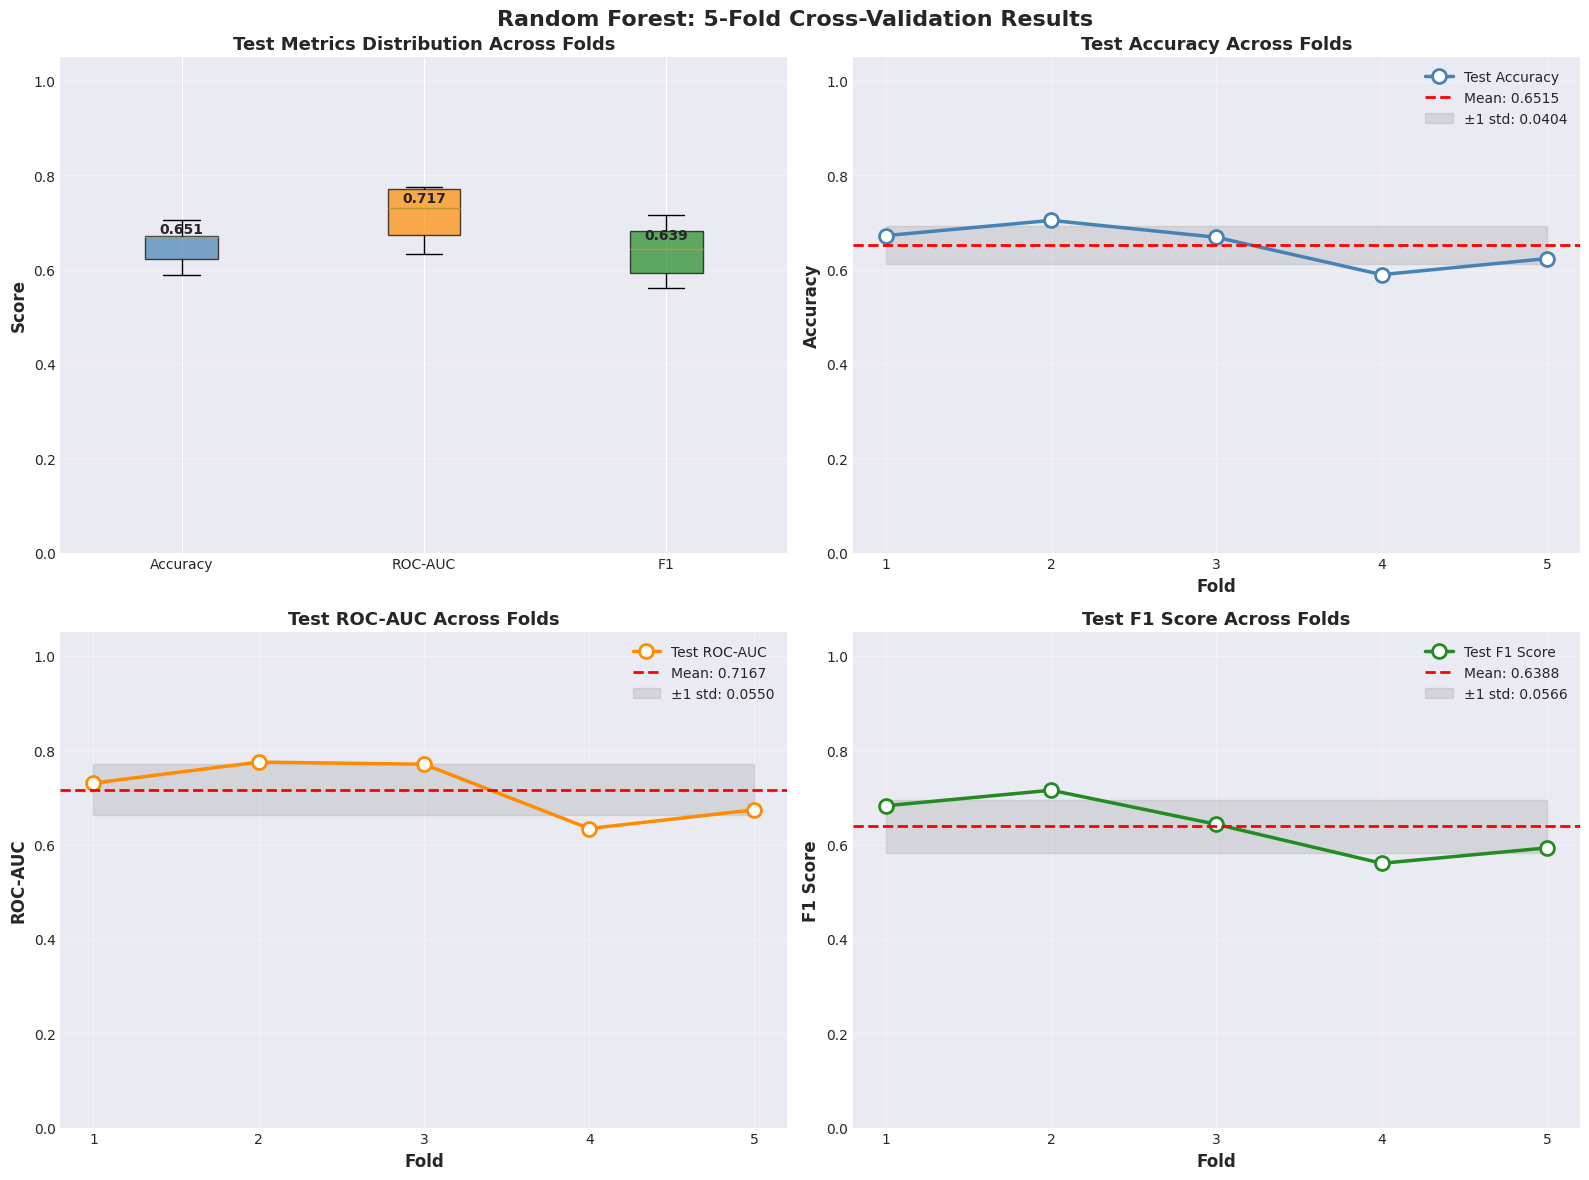


Random Forest - CV Summary Statistics:
  Test Accuracy: 0.6515 ± 0.0404
  Test ROC-AUC:  0.7167 ± 0.0550
  Test F1 Score: 0.6388 ± 0.0566


In [24]:
# ============================================================
# Random Forest: CV Results Visualization
# ============================================================

print("=" * 60)
print("RANDOM FOREST: CV RESULTS VISUALIZATION")
print("=" * 60)

if 'cv_results_rf_df' in globals():
    plot_cv_results_standardized(
        cv_results_rf_df,
        model_name='Random Forest',
        save_path=OUTPUT_DIR / 'rf_cv_results_visualization.png'
    )
else:
    print(f"⚠ cv_results_rf_df not found. Run CV section first.")
print("=" * 60)


### 9.3. Random Forest: Train and Evaluate


In [25]:
# ============================================================
# Random Forest: Train on Full Training Data and Evaluate
# ============================================================

print("=" * 60)
print("RANDOM FOREST: TRAINING AND EVALUATION")
print("=" * 60)

# Helper function for threshold tuning (Random Forest version)
def find_best_threshold_rf(model, X, y):
    """Find optimal threshold for Random Forest based on F1-score."""
    probs = model.predict_proba(X)[:, 1]
    
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 19):
        pred = (probs >= t).astype(int)
        f1 = f1_score(y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

# Train on full training data (train + val combined)
X_train_val_rf = np.vstack([X_train_rf, X_val_rf])
y_train_val_rf = np.concatenate([y_train_rf, y_val_rf])

print("\nTraining Random Forest on full training data...")
rf_final = RandomForestClassifier(**rf_best_params)

rf_final.fit(X_train_val_rf, y_train_val_rf)

# Get predictions and probabilities
y_train_pred_rf = rf_final.predict(X_train_val_rf)
y_train_proba_rf = rf_final.predict_proba(X_train_val_rf)[:, 1]

y_test_pred_rf = rf_final.predict(X_test_rf)
y_test_proba_rf = rf_final.predict_proba(X_test_rf)[:, 1]

# Find best threshold on validation data
print("\n" + "=" * 60)
print("TUNING THRESHOLD ON VALIDATION DATA")
print("=" * 60)

best_threshold_rf, best_val_f1_rf = find_best_threshold_rf(
    rf_final, X_val_rf, y_val_rf
)
print(f"Best threshold: {best_threshold_rf:.3f} (val F1={best_val_f1_rf:.4f})")

# Evaluate on test data with optimal threshold
y_test_pred_rf_thresh = (y_test_proba_rf >= best_threshold_rf).astype(int)

metrics_rf = {
    'accuracy': accuracy_score(y_test_rf, y_test_pred_rf_thresh),
    'roc_auc': roc_auc_score(y_test_rf, y_test_proba_rf),
    'f1': f1_score(y_test_rf, y_test_pred_rf_thresh),
    'precision': precision_score(y_test_rf, y_test_pred_rf_thresh),
    'recall': recall_score(y_test_rf, y_test_pred_rf_thresh)
}

print("\n" + "=" * 60)
print("RANDOM FOREST PERFORMANCE ON TEST DATA")
print("=" * 60)
for k, v in metrics_rf.items():
    print(f"  {k}: {v:.4f}")
print(f"  (using threshold: {best_threshold_rf:.3f})")
print("=" * 60)

# Helper function for threshold tuning (Random Forest version)
def find_best_threshold_rf(model, X, y):
    """Find optimal threshold for Random Forest based on F1-score."""
    probs = model.predict_proba(X)[:, 1]
    
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 19):
        pred = (probs >= t).astype(int)
        f1 = f1_score(y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


RANDOM FOREST: TRAINING AND EVALUATION

Training Random Forest on full training data...

TUNING THRESHOLD ON VALIDATION DATA
Best threshold: 0.450 (val F1=0.9685)

RANDOM FOREST PERFORMANCE ON TEST DATA
  accuracy: 0.7172
  roc_auc: 0.8099
  f1: 0.7396
  precision: 0.6566
  recall: 0.8467
  (using threshold: 0.450)


### 9.4. Random Forest: Feature Importance


RANDOM FOREST: FEATURE IMPORTANCE

✓ Computed feature importance for 131 features

Top 20 Most Important Features (Random Forest):
                                   feature  importance
                 slopeUV0-500_sma3nz_amean    0.037034
                          mfcc4_sma3_amean    0.033320
                                  duration    0.021985
                  equivalentSoundLevel_dBp    0.018599
                 alphaRatioUV_sma3nz_amean    0.018314
            hammarbergIndexUV_sma3nz_amean    0.017966
                   spectralFlux_sma3_amean    0.017770
               spectralFluxUV_sma3nz_amean    0.017702
                                      pesq    0.017478
F0semitoneFrom27.5Hz_sma3nz_percentile50.0    0.017259
                spectralFluxV_sma3nz_amean    0.015761
F0semitoneFrom27.5Hz_sma3nz_percentile80.0    0.015737
          loudness_sma3_stddevFallingSlope    0.015223
              loudness_sma3_percentile20.0    0.014285
                         mean_intensity_db  

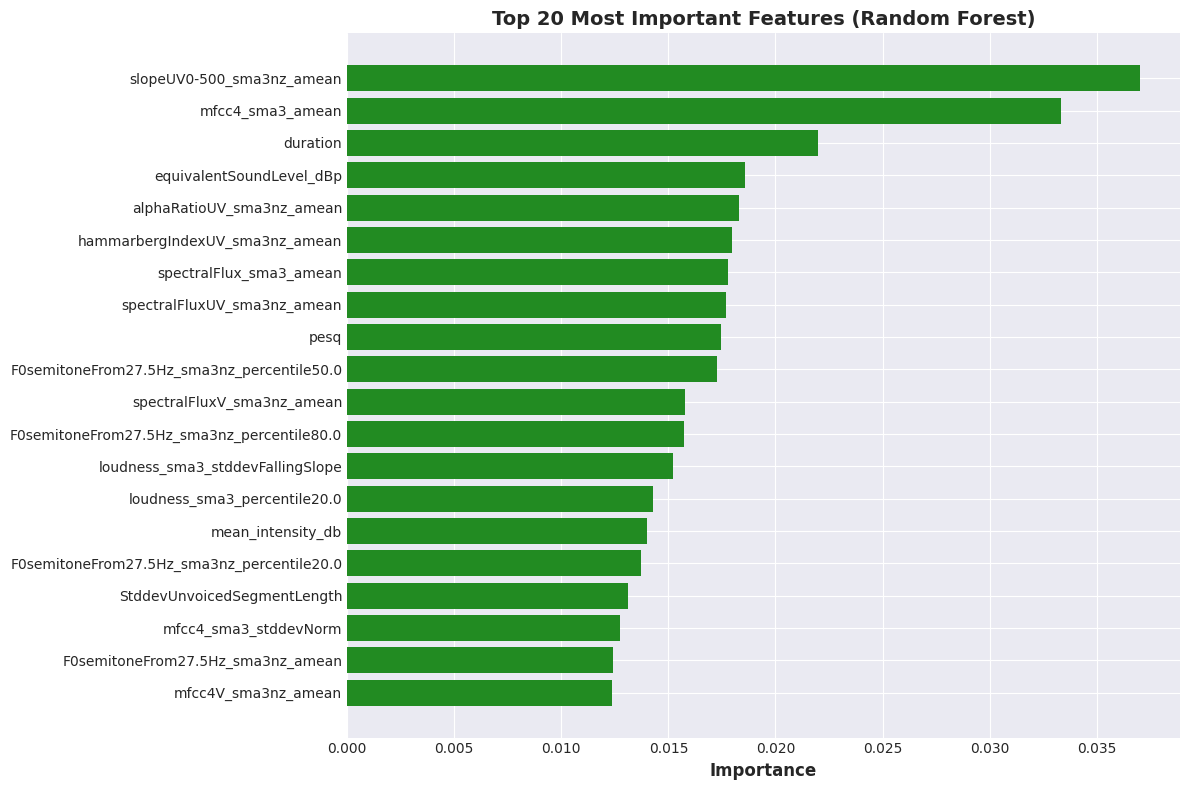

✓ Saved RF feature importance plot to: /home/Phenotype and Voice for PD/outputs/vae_standalone/rf_feature_importance.png


In [26]:
# ============================================================
# Random Forest: Feature Importance Analysis
# ============================================================

print("=" * 60)
print("RANDOM FOREST: FEATURE IMPORTANCE")
print("=" * 60)

# Get feature importance from Random Forest
rf_importance = rf_final.feature_importances_

# Create DataFrame
rf_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_importance
}).sort_values('importance', ascending=False)

print(f"\n✓ Computed feature importance for {len(feature_cols)} features")
print(f"\nTop 20 Most Important Features (Random Forest):")
print(rf_importance_df.head(20)[['feature', 'importance']].to_string(index=False))

# Save feature importance
rf_importance_df.to_csv(OUTPUT_DIR / 'rf_feature_importance.csv', index=False)
print(f"\n✓ Saved RF feature importance to: {OUTPUT_DIR / 'rf_feature_importance.csv'}")

# Plot feature importance
plt.figure(figsize=(12, 8))
top_n = 20
top_features_rf = rf_importance_df.head(top_n)
plt.barh(range(len(top_features_rf)), top_features_rf['importance'], color='forestgreen')
plt.yticks(range(len(top_features_rf)), top_features_rf['feature'])
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved RF feature importance plot to: {OUTPUT_DIR / 'rf_feature_importance.png'}")
print("=" * 60)


### 9.5. Random Forest: Performance Visualizations


RANDOM FOREST: PERFORMANCE VISUALIZATIONS

VISUALIZING ROC CURVE


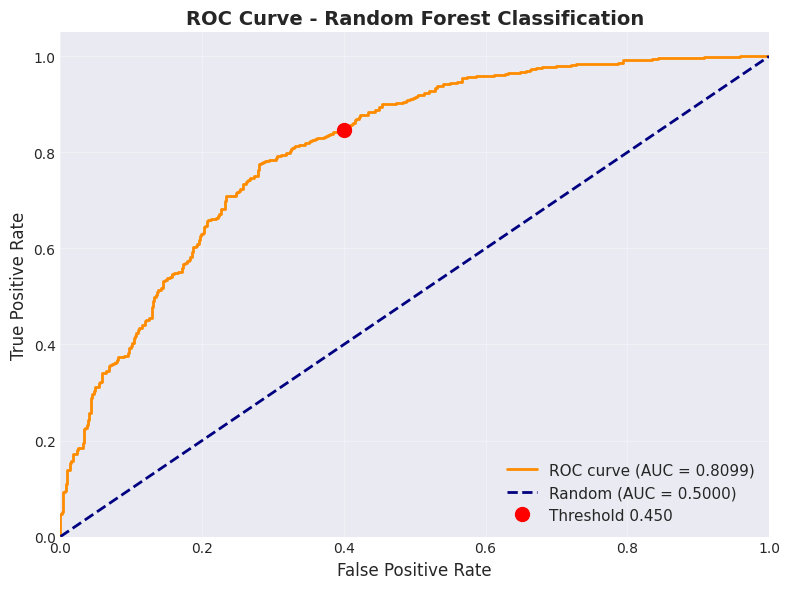

✓ ROC-AUC: 0.8099
✓ Saved ROC curve to: /home/Phenotype and Voice for PD/outputs/vae_standalone/rf_roc_curve.png

VISUALIZING PRECISION-RECALL CURVE


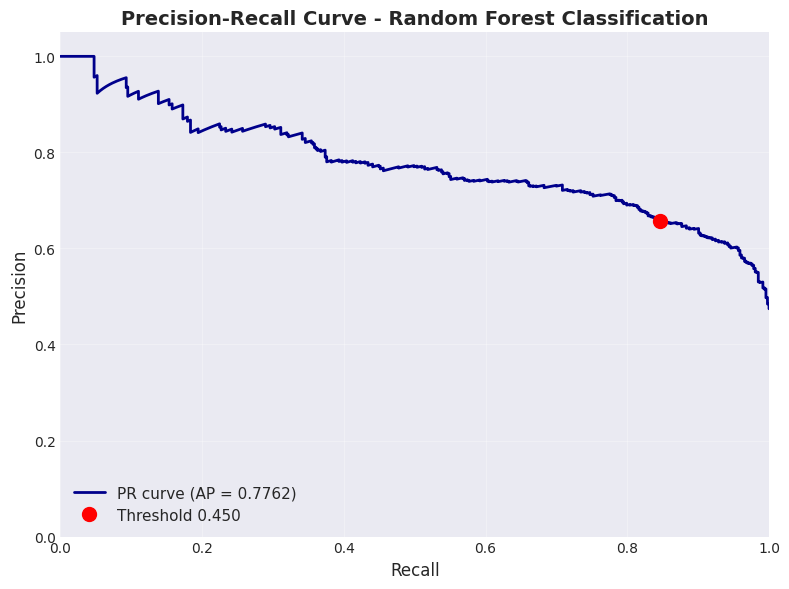

✓ Average Precision: 0.7762
✓ Saved PR curve to: /home/Phenotype and Voice for PD/outputs/vae_standalone/rf_pr_curve.png

VISUALIZING CONFUSION MATRIX


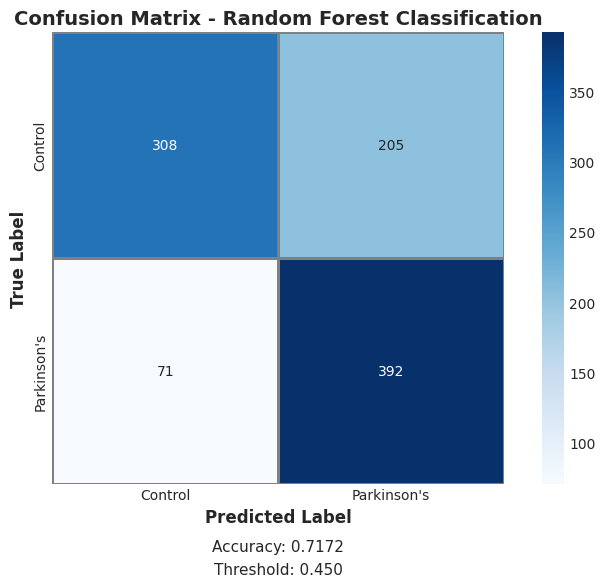

✓ Confusion Matrix:
  True Negatives (TN): 308
  False Positives (FP): 205
  False Negatives (FN): 71
  True Positives (TP): 392
✓ Saved confusion matrix to: /home/Phenotype and Voice for PD/outputs/vae_standalone/rf_confusion_matrix.png


In [27]:
# ============================================================
# Random Forest: Performance Visualizations
# ============================================================

print("=" * 60)
print("RANDOM FOREST: PERFORMANCE VISUALIZATIONS")
print("=" * 60)

# Get predictions and probabilities
y_test_proba_rf_viz = rf_final.predict_proba(X_test_rf)[:, 1]
y_test_pred_rf_viz = (y_test_proba_rf_viz >= best_threshold_rf).astype(int)

# ROC Curve
print("\n" + "=" * 60)
print("VISUALIZING ROC CURVE")
print("=" * 60)

from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_test_proba_rf_viz)
roc_auc_rf = roc_auc_score(y_test_rf, y_test_proba_rf_viz)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5000)')

# Mark threshold point
tn, fp, fn, tp = confusion_matrix(y_test_rf, y_test_pred_rf_viz).ravel()
tpr_at_threshold = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr_at_threshold = fp / (fp + tn) if (fp + tn) > 0 else 0
plt.plot(fpr_at_threshold, tpr_at_threshold, 'ro', markersize=10, label=f'Threshold {best_threshold_rf:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Random Forest Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rf_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ ROC-AUC: {roc_auc_rf:.4f}")
print(f"✓ Saved ROC curve to: {OUTPUT_DIR / 'rf_roc_curve.png'}")

# Precision-Recall Curve
print("\n" + "=" * 60)
print("VISUALIZING PRECISION-RECALL CURVE")
print("=" * 60)

from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score
precision_rf, recall_rf, _ = precision_recall_curve(y_test_rf, y_test_proba_rf_viz)
avg_precision_rf = average_precision_score(y_test_rf, y_test_proba_rf_viz)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, color='darkblue', lw=2, label=f'PR curve (AP = {avg_precision_rf:.4f})')

# Mark threshold point
prec_at_threshold = precision_score(y_test_rf, y_test_pred_rf_viz)
rec_at_threshold = recall_score(y_test_rf, y_test_pred_rf_viz)
plt.plot(rec_at_threshold, prec_at_threshold, 'ro', markersize=10, label=f'Threshold {best_threshold_rf:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Random Forest Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rf_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Average Precision: {avg_precision_rf:.4f}")
print(f"✓ Saved PR curve to: {OUTPUT_DIR / 'rf_pr_curve.png'}")

# Confusion Matrix
print("\n" + "=" * 60)
print("VISUALIZING CONFUSION MATRIX")
print("=" * 60)

cm_rf = confusion_matrix(y_test_rf, y_test_pred_rf_viz)
tn, fp, fn, tp = cm_rf.ravel()
accuracy_rf = (tn + tp) / (tn + fp + fn + tp)

plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Control', "Parkinson's"],
            yticklabels=['Control', "Parkinson's"],
            square=True, linewidths=2, linecolor='gray')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Random Forest Classification', fontsize=14, fontweight='bold')
plt.text(0.5, -0.15, f'Accuracy: {accuracy_rf:.4f}', 
         ha='center', transform=plt.gca().transAxes, fontsize=11)
plt.text(0.5, -0.20, f'Threshold: {best_threshold_rf:.3f}', 
         ha='center', transform=plt.gca().transAxes, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Confusion Matrix:")
print(f"  True Negatives (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP): {tp}")
print(f"✓ Saved confusion matrix to: {OUTPUT_DIR / 'rf_confusion_matrix.png'}")

print("=" * 60)


## 10. XGBoost Classifier


### 10.1. XGBoost: Data Setup


In [28]:
# ============================================================
# XGBoost Classifier Setup
# ============================================================

print("=" * 60)
print("XGBOOST CLASSIFIER SETUP")
print("=" * 60)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not available. Install with: pip install xgboost")
    raise ImportError("XGBoost is required. Please install with: pip install xgboost")

# Prepare data for XGBoost (use same train/val/test splits)
X_train_xgb = X_train.values.astype(np.float32)
X_val_xgb = X_val.values.astype(np.float32)
X_test_xgb = X_test.values.astype(np.float32)

y_train_xgb = y_train_rf.copy()
y_val_xgb = y_val_rf.copy()
y_test_xgb = y_test_rf.copy()

print(f"\n✓ Data prepared for XGBoost:")
print(f"  Training: {X_train_xgb.shape}, {y_train_xgb.shape}")
print(f"  Validation: {X_val_xgb.shape}, {y_val_xgb.shape}")
print(f"  Test: {X_test_xgb.shape}, {y_test_xgb.shape}")

# Combine train and val for hyperparameter tuning
X_train_val_xgb = np.vstack([X_train_xgb, X_val_xgb])
y_train_val_xgb = np.concatenate([y_train_xgb, y_val_xgb])

print(f"  Train+Val (for tuning): {X_train_val_xgb.shape}, {y_train_val_xgb.shape}")
print("=" * 60)


XGBOOST CLASSIFIER SETUP
✓ XGBoost available

✓ Data prepared for XGBoost:
  Training: (3071, 131), (3071,)
  Validation: (832, 131), (832,)
  Test: (976, 131), (976,)
  Train+Val (for tuning): (3903, 131), (3903,)


In [29]:
# ============================================================
# XGBoost: Default Parameters
# ============================================================

import xgboost as xgb

print("=" * 60)
print("XGBOOST: DEFAULT PARAMETERS")
print("=" * 60)

# Set default parameters for XGBoost (only hyperparameters, fixed params added separately)
xgb_best_params = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0,
    'reg_alpha': 0,
    'reg_lambda': 1.0
}

print(f"\nUsing default parameters: {xgb_best_params}")
print(f"\n✓ Parameters stored in 'xgb_best_params' for use in 5-fold CV and final training")
print("=" * 60)


XGBOOST: DEFAULT PARAMETERS

Using default parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1.0}

✓ Parameters stored in 'xgb_best_params' for use in 5-fold CV and final training


### 10.2. XGBoost: Hyperparameter Grid Search


In [30]:
# ============================================================
# XGBoost: Parameters Check
# ============================================================

print("=" * 60)
print("XGBOOST: PARAMETERS")
print("=" * 60)

# xgb_best_params should be set in the previous cell
if 'xgb_best_params' not in globals() or xgb_best_params is None:
    print("⚠ xgb_best_params not set. Please run the default parameters cell first.")
else:
    print(f"✓ Using parameters: {xgb_best_params}")
    print("\nNote: Fixed parameters (random_state, n_jobs, eval_metric, use_label_encoder, tree_method)")
    print("      are passed directly to XGBClassifier, not included in xgb_best_params")

print("=" * 60)


XGBOOST: PARAMETERS
✓ Using parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1.0}

Note: Fixed parameters (random_state, n_jobs, eval_metric, use_label_encoder, tree_method)
      are passed directly to XGBClassifier, not included in xgb_best_params


### 10.3. XGBoost: 5-Fold Cross-Validation


In [31]:
# ============================================================
# XGBoost: 5-Fold Cross-Validation
# ============================================================

print("=" * 60)
print("XGBOOST: 5-FOLD CROSS-VALIDATION")
print("=" * 60)

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold

# Prepare data for CV (combine train and val)
X_cv_xgb = X_train_val_xgb.copy()
y_cv_xgb = y_train_val_xgb.copy()

# Get participant IDs for CV (CRITICAL for preventing data leakage)
if 'pid_train' in globals() and 'pid_val' in globals():
    try:
        # Ensure participant IDs are available
        pid_train_array = np.array(pid_train) if isinstance(pid_train, (list, pd.Series)) else pid_train
        pid_val_array = np.array(pid_val) if isinstance(pid_val, (list, pd.Series)) else pid_val
        
        # Concatenate participant IDs
        pid_cv_xgb = np.concatenate([pid_train_array, pid_val_array])
        
        # Check if we have enough unique participants for 5-fold CV
        unique_pids = len(np.unique(pid_cv_xgb))
        use_group_kfold = unique_pids >= 5
        
        if use_group_kfold:
            print(f"✓ Found {unique_pids} unique participants")
            print("✓ Using StratifiedGroupKFold (participant-level CV - NO DATA LEAKAGE)")
        else:
            print(f"⚠ Only {unique_pids} unique participants (need at least 5 for participant-level CV)")
            print("⚠ Falling back to StratifiedKFold (sample-level CV - RISK OF DATA LEAKAGE)")
            pid_cv_xgb = None
    except Exception as e:
        print(f"⚠ Error extracting participant IDs: {e}")
        print("⚠ Falling back to StratifiedKFold (sample-level CV - RISK OF DATA LEAKAGE)")
        use_group_kfold = False
        pid_cv_xgb = None
else:
    print("⚠ Participant IDs (pid_train, pid_val) not found in globals()")
    print("⚠ Falling back to StratifiedKFold (sample-level CV - RISK OF DATA LEAKAGE)")
    use_group_kfold = False
    pid_cv_xgb = None

# Setup CV
if use_group_kfold and pid_cv_xgb is not None:
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
else:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    pid_cv_xgb = None  # Ensure it's None for sample-level CV

# Helper function for threshold tuning
def find_best_threshold_xgb_cv(model, X, y, verbose=False):
    """Find optimal threshold for XGBoost based on F1-score with conservative bounds."""
    probs = model.predict_proba(X)[:, 1]
    
    # Diagnostics: Check probability distribution
    if verbose:
        print(f"  Probability stats: min={probs.min():.4f}, max={probs.max():.4f}, mean={probs.mean():.4f}, median={np.median(probs):.4f}")
        print(f"  Class distribution: {np.sum(y == 0)} Control, {np.sum(y == 1)} PD")
        high_prob_ratio = np.sum(probs > 0.9) / len(probs)
        low_prob_ratio = np.sum(probs < 0.1) / len(probs)
        print(f"  Probabilities > 0.9: {high_prob_ratio:.2%}, < 0.1: {low_prob_ratio:.2%}")
    
    # Conservative threshold search: restrict to reasonable range [0.2, 0.8]
    # This prevents extreme thresholds that don't make practical sense
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.2, 0.8, 25):  # More granular search in reasonable range
        pred = (probs >= t).astype(int)
        f1 = f1_score(y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    
    # Also compute Youden's J for reference (but constrained to reasonable range)
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y, probs)
    # Only consider thresholds in reasonable range
    reasonable_mask = (thresholds >= 0.2) & (thresholds <= 0.8)
    if np.any(reasonable_mask):
        reasonable_thresholds = thresholds[reasonable_mask]
        reasonable_tpr = tpr[reasonable_mask]
        reasonable_fpr = fpr[reasonable_mask]
        youden_j = reasonable_tpr - reasonable_fpr
        best_idx_youden = np.argmax(youden_j)
        best_thresh_youden = reasonable_thresholds[best_idx_youden]
    else:
        # Fallback: use median probability if all thresholds are outside range
        best_thresh_youden = np.median(probs)
        if verbose:
            print(f"  ⚠ Warning: All Youden's J thresholds outside reasonable range, using median")
    
    if verbose:
        print(f"  F1-based threshold (constrained to [0.2, 0.8]): {best_t:.3f} (F1={best_f1:.4f})")
        print(f"  Youden's J threshold (constrained to [0.2, 0.8]): {best_thresh_youden:.3f}")
    
    return best_t, best_f1

# Perform cross-validation
cv_results_xgb = {
    'fold': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': [],
    'train_roc_auc': [],
    'val_roc_auc': [],
    'test_roc_auc': [],
    'train_f1': [],
    'val_f1': [],
    'test_f1': [],
    'best_threshold': []
}

print("\nStarting 5-fold cross-validation...")
if use_group_kfold:
    splits = skf.split(X_cv_xgb, y_cv_xgb, pid_cv_xgb)
else:
    splits = skf.split(X_cv_xgb, y_cv_xgb)

for fold, (train_idx, test_idx) in enumerate(splits, 1):
    print(f"\n{'=' * 60}")
    print(f"FOLD {fold}/5")
    print(f"{'=' * 60}")
    
    # Split data
    X_train_cv = X_cv_xgb[train_idx]
    X_test_cv = X_cv_xgb[test_idx]
    y_train_cv = y_cv_xgb[train_idx]
    y_test_cv = y_cv_xgb[test_idx]
    
    # Further split train into train/val for threshold tuning
    # IMPORTANT: Use participant-level split to prevent leakage
    from sklearn.model_selection import train_test_split
    
    if use_group_kfold and pid_cv_xgb is not None:
        # Participant-level split for train/val
        train_pids = pid_cv_xgb[train_idx]
        unique_train_pids = np.unique(train_pids)
        
        # Get labels for each participant
        pid_to_label = {}
        for pid, label in zip(train_pids, y_train_cv):
            if pid not in pid_to_label:
                pid_to_label[pid] = label
        
        participant_labels_fold = np.array([pid_to_label[pid] for pid in unique_train_pids])
        
        # Split participants (not samples)
        pids_train_fold, pids_val_fold, y_p_train_fold, y_p_val_fold = train_test_split(
            unique_train_pids,
            participant_labels_fold,
            test_size=0.2,
            random_state=SEED + fold,  # Different seed per fold
            stratify=participant_labels_fold
        )
        
        # Map back to sample level
        train_fold_mask = np.isin(train_pids, pids_train_fold)
        val_fold_mask = np.isin(train_pids, pids_val_fold)
        
        X_train_fold = X_train_cv[train_fold_mask]
        X_val_fold = X_train_cv[val_fold_mask]
        y_train_fold = y_train_cv[train_fold_mask]
        y_val_fold = y_train_cv[val_fold_mask]
    else:
        # Sample-level split (fallback, but should not be used)
        print("  ⚠ WARNING: Using sample-level split (risk of data leakage)")
        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(
            X_train_cv, y_train_cv, test_size=0.2, random_state=SEED + fold, stratify=y_train_cv
        )
    
    print(f"Train: {X_train_fold.shape[0]} samples ({np.sum(y_train_fold == 0)} Control, {np.sum(y_train_fold == 1)} PD)")
    print(f"Val: {X_val_fold.shape[0]} samples ({np.sum(y_val_fold == 0)} Control, {np.sum(y_val_fold == 1)} PD)")
    print(f"Test: {X_test_cv.shape[0]} samples ({np.sum(y_test_cv == 0)} Control, {np.sum(y_test_cv == 1)} PD)")
    
    # Train XGBoost
    xgb_model = xgb.XGBClassifier(
        **xgb_best_params,
        random_state=SEED,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False,
        tree_method='hist'
    )
    
    xgb_model.fit(X_train_fold, y_train_fold)
    
    # Find best threshold on validation set (with diagnostics for first fold)
    best_thresh, best_val_f1 = find_best_threshold_xgb_cv(
        xgb_model, X_val_fold, y_val_fold, 
        verbose=(fold == 1)  # Show diagnostics for first fold only
    )
    
    # Evaluate on all sets
    def evaluate_xgb_cv(model, X, y, threshold=0.5):
        probs = model.predict_proba(X)[:, 1]
        preds = (probs >= threshold).astype(int)
        return {
            'acc': accuracy_score(y, preds),
            'roc_auc': roc_auc_score(y, probs),
            'f1': f1_score(y, preds)
        }
    
    train_metrics = evaluate_xgb_cv(xgb_model, X_train_fold, y_train_fold, best_thresh)
    val_metrics = evaluate_xgb_cv(xgb_model, X_val_fold, y_val_fold, best_thresh)
    test_metrics = evaluate_xgb_cv(xgb_model, X_test_cv, y_test_cv, best_thresh)
    
    # Store results
    cv_results_xgb['fold'].append(fold)
    cv_results_xgb['train_acc'].append(train_metrics['acc'])
    cv_results_xgb['val_acc'].append(val_metrics['acc'])
    cv_results_xgb['test_acc'].append(test_metrics['acc'])
    cv_results_xgb['train_roc_auc'].append(train_metrics['roc_auc'])
    cv_results_xgb['val_roc_auc'].append(val_metrics['roc_auc'])
    cv_results_xgb['test_roc_auc'].append(test_metrics['roc_auc'])
    cv_results_xgb['train_f1'].append(train_metrics['f1'])
    cv_results_xgb['val_f1'].append(val_metrics['f1'])
    cv_results_xgb['test_f1'].append(test_metrics['f1'])
    cv_results_xgb['best_threshold'].append(best_thresh)
    
    print(f"\nFold {fold} Results:")
    print(f"  Validation - Acc: {val_metrics['acc']:.4f}, ROC-AUC: {val_metrics['roc_auc']:.4f}, F1: {val_metrics['f1']:.4f}")
    print(f"  Test (CV)   - Acc: {test_metrics['acc']:.4f}, ROC-AUC: {test_metrics['roc_auc']:.4f}, F1: {test_metrics['f1']:.4f}")
    print(f"  Best threshold: {best_thresh:.3f}")

# Summary
print("\n" + "=" * 60)
print("CROSS-VALIDATION SUMMARY")
print("=" * 60)

cv_summary = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test ROC-AUC', 'Test F1'],
    'Mean': [
        np.mean(cv_results_xgb['test_acc']),
        np.mean(cv_results_xgb['test_roc_auc']),
        np.mean(cv_results_xgb['test_f1'])
    ],
    'Std': [
        np.std(cv_results_xgb['test_acc']),
        np.std(cv_results_xgb['test_roc_auc']),
        np.std(cv_results_xgb['test_f1'])
    ],
    'Min': [
        np.min(cv_results_xgb['test_acc']),
        np.min(cv_results_xgb['test_roc_auc']),
        np.min(cv_results_xgb['test_f1'])
    ],
    'Max': [
        np.max(cv_results_xgb['test_acc']),
        np.max(cv_results_xgb['test_roc_auc']),
        np.max(cv_results_xgb['test_f1'])
    ]
})

print("\nTest Set Performance (CV):")
print(cv_summary.to_string(index=False))

# Save CV results
cv_results_df_xgb = pd.DataFrame(cv_results_xgb)
cv_results_df_xgb.to_csv(OUTPUT_DIR / 'xgb_cv_results.csv', index=False)
print(f"\n✓ Saved CV results to: {OUTPUT_DIR / 'xgb_cv_results.csv'}")

print("=" * 60)


XGBOOST: 5-FOLD CROSS-VALIDATION
✓ Found 100 unique participants
✓ Using StratifiedGroupKFold (participant-level CV - NO DATA LEAKAGE)

Starting 5-fold cross-validation...

FOLD 1/5
Train: 2522 samples (1288 Control, 1234 PD)
Val: 640 samples (310 Control, 330 PD)
Test: 741 samples (327 Control, 414 PD)
  Probability stats: min=0.0004, max=0.9982, mean=0.4697, median=0.4361
  Class distribution: 310 Control, 330 PD
  Probabilities > 0.9: 17.81%, < 0.1: 21.09%
  F1-based threshold (constrained to [0.2, 0.8]): 0.200 (F1=0.6606)
  Youden's J threshold (constrained to [0.2, 0.8]): 0.647

Fold 1 Results:
  Validation - Acc: 0.5906, ROC-AUC: 0.6637, F1: 0.6606
  Test (CV)   - Acc: 0.6937, ROC-AUC: 0.7902, F1: 0.7695
  Best threshold: 0.200

FOLD 2/5
Train: 2424 samples (1187 Control, 1237 PD)
Val: 620 samples (303 Control, 317 PD)
Test: 859 samples (435 Control, 424 PD)

Fold 2 Results:
  Validation - Acc: 0.6952, ROC-AUC: 0.7812, F1: 0.7233
  Test (CV)   - Acc: 0.7090, ROC-AUC: 0.7843, F1: 

### 10.4. XGBoost: CV Results Visualization


In [32]:
# ============================================================
# XGB: CV Results Visualization
# ============================================================

print("=" * 60)
print("XGB: CV RESULTS VISUALIZATION")
print("=" * 60)

if 'cv_results_xgb_df' in globals():
    plot_cv_results_standardized(
        cv_results_xgb_df,
        model_name='XGB',
        save_path=OUTPUT_DIR / 'xgb_cv_results_visualization.png'
    )
else:
    print(f"⚠ cv_results_xgb_df not found. Run CV section first.")
print("=" * 60)


XGB: CV RESULTS VISUALIZATION
⚠ cv_results_xgb_df not found. Run CV section first.


### 10.5. XGBoost: Final Training on Full Training Set


In [33]:
# ============================================================
# XGBoost: Train on Full Training Data and Evaluate
# ============================================================

print("=" * 60)
print("XGBOOST: TRAIN AND EVALUATE")
print("=" * 60)

# Helper function for threshold tuning (XGBoost version)
def find_best_threshold_xgb(model, X, y):
    """Find optimal threshold for XGBoost based on F1-score with conservative bounds."""
    probs = model.predict_proba(X)[:, 1]
    
    # Conservative threshold search: restrict to reasonable range [0.2, 0.8]
    # This prevents extreme thresholds that don't make practical sense
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.2, 0.8, 25):  # More granular search in reasonable range
        pred = (probs >= t).astype(int)
        f1 = f1_score(y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    
    return best_t, best_f1

print("\nTraining XGBoost on full training data...")
xgb_final = xgb.XGBClassifier(
    **xgb_best_params,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False,
    tree_method='hist'
)

# Train on combined train+val data
xgb_final.fit(X_train_val_xgb, y_train_val_xgb)

print("✓ XGBoost training complete")

# Find best threshold on validation set
print("\nFinding optimal threshold on validation set...")
best_threshold_xgb, best_val_f1_xgb = find_best_threshold_xgb(xgb_final, X_val_xgb, y_val_xgb)
print(f"  Best threshold: {best_threshold_xgb:.3f}")
print(f"  Validation F1: {best_val_f1_xgb:.4f}")

# Evaluate on test set
print("\nEvaluating on test set...")
y_test_proba_xgb = xgb_final.predict_proba(X_test_xgb)[:, 1]
y_test_pred_xgb_thresh = (y_test_proba_xgb >= best_threshold_xgb).astype(int)

metrics_xgb = {
    'accuracy': accuracy_score(y_test_xgb, y_test_pred_xgb_thresh),
    'roc_auc': roc_auc_score(y_test_xgb, y_test_proba_xgb),
    'f1': f1_score(y_test_xgb, y_test_pred_xgb_thresh),
    'precision': precision_score(y_test_xgb, y_test_pred_xgb_thresh, zero_division=0),
    'recall': recall_score(y_test_xgb, y_test_pred_xgb_thresh, zero_division=0)
}

print("\n" + "=" * 60)
print("XGBOOST PERFORMANCE ON TEST DATA")
print("=" * 60)
for k, v in metrics_xgb.items():
    print(f"  {k}: {v:.4f}")
print(f"  (using threshold: {best_threshold_xgb:.3f})")
print("=" * 60)


XGBOOST: TRAIN AND EVALUATE

Training XGBoost on full training data...
✓ XGBoost training complete

Finding optimal threshold on validation set...
  Best threshold: 0.450
  Validation F1: 1.0000

Evaluating on test set...

XGBOOST PERFORMANCE ON TEST DATA
  accuracy: 0.7234
  roc_auc: 0.7940
  f1: 0.7332
  precision: 0.6758
  recall: 0.8013
  (using threshold: 0.450)


### 10.6. XGBoost: Feature Importance


XGBOOST: FEATURE IMPORTANCE

Top 20 Most Important Features (XGBoost):
                                      feature  importance
                    slopeUV0-500_sma3nz_amean    0.021450
                          mean_pause_duration    0.018764
   F0semitoneFrom27.5Hz_sma3nz_percentile80.0    0.014430
                                     duration    0.013781
                                 apq3_shimmer    0.013679
   F0semitoneFrom27.5Hz_sma3nz_percentile50.0    0.013291
                  spectralFluxUV_sma3nz_amean    0.012547
                             mfcc4_sma3_amean    0.012444
                                         pesq    0.012403
                loudness_sma3_meanRisingSlope    0.012293
   F0semitoneFrom27.5Hz_sma3nz_percentile20.0    0.011444
                                 local_jitter    0.011323
                                  dda_shimmer    0.011315
                          mfcc4V_sma3nz_amean    0.011252
        F1amplitudeLogRelF0_sma3nz_stddevNorm    0.010823
 

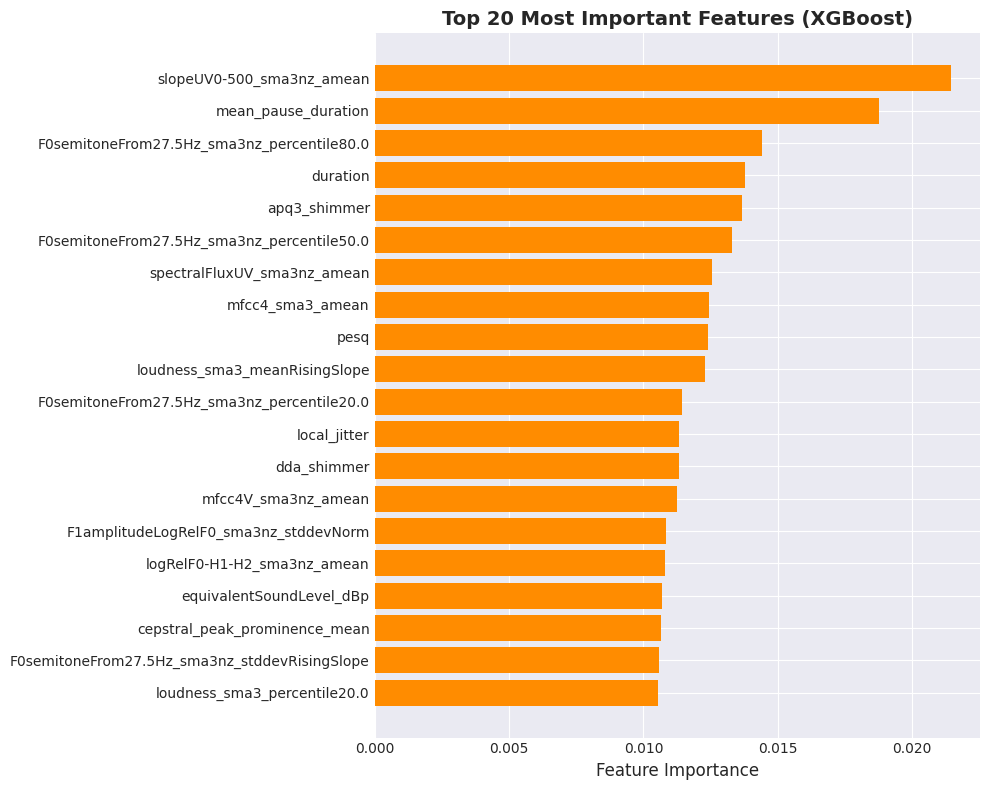

✓ Saved feature importance plot to: /home/Phenotype and Voice for PD/outputs/vae_standalone/xgb_feature_importance.png


In [34]:
# ============================================================
# XGBoost: Feature Importance Analysis
# ============================================================

print("=" * 60)
print("XGBOOST: FEATURE IMPORTANCE")
print("=" * 60)

# Get feature importance from XGBoost
xgb_importance = xgb_final.feature_importances_

# Create DataFrame
xgb_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_importance
}).sort_values('importance', ascending=False)

print(f"\nTop 20 Most Important Features (XGBoost):")
print(xgb_importance_df.head(20)[['feature', 'importance']].to_string(index=False))

# Save feature importance
xgb_importance_df.to_csv(OUTPUT_DIR / 'xgb_feature_importance.csv', index=False)
print(f"\n✓ Saved feature importance to: {OUTPUT_DIR / 'xgb_feature_importance.csv'}")

# Visualize top features
top_n = 20
top_xgb_features = xgb_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_xgb_features)), top_xgb_features['importance'].values, color='darkorange')
plt.yticks(range(len(top_xgb_features)), top_xgb_features['feature'].values)
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Top {top_n} Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved feature importance plot to: {OUTPUT_DIR / 'xgb_feature_importance.png'}")
print("=" * 60)


### 10.7. XGBoost: Performance Visualizations


RANDOM FOREST: PEXGBOOSTORMANCE VISUALIZATIONS

VISUALIZING ROC CURVE


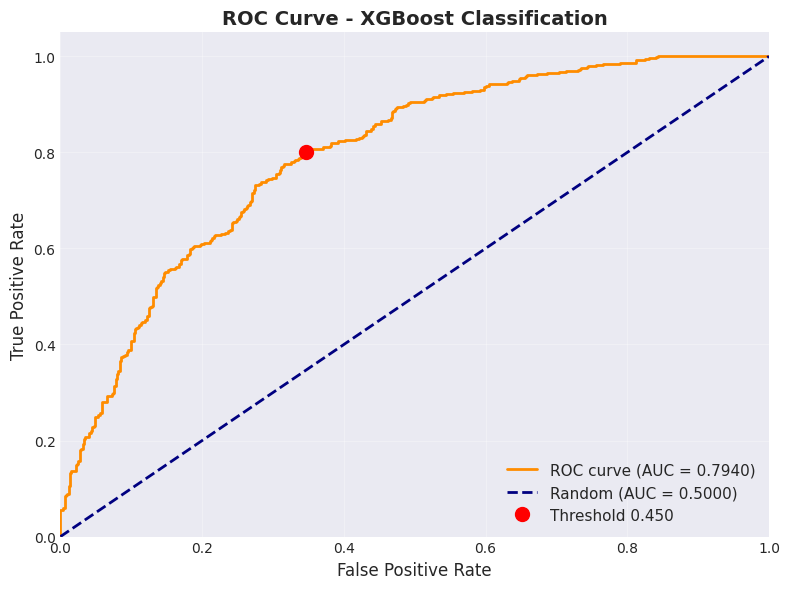

✓ ROC-AUC: 0.7940
✓ Saved ROC curve to: /home/Phenotype and Voice for PD/outputs/vae_standalone/xgb_roc_curve.png

VISUALIZING PRECISION-RECALL CURVE


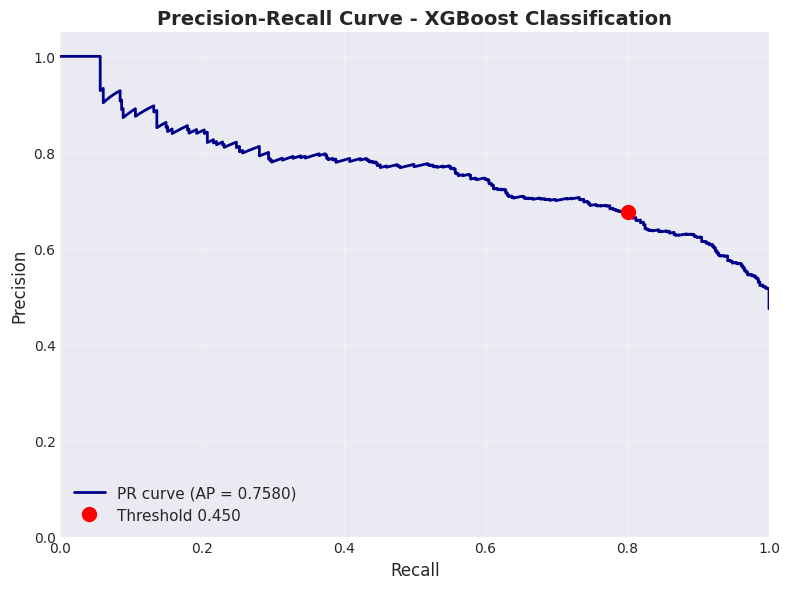

✓ Average Precision: 0.7580
✓ Saved PR curve to: /home/Phenotype and Voice for PD/outputs/vae_standalone/xgb_pr_curve.png

VISUALIZING CONFUSION MATRIX


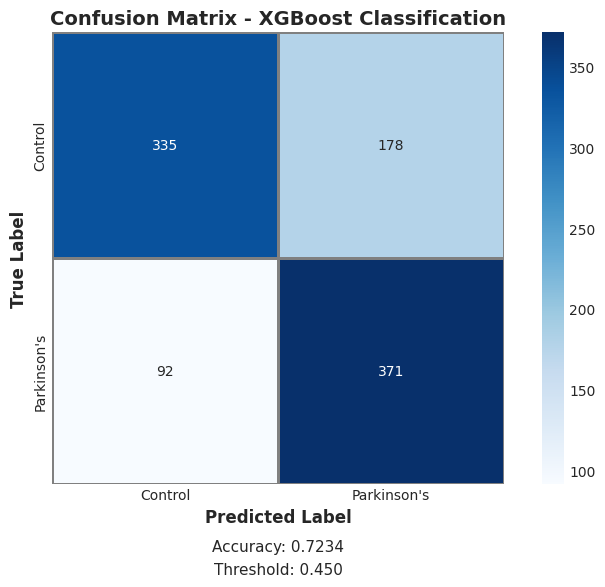

✓ Confusion Matrix:
  True Negatives (TN): 335
  False Positives (FP): 178
  False Negatives (FN): 92
  True Positives (TP): 371
✓ Saved confusion matrix to: /home/Phenotype and Voice for PD/outputs/vae_standalone/xgb_confusion_matrix.png


In [35]:
# ============================================================
# XGBoost: Performance Visualizations
# ============================================================

print("=" * 60)
print("RANDOM FOREST: PEXGBOOSTORMANCE VISUALIZATIONS")
print("=" * 60)

# Get predictions and probabilities
y_test_proba_xgb_viz = xgb_final.predict_proba(X_test_xgb)[:, 1]
y_test_pred_xgb_viz = (y_test_proba_xgb_viz >= best_threshold_xgb).astype(int)

# ROC Curve
print("\n" + "=" * 60)
print("VISUALIZING ROC CURVE")
print("=" * 60)

from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
fpr_rf, tpr_rf, _ = roc_curve(y_test_xgb, y_test_proba_xgb_viz)
roc_auc_rf = roc_auc_score(y_test_xgb, y_test_proba_xgb_viz)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5000)')

# Mark threshold point
tn, fp, fn, tp = confusion_matrix(y_test_xgb, y_test_pred_xgb_viz).ravel()
tpr_at_threshold = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr_at_threshold = fp / (fp + tn) if (fp + tn) > 0 else 0
plt.plot(fpr_at_threshold, tpr_at_threshold, 'ro', markersize=10, label=f'Threshold {best_threshold_xgb:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - XGBoost Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ ROC-AUC: {roc_auc_rf:.4f}")
print(f"✓ Saved ROC curve to: {OUTPUT_DIR / 'xgb_roc_curve.png'}")

# Precision-Recall Curve
print("\n" + "=" * 60)
print("VISUALIZING PRECISION-RECALL CURVE")
print("=" * 60)

from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score
precision_rf, recall_rf, _ = precision_recall_curve(y_test_xgb, y_test_proba_xgb_viz)
avg_precision_rf = average_precision_score(y_test_xgb, y_test_proba_xgb_viz)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, color='darkblue', lw=2, label=f'PR curve (AP = {avg_precision_rf:.4f})')

# Mark threshold point
prec_at_threshold = precision_score(y_test_xgb, y_test_pred_xgb_viz)
rec_at_threshold = recall_score(y_test_xgb, y_test_pred_xgb_viz)
plt.plot(rec_at_threshold, prec_at_threshold, 'ro', markersize=10, label=f'Threshold {best_threshold_xgb:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - XGBoost Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Average Precision: {avg_precision_rf:.4f}")
print(f"✓ Saved PR curve to: {OUTPUT_DIR / 'xgb_pr_curve.png'}")

# Confusion Matrix
print("\n" + "=" * 60)
print("VISUALIZING CONFUSION MATRIX")
print("=" * 60)

cm_rf = confusion_matrix(y_test_xgb, y_test_pred_xgb_viz)
tn, fp, fn, tp = cm_rf.ravel()
accuracy_rf = (tn + tp) / (tn + fp + fn + tp)

plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Control', "Parkinson's"],
            yticklabels=['Control', "Parkinson's"],
            square=True, linewidths=2, linecolor='gray')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - XGBoost Classification', fontsize=14, fontweight='bold')
plt.text(0.5, -0.15, f'Accuracy: {accuracy_rf:.4f}', 
         ha='center', transform=plt.gca().transAxes, fontsize=11)
plt.text(0.5, -0.20, f'Threshold: {best_threshold_xgb:.3f}', 
         ha='center', transform=plt.gca().transAxes, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Confusion Matrix:")
print(f"  True Negatives (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP): {tp}")
print(f"✓ Saved confusion matrix to: {OUTPUT_DIR / 'xgb_confusion_matrix.png'}")

print("=" * 60)


## 11. Logistic Regression Classifier


### 11.1. Logistic Regression: Hyperparameter Grid Search


In [36]:
# ============================================================
# Logistic Regression: Default Parameters
# ============================================================

from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("LOGISTIC REGRESSION: DEFAULT PARAMETERS")
print("=" * 60)

# Set default parameters for Logistic Regression
lr_best_params = {
    'C': 1.0,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    'random_state': SEED,
    'max_iter': 1000
}

print(f"\nUsing default parameters: {lr_best_params}")
print(f"\n✓ Parameters stored in 'lr_best_params' for use in 5-fold CV and final training")
print("=" * 60)


LOGISTIC REGRESSION: DEFAULT PARAMETERS

Using default parameters: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced', 'random_state': 42, 'max_iter': 1000}

✓ Parameters stored in 'lr_best_params' for use in 5-fold CV and final training


### 11.1. Logistic Regression: 5-Fold Cross-Validation


In [37]:
# ============================================================
# Logistic Regression: 5-Fold Cross-Validation
# ============================================================

print("=" * 60)
print("LOGISTIC REGRESSION: 5-FOLD CROSS-VALIDATION")
print("=" * 60)

from sklearn.linear_model import LogisticRegression

# lr_best_params should be set by grid search in section 11.0
# If grid search hasn't been run, use default parameters as fallback
if 'lr_best_params' not in globals() or lr_best_params is None:
    print("⚠ Grid search not run yet. Using default parameters.")
    lr_best_params = {
        'C': 1.0,
        'penalty': 'l2',
        'solver': 'lbfgs',
        'class_weight': 'balanced'
    }
    lr_best_params['random_state'] = SEED
    lr_best_params['max_iter'] = 1000
else:
    # Add fixed parameters that aren't in grid search
    if 'random_state' not in lr_best_params:
        lr_best_params['random_state'] = SEED
    if 'max_iter' not in lr_best_params:
        lr_best_params['max_iter'] = 1000
    print(f"✓ Using grid search parameters: {lr_best_params}")

# Prepare data for CV (combine train and val)
X_cv_lr = np.vstack([X_train_rf, X_val_rf])
y_cv_lr = np.concatenate([y_train_rf, y_val_rf])

# Get participant IDs for CV
try:
    pid_train_array = np.array(pid_train) if isinstance(pid_train, (list, pd.Series)) else pid_train
    pid_val_array = np.array(pid_val) if isinstance(pid_val, (list, pd.Series)) else pid_val
    pid_cv_lr = np.concatenate([pid_train_array, pid_val_array])
    
    unique_pids = len(np.unique(pid_cv_lr))
    use_group_kfold = unique_pids >= 5
    
    if use_group_kfold:
        print(f"✓ Found {unique_pids} unique participants")
        print("✓ Using StratifiedGroupKFold (participant-level CV - NO DATA LEAKAGE)")
    else:
        print(f"⚠ Only {unique_pids} unique participants")
        print("⚠ Falling back to StratifiedKFold (sample-level CV - RISK OF DATA LEAKAGE)")
        pid_cv_lr = None
except Exception as e:
    print(f"⚠ Error extracting participant IDs: {e}")
    use_group_kfold = False
    pid_cv_lr = None

# Setup CV
try:
    from sklearn.model_selection import StratifiedGroupKFold
    if use_group_kfold and pid_cv_lr is not None:
        skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    else:
        from sklearn.model_selection import StratifiedKFold
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        pid_cv_lr = None
except ImportError:
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    pid_cv_lr = None
    use_group_kfold = False

# Helper function for threshold tuning
def find_best_threshold_lr_cv(model, X, y):
    """Find optimal threshold for Logistic Regression based on F1-score."""
    probs = model.predict_proba(X)[:, 1]
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 19):
        pred = (probs >= t).astype(int)
        f1 = f1_score(y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

# Perform cross-validation
cv_results_lr = {
    'fold': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': [],
    'train_roc_auc': [],
    'val_roc_auc': [],
    'test_roc_auc': [],
    'train_f1': [],
    'val_f1': [],
    'test_f1': [],
    'best_threshold': []
}

print("\nStarting 5-fold cross-validation...")
if use_group_kfold and pid_cv_lr is not None:
    splits = skf.split(X_cv_lr, y_cv_lr, pid_cv_lr)
else:
    splits = skf.split(X_cv_lr, y_cv_lr)

for fold, (train_idx, test_idx) in enumerate(splits, 1):
    print(f"\n{'=' * 60}")
    print(f"FOLD {fold}/5")
    print(f"{'=' * 60}")
    
    # Split data
    X_train_cv = X_cv_lr[train_idx]
    X_test_cv = X_cv_lr[test_idx]
    y_train_cv = y_cv_lr[train_idx]
    y_test_cv = y_cv_lr[test_idx]
    
    # Further split train into train/val for threshold tuning (participant-level)
    from sklearn.model_selection import train_test_split
    
    if use_group_kfold and pid_cv_lr is not None:
        train_pids = pid_cv_lr[train_idx]
        unique_train_pids = np.unique(train_pids)
        pid_to_label = {}
        for pid, label in zip(train_pids, y_train_cv):
            if pid not in pid_to_label:
                pid_to_label[pid] = label
        participant_labels_fold = np.array([pid_to_label[pid] for pid in unique_train_pids])
        
        pids_train_fold, pids_val_fold, y_p_train_fold, y_p_val_fold = train_test_split(
            unique_train_pids, participant_labels_fold,
            test_size=0.2, random_state=SEED + fold, stratify=participant_labels_fold
        )
        
        train_fold_mask = np.isin(train_pids, pids_train_fold)
        val_fold_mask = np.isin(train_pids, pids_val_fold)
        
        X_train_fold = X_train_cv[train_fold_mask]
        X_val_fold = X_train_cv[val_fold_mask]
        y_train_fold = y_train_cv[train_fold_mask]
        y_val_fold = y_train_cv[val_fold_mask]
    else:
        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(
            X_train_cv, y_train_cv, test_size=0.2, random_state=SEED + fold, stratify=y_train_cv
        )
    
    print(f"Train: {X_train_fold.shape[0]} samples ({np.sum(y_train_fold == 0)} Control, {np.sum(y_train_fold == 1)} PD)")
    print(f"Val: {X_val_fold.shape[0]} samples ({np.sum(y_val_fold == 0)} Control, {np.sum(y_val_fold == 1)} PD)")
    print(f"Test: {X_test_cv.shape[0]} samples ({np.sum(y_test_cv == 0)} Control, {np.sum(y_test_cv == 1)} PD)")
    
    # Train model
    lr_model = LogisticRegression(**lr_best_params)
    lr_model.fit(X_train_fold, y_train_fold)
    
    # Evaluate on train, val, and test
    for split_name, X_split, y_split in [('train', X_train_fold, y_train_fold),
                                          ('val', X_val_fold, y_val_fold),
                                          ('test', X_test_cv, y_test_cv)]:
        y_pred = lr_model.predict(X_split)
        y_proba = lr_model.predict_proba(X_split)[:, 1]
        
        acc = accuracy_score(y_split, y_pred)
        auc = roc_auc_score(y_split, y_proba)
        f1 = f1_score(y_split, y_pred)
        
        cv_results_lr[f'{split_name}_acc'].append(acc)
        cv_results_lr[f'{split_name}_roc_auc'].append(auc)
        cv_results_lr[f'{split_name}_f1'].append(f1)
    
    # Find best threshold on validation set
    best_thresh, best_val_f1 = find_best_threshold_lr_cv(lr_model, X_val_fold, y_val_fold)
    cv_results_lr['best_threshold'].append(best_thresh)
    
    print(f"\nFold {fold} Results:")
    print(f"  Train - Acc: {cv_results_lr['train_acc'][-1]:.4f}, ROC-AUC: {cv_results_lr['train_roc_auc'][-1]:.4f}, F1: {cv_results_lr['train_f1'][-1]:.4f}")
    print(f"  Val   - Acc: {cv_results_lr['val_acc'][-1]:.4f}, ROC-AUC: {cv_results_lr['val_roc_auc'][-1]:.4f}, F1: {cv_results_lr['val_f1'][-1]:.4f}")
    print(f"  Test  - Acc: {cv_results_lr['test_acc'][-1]:.4f}, ROC-AUC: {cv_results_lr['test_roc_auc'][-1]:.4f}, F1: {cv_results_lr['test_f1'][-1]:.4f}")
    print(f"  Best Threshold: {best_thresh:.3f} (Val F1={best_val_f1:.4f})")
    
    cv_results_lr['fold'].append(fold)

# Summary
print("\n" + "=" * 60)
print("CROSS-VALIDATION SUMMARY")
print("=" * 60)
print(f"Test Accuracy: {np.mean(cv_results_lr['test_acc']):.4f} ± {np.std(cv_results_lr['test_acc']):.4f}")
print(f"Test ROC-AUC: {np.mean(cv_results_lr['test_roc_auc']):.4f} ± {np.std(cv_results_lr['test_roc_auc']):.4f}")
print(f"Test F1: {np.mean(cv_results_lr['test_f1']):.4f} ± {np.std(cv_results_lr['test_f1']):.4f}")

# Save CV results
cv_results_lr_df = pd.DataFrame(cv_results_lr)
cv_results_lr_df.to_csv(OUTPUT_DIR / 'lr_cv_results.csv', index=False)
print(f"\n✓ Saved CV results to: {OUTPUT_DIR / 'lr_cv_results.csv'}")
print("=" * 60)


LOGISTIC REGRESSION: 5-FOLD CROSS-VALIDATION
✓ Using grid search parameters: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs', 'class_weight': 'balanced', 'random_state': 42, 'max_iter': 1000}
✓ Found 100 unique participants
✓ Using StratifiedGroupKFold (participant-level CV - NO DATA LEAKAGE)

Starting 5-fold cross-validation...

FOLD 1/5
Train: 2522 samples (1288 Control, 1234 PD)
Val: 640 samples (310 Control, 330 PD)
Test: 741 samples (327 Control, 414 PD)

Fold 1 Results:
  Train - Acc: 0.7557, ROC-AUC: 0.8392, F1: 0.7504
  Val   - Acc: 0.5188, ROC-AUC: 0.5070, F1: 0.4797
  Test  - Acc: 0.6829, ROC-AUC: 0.7338, F1: 0.7073
  Best Threshold: 0.050 (Val F1=0.6638)

FOLD 2/5
Train: 2424 samples (1187 Control, 1237 PD)
Val: 620 samples (303 Control, 317 PD)
Test: 859 samples (435 Control, 424 PD)

Fold 2 Results:
  Train - Acc: 0.7562, ROC-AUC: 0.8317, F1: 0.7602
  Val   - Acc: 0.6806, ROC-AUC: 0.7532, F1: 0.6972
  Test  - Acc: 0.6240, ROC-AUC: 0.6644, F1: 0.6431
  Best Threshold: 0.300 (

### 11.2. Logistic Regression: CV Results Visualization


LR: CV RESULTS VISUALIZATION
✓ Saved CV visualization to: /home/Phenotype and Voice for PD/outputs/vae_standalone/lr_cv_results_visualization.png


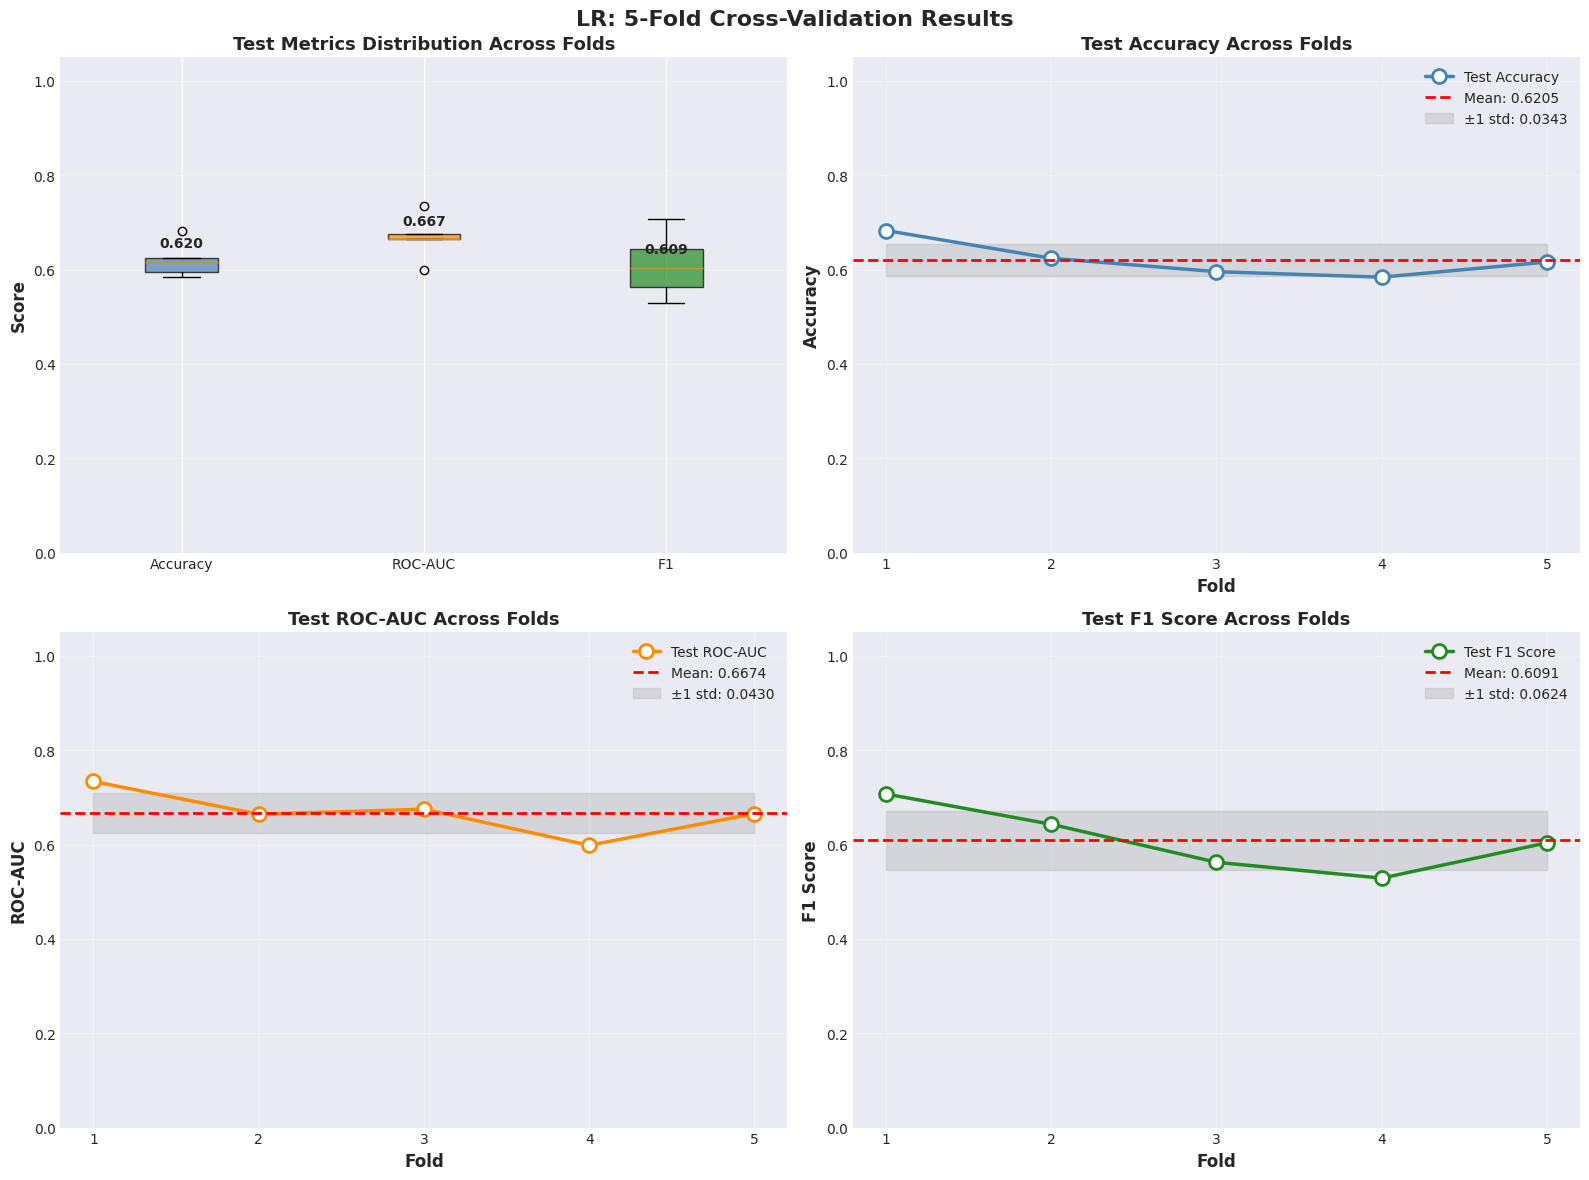


LR - CV Summary Statistics:
  Test Accuracy: 0.6205 ± 0.0343
  Test ROC-AUC:  0.6674 ± 0.0430
  Test F1 Score: 0.6091 ± 0.0624


In [38]:
# ============================================================
# LR: CV Results Visualization
# ============================================================

print("=" * 60)
print("LR: CV RESULTS VISUALIZATION")
print("=" * 60)

if 'cv_results_lr_df' in globals():
    plot_cv_results_standardized(
        cv_results_lr_df,
        model_name='LR',
        save_path=OUTPUT_DIR / 'lr_cv_results_visualization.png'
    )
else:
    print(f"⚠ cv_results_lr_df not found. Run CV section first.")
print("=" * 60)


### 11.3. Logistic Regression: Train and Evaluate


In [39]:
# ============================================================
# Logistic Regression: Train on Full Training Data and Evaluate
# ============================================================

print("=" * 60)
print("LOGISTIC REGRESSION: TRAINING AND EVALUATION")
print("=" * 60)

# Helper function for threshold tuning
def find_best_threshold_lr(model, X, y):
    """Find optimal threshold for Logistic Regression based on F1-score."""
    probs = model.predict_proba(X)[:, 1]
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 19):
        pred = (probs >= t).astype(int)
        f1 = f1_score(y, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

# Train on full training data
print("\nTraining Logistic Regression on full training data...")
lr_final = LogisticRegression(**lr_best_params)
lr_final.fit(X_train_val_rf, y_train_val_rf)

# Find best threshold on validation data
best_threshold_lr, best_val_f1_lr = find_best_threshold_lr(lr_final, X_val_rf, y_val_rf)
print(f"Best threshold: {best_threshold_lr:.3f} (val F1={best_val_f1_lr:.4f})")

# Evaluate on test data
y_test_proba_lr = lr_final.predict_proba(X_test_rf)[:, 1]
y_test_pred_lr = (y_test_proba_lr >= best_threshold_lr).astype(int)

metrics_lr = {
    'accuracy': accuracy_score(y_test_rf, y_test_pred_lr),
    'roc_auc': roc_auc_score(y_test_rf, y_test_proba_lr),
    'f1': f1_score(y_test_rf, y_test_pred_lr),
    'precision': precision_score(y_test_rf, y_test_pred_lr),
    'recall': recall_score(y_test_rf, y_test_pred_lr)
}

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE ON TEST DATA")
print("=" * 60)
for k, v in metrics_lr.items():
    print(f"  {k}: {v:.4f}")
print(f"  (using threshold: {best_threshold_lr:.3f})")
print("=" * 60)


LOGISTIC REGRESSION: TRAINING AND EVALUATION

Training Logistic Regression on full training data...
Best threshold: 0.350 (val F1=0.7536)

LOGISTIC REGRESSION PERFORMANCE ON TEST DATA
  accuracy: 0.6291
  roc_auc: 0.7397
  f1: 0.6774
  precision: 0.5766
  recall: 0.8207
  (using threshold: 0.350)


### 11.4. Logistic Regression: Performance Visualizations


RANDOM FOREST: PELOGISTIC REGRESSIONORMANCE VISUALIZATIONS

VISUALIZING ROC CURVE


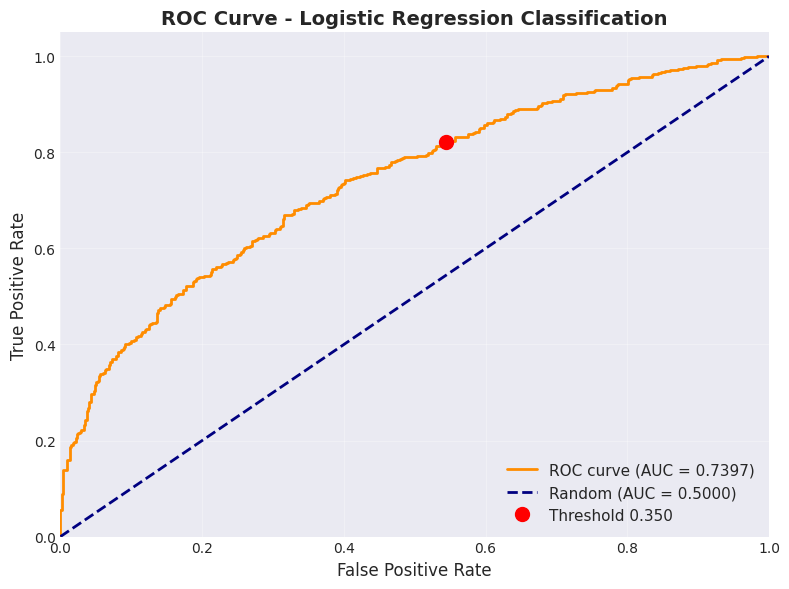

✓ ROC-AUC: 0.7397
✓ Saved ROC curve to: /home/Phenotype and Voice for PD/outputs/vae_standalone/lr_roc_curve.png

VISUALIZING PRECISION-RECALL CURVE


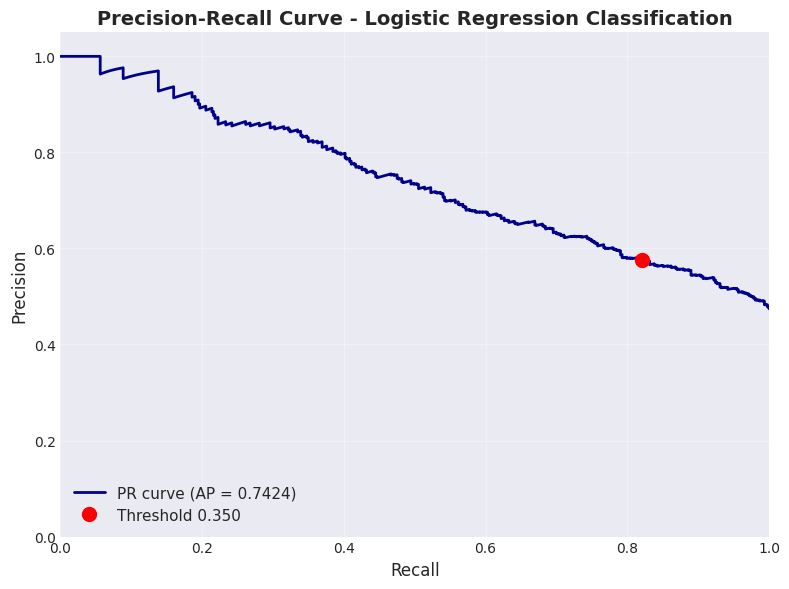

✓ Average Precision: 0.7424
✓ Saved PR curve to: /home/Phenotype and Voice for PD/outputs/vae_standalone/lr_pr_curve.png

VISUALIZING CONFUSION MATRIX


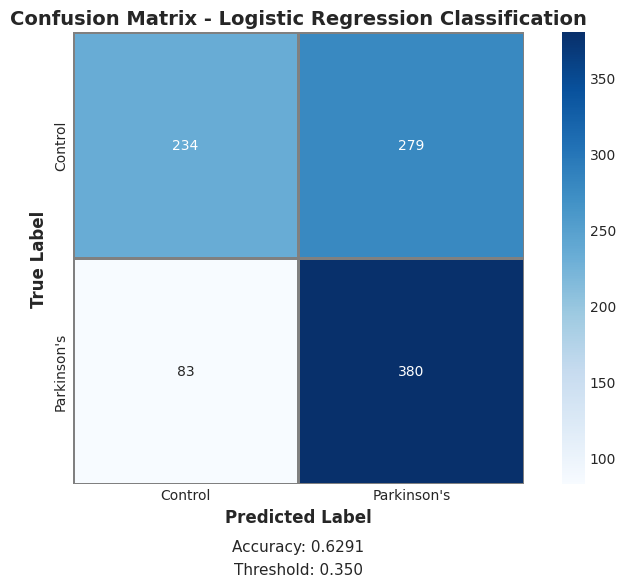

✓ Confusion Matrix:
  True Negatives (TN): 234
  False Positives (FP): 279
  False Negatives (FN): 83
  True Positives (TP): 380
✓ Saved confusion matrix to: /home/Phenotype and Voice for PD/outputs/vae_standalone/lr_confusion_matrix.png


In [40]:
# ============================================================
# Logistic Regression: Performance Visualizations
# ============================================================

print("=" * 60)
print("RANDOM FOREST: PELOGISTIC REGRESSIONORMANCE VISUALIZATIONS")
print("=" * 60)

# Get predictions and probabilities
y_test_proba_lr_viz = lr_final.predict_proba(X_test_rf)[:, 1]
y_test_pred_lr_viz = (y_test_proba_lr_viz >= best_threshold_lr).astype(int)

# ROC Curve
print("\n" + "=" * 60)
print("VISUALIZING ROC CURVE")
print("=" * 60)

from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_test_proba_lr_viz)
roc_auc_rf = roc_auc_score(y_test_rf, y_test_proba_lr_viz)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5000)')

# Mark threshold point
tn, fp, fn, tp = confusion_matrix(y_test_rf, y_test_pred_lr_viz).ravel()
tpr_at_threshold = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr_at_threshold = fp / (fp + tn) if (fp + tn) > 0 else 0
plt.plot(fpr_at_threshold, tpr_at_threshold, 'ro', markersize=10, label=f'Threshold {best_threshold_lr:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lr_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ ROC-AUC: {roc_auc_rf:.4f}")
print(f"✓ Saved ROC curve to: {OUTPUT_DIR / 'lr_roc_curve.png'}")

# Precision-Recall Curve
print("\n" + "=" * 60)
print("VISUALIZING PRECISION-RECALL CURVE")
print("=" * 60)

from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score
precision_rf, recall_rf, _ = precision_recall_curve(y_test_rf, y_test_proba_lr_viz)
avg_precision_rf = average_precision_score(y_test_rf, y_test_proba_lr_viz)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, color='darkblue', lw=2, label=f'PR curve (AP = {avg_precision_rf:.4f})')

# Mark threshold point
prec_at_threshold = precision_score(y_test_rf, y_test_pred_lr_viz)
rec_at_threshold = recall_score(y_test_rf, y_test_pred_lr_viz)
plt.plot(rec_at_threshold, prec_at_threshold, 'ro', markersize=10, label=f'Threshold {best_threshold_lr:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Logistic Regression Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lr_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Average Precision: {avg_precision_rf:.4f}")
print(f"✓ Saved PR curve to: {OUTPUT_DIR / 'lr_pr_curve.png'}")

# Confusion Matrix
print("\n" + "=" * 60)
print("VISUALIZING CONFUSION MATRIX")
print("=" * 60)

cm_rf = confusion_matrix(y_test_rf, y_test_pred_lr_viz)
tn, fp, fn, tp = cm_rf.ravel()
accuracy_rf = (tn + tp) / (tn + fp + fn + tp)

plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Control', "Parkinson's"],
            yticklabels=['Control', "Parkinson's"],
            square=True, linewidths=2, linecolor='gray')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Logistic Regression Classification', fontsize=14, fontweight='bold')
plt.text(0.5, -0.15, f'Accuracy: {accuracy_rf:.4f}', 
         ha='center', transform=plt.gca().transAxes, fontsize=11)
plt.text(0.5, -0.20, f'Threshold: {best_threshold_lr:.3f}', 
         ha='center', transform=plt.gca().transAxes, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Confusion Matrix:")
print(f"  True Negatives (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP): {tp}")
print(f"✓ Saved confusion matrix to: {OUTPUT_DIR / 'lr_confusion_matrix.png'}")

print("=" * 60)


## 12. Comprehensive Model Comparison


MODEL COMPARISON: ALL MODELS

                    Model  Accuracy  ROC-AUC  F1 Score  Precision   Recall  Threshold
Neural Network (Baseline)  0.714139 0.792888  0.722388   0.669742 0.784017       0.40
            Random Forest  0.717213 0.809880  0.739623   0.656616 0.846652       0.45
                  XGBoost  0.723361 0.794004  0.733202   0.675774 0.801296       0.45
      Logistic Regression  0.629098 0.739650  0.677362   0.576631 0.820734       0.35

✓ Saved model comparison to: /home/Phenotype and Voice for PD/outputs/vae_standalone/model_comparison.csv


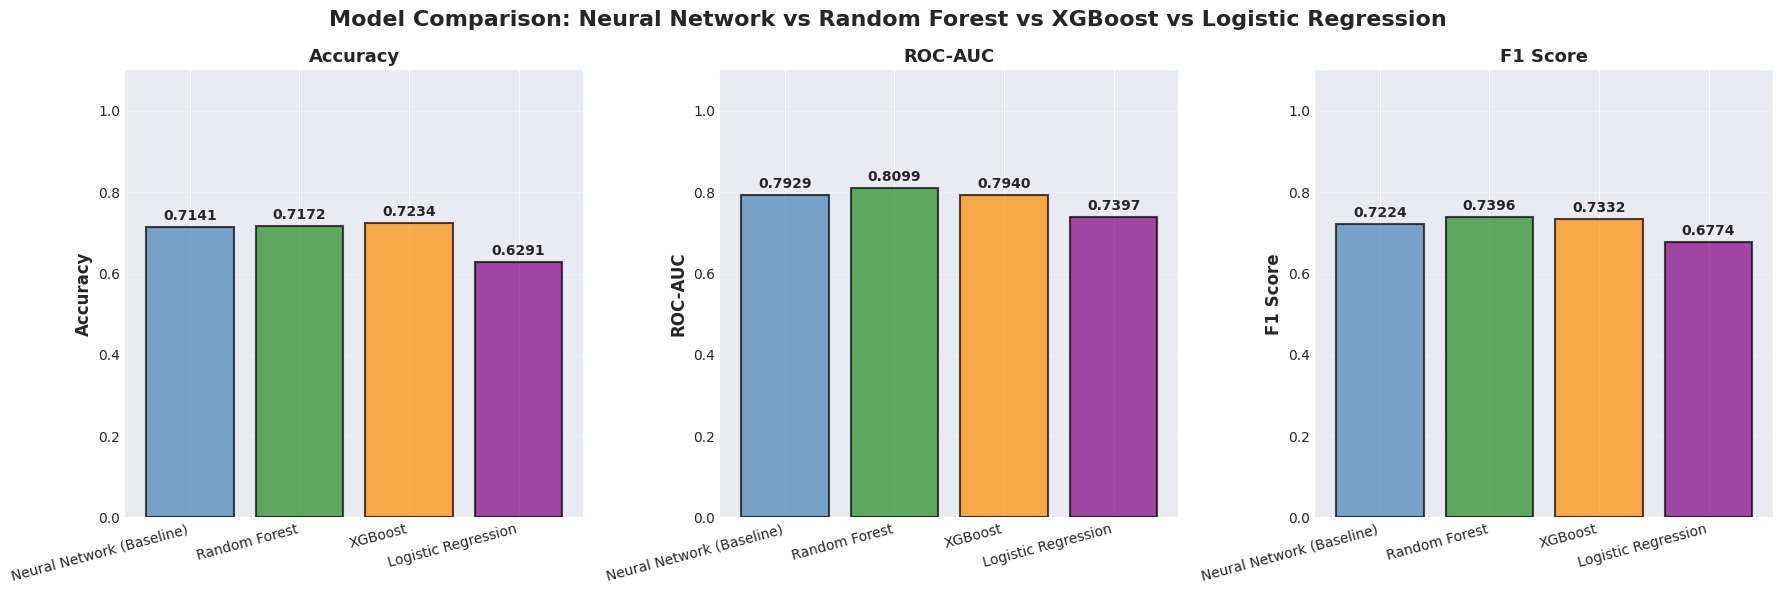

✓ Saved model comparison plot to: /home/Phenotype and Voice for PD/outputs/vae_standalone/model_comparison.png

FEATURE IMPORTANCE COMPARISON (Top 10)

Top 10 Features - Neural Network (Permutation Importance):
   1. mfcc3_sma3_amean
   2. MeanVoicedSegmentLengthSec
   3. mfcc4V_sma3nz_amean
   4. mfcc2V_sma3nz_amean
   5. hammarbergIndexV_sma3nz_amean
   6. F3frequency_sma3nz_stddevNorm
   7. mfcc2_sma3_amean
   8. std_f1_loc
   9. HNRdBACF_sma3nz_amean
  10. F1frequency_sma3nz_amean

Top 10 Features - Random Forest (Gini Importance):
   1. slopeUV0-500_sma3nz_amean
   2. mfcc4_sma3_amean
   3. duration
   4. equivalentSoundLevel_dBp
   5. alphaRatioUV_sma3nz_amean
   6. hammarbergIndexUV_sma3nz_amean
   7. spectralFlux_sma3_amean
   8. spectralFluxUV_sma3nz_amean
   9. pesq
  10. F0semitoneFrom27.5Hz_sma3nz_percentile50.0

Top 10 Features - XGBoost (Gain Importance):
   1. slopeUV0-500_sma3nz_amean
   2. mean_pause_duration
   3. F0semitoneFrom27.5Hz_sma3nz_percentile80.0
   4. durat

In [41]:
# ============================================================
# Model Comparison: Neural Network vs Random Forest vs XGBoost vs Logistic Regression
# ============================================================

print("=" * 60)
print("MODEL COMPARISON: ALL MODELS")
print("=" * 60)

# Get baseline neural network metrics
metrics_baseline_nn = metrics_real_baseline

# Handle case where precision/recall might not be in old metrics
if 'precision' not in metrics_baseline_nn:
    # Recalculate if missing
    print("⚠ Recalculating precision/recall for neural network...")
    y_test_probs_nn = []
    y_test_labels_nn = []
    model_real_baseline.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model_real_baseline(xb)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            y_test_probs_nn.extend(probs)
            y_test_labels_nn.extend(yb.numpy().flatten())
    
    y_test_probs_nn = np.array(y_test_probs_nn)
    y_test_labels_nn = np.array(y_test_labels_nn).astype(int)
    y_test_preds_nn = (y_test_probs_nn >= best_threshold).astype(int)
    
    metrics_baseline_nn['precision'] = precision_score(y_test_labels_nn, y_test_preds_nn, zero_division=0)
    metrics_baseline_nn['recall'] = recall_score(y_test_labels_nn, y_test_preds_nn, zero_division=0)

# Create comparison DataFrame
comparison_data = {
    'Model': ['Neural Network (Baseline)', 'Random Forest', 'XGBoost', 'Logistic Regression'],
    'Accuracy': [metrics_baseline_nn['accuracy'], metrics_rf['accuracy'], metrics_xgb['accuracy'], metrics_lr['accuracy']],
    'ROC-AUC': [metrics_baseline_nn['roc_auc'], metrics_rf['roc_auc'], metrics_xgb['roc_auc'], metrics_lr['roc_auc']],
    'F1 Score': [metrics_baseline_nn['f1'], metrics_rf['f1'], metrics_xgb['f1'], metrics_lr['f1']],
    'Precision': [metrics_baseline_nn.get('precision', np.nan), metrics_rf['precision'], metrics_xgb['precision'], metrics_lr['precision']],
    'Recall': [metrics_baseline_nn.get('recall', np.nan), metrics_rf['recall'], metrics_xgb['recall'], metrics_lr['recall']],
    'Threshold': [best_threshold, best_threshold_rf, best_threshold_xgb, best_threshold_lr]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print(f"\n✓ Saved model comparison to: {OUTPUT_DIR / 'model_comparison.csv'}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison: Neural Network vs Random Forest vs XGBoost vs Logistic Regression', 
             fontsize=16, fontweight='bold')

metrics_to_plot = ['Accuracy', 'ROC-AUC', 'F1 Score']
colors = ['steelblue', 'forestgreen', 'darkorange', 'purple']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    x_pos = np.arange(len(comparison_df))
    bars = ax.bar(x_pos, comparison_df[metric], color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, comparison_df[metric])):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right', fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved model comparison plot to: {OUTPUT_DIR / 'model_comparison.png'}")

# Compare feature importance (top features)
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE COMPARISON (Top 10)")
print("=" * 60)

# Get top 10 from each (if available)
if importance_df is not None:
    top_nn_features = importance_df.head(10)['feature'].values
    print("\nTop 10 Features - Neural Network (Permutation Importance):")
    for i, feat in enumerate(top_nn_features, 1):
        print(f"  {i:2d}. {feat}")

if rf_importance_df is not None:
    top_rf_features = rf_importance_df.head(10)['feature'].values
    print("\nTop 10 Features - Random Forest (Gini Importance):")
    for i, feat in enumerate(top_rf_features, 1):
        print(f"  {i:2d}. {feat}")

if xgb_importance_df is not None:
    top_xgb_features = xgb_importance_df.head(10)['feature'].values
    print("\nTop 10 Features - XGBoost (Gain Importance):")
    for i, feat in enumerate(top_xgb_features, 1):
        print(f"  {i:2d}. {feat}")

# Find common features across models
if importance_df is not None and rf_importance_df is not None and xgb_importance_df is not None:
    common_all = set(top_nn_features) & set(top_rf_features) & set(top_xgb_features)
    common_nn_rf = set(top_nn_features) & set(top_rf_features)
    common_nn_xgb = set(top_nn_features) & set(top_xgb_features)
    common_rf_xgb = set(top_rf_features) & set(top_xgb_features)
    
    print(f"\n✓ Common features in top 10 (all 3 models): {len(common_all)}")
    if len(common_all) > 0:
        print(f"  Common (all): {', '.join(list(common_all)[:5])}{'...' if len(common_all) > 5 else ''}")
    
    print(f"\n✓ Common features (NN & RF): {len(common_nn_rf)}")
    print(f"✓ Common features (NN & XGB): {len(common_nn_xgb)}")
    print(f"✓ Common features (RF & XGB): {len(common_rf_xgb)}")

print("=" * 60)


## 13. Summary and Notes

**Note:** Advanced feature analysis and clustering (correlation-based clustering, SHAP analysis, network graphs, etc.) have been moved to a separate notebook: `Advanced_Feature_Analysis_and_Clustering.ipynb`


In [42]:
# ============================================================
# Save Feature Data for Feature Analysis Notebook
# ============================================================

print("=" * 60)
print("SAVING FEATURE DATA FOR FEATURE ANALYSIS NOTEBOOK")
print("=" * 60)

# Save feature data for feature analysis notebook
# Try multiple variable names that might exist
X_train_data = None
y_train_data = None

# Check for X_train (DataFrame) or X_train_rf (numpy array)
# Priority: X_train_rf (most likely to exist after Random Forest section) > X_train (DataFrame) > X_train_np_real
if 'X_train_rf' in globals():
    X_train_data = X_train_rf
    print("✓ Using X_train_rf (numpy array)")
elif 'X_train' in globals() and hasattr(X_train, 'values'):
    X_train_data = X_train.values
    print("✓ Using X_train (DataFrame)")
elif 'X_train_np_real' in globals():
    X_train_data = X_train_np_real
    print("✓ Using X_train_np_real (numpy array)")
elif 'X_train_scaled' in globals():
    # Fallback: use scaled training data if available
    if hasattr(X_train_scaled, 'values'):
        X_train_data = X_train_scaled.values
    else:
        X_train_data = X_train_scaled
    print("✓ Using X_train_scaled")
else:
    print("⚠ X_train_rf, X_train, X_train_np_real, or X_train_scaled not found")

# Check for labels
if 'y_train_rf' in globals():
    y_train_data = y_train_rf
    print("✓ Using y_train_rf")
elif 'y_train' in globals():
    y_train_data = y_train.values if hasattr(y_train, 'values') else y_train
    print("✓ Using y_train")
else:
    print("⚠ y_train_rf or y_train not found")

# Save if we have the data
if X_train_data is not None and 'feature_cols' in globals():
    X_train_df = pd.DataFrame(X_train_data, columns=feature_cols)
    X_train_df.to_csv(OUTPUT_DIR / 'X_train_features.csv', index=False)
    print(f"✓ Saved feature data to: {OUTPUT_DIR / 'X_train_features.csv'}")
    print(f"  Shape: {X_train_df.shape}")
    
    # Save feature column names
    pd.Series(feature_cols).to_csv(OUTPUT_DIR / 'feature_cols.csv', index=False)
    print(f"✓ Saved feature column names to: {OUTPUT_DIR / 'feature_cols.csv'}")
    
    # Save labels if available
    if y_train_data is not None:
        pd.DataFrame(y_train_data, columns=['label']).to_csv(OUTPUT_DIR / 'y_train_labels.csv', index=False)
        print(f"✓ Saved labels to: {OUTPUT_DIR / 'y_train_labels.csv'}")
        print(f"  Shape: {len(y_train_data)} samples")
        print(f"  Class distribution: {np.bincount(y_train_data.astype(int))}")
    else:
        print("⚠ Labels not available, skipping label save")
else:
    print("⚠ Cannot save feature data:")
    if X_train_data is None:
        print("  - Feature data (X_train/X_train_rf) not found")
    if 'feature_cols' not in globals():
        print("  - feature_cols not found")
    print("  Make sure data preprocessing cells have been run.")

print("=" * 60)

# ============================================================
# Summary
# ============================================================

print("=" * 60)
print("NOTEBOOK SUMMARY")
print("=" * 60)

print(f"\nFeature Configuration:")
if 'USE_PHENOTYPE_FEATURES' in globals():
    if USE_PHENOTYPE_FEATURES:
        print("  ✓ Using: Phenotype/Demographic features + Acoustic features")
    else:
        print("  ✓ Using: Acoustic features only")
else:
    print("  ⚠ USE_PHENOTYPE_FEATURES not defined (configuration cell may not have been run)")

print(f"\nModels Trained and Evaluated:")
print("  1. Neural Network (Baseline)")
print("  2. Random Forest")
print("  3. XGBoost")
print("  4. Logistic Regression")

print(f"\nAll models use:")
print("  - 5-fold participant-level cross-validation")
print("  - Fixed best-practice hyperparameters (no grid search)")
print("  - Threshold tuning on validation set")
print("  - Evaluation on held-out test set")

print(f"\nResults saved to: {OUTPUT_DIR}")
print("=" * 60)


SAVING FEATURE DATA FOR FEATURE ANALYSIS NOTEBOOK
✓ Using X_train_rf (numpy array)
✓ Using y_train_rf
✓ Saved feature data to: /home/Phenotype and Voice for PD/outputs/vae_standalone/X_train_features.csv
  Shape: (3071, 131)
✓ Saved feature column names to: /home/Phenotype and Voice for PD/outputs/vae_standalone/feature_cols.csv
✓ Saved labels to: /home/Phenotype and Voice for PD/outputs/vae_standalone/y_train_labels.csv
  Shape: 3071 samples
  Class distribution: [1514 1557]
NOTEBOOK SUMMARY

Feature Configuration:
  ✓ Using: Acoustic features only

Models Trained and Evaluated:
  1. Neural Network (Baseline)
  2. Random Forest
  3. XGBoost
  4. Logistic Regression

All models use:
  - 5-fold participant-level cross-validation
  - Fixed best-practice hyperparameters (no grid search)
  - Threshold tuning on validation set
  - Evaluation on held-out test set

Results saved to: /home/Phenotype and Voice for PD/outputs/vae_standalone


## 14. Patient-Level Prediction from Original Features

This section aggregates recording-level features to create patient-level representations and trains models to predict PD vs Control at the patient level using conventional aggregation methods.

**Approach:**
1. Use original features (not cluster-based features)
2. Aggregate recording-level features across all recordings for each patient using multiple methods (mean, median, max, min, std)
3. Create patient-level labels (one label per patient)
4. Train all 4 models (Neural Network, Random Forest, XGBoost, Logistic Regression) on patient-level data
5. Evaluate performance at patient level

This allows us to leverage all recordings from each patient while making predictions at the patient level, which is more clinically relevant.


In [43]:
# ============================================================
# Patient-Level Prediction: Step 1 - Aggregate Recordings to Patient Level
# ============================================================

print("=" * 80)
print("PATIENT-LEVEL PREDICTION: STEP 1 - AGGREGATE RECORDINGS TO PATIENT LEVEL")
print("=" * 80)

def aggregate_recordings_to_patient_level(X_recording_features, participant_ids, aggregation_method='mean'):
    """
    Aggregate recording-level features to patient level.
    
    Parameters:
    -----------
    X_recording_features : np.ndarray, shape (n_recordings, n_features)
        Recording-level feature matrix
    participant_ids : np.ndarray, shape (n_recordings,)
        Participant ID for each recording
    aggregation_method : str
        Method to aggregate: 'mean', 'median', 'max', 'min', 'std'
    
    Returns:
    --------
    X_patient : np.ndarray, shape (n_patients, n_features)
        Patient-level aggregated feature matrix
    patient_ids : np.ndarray, shape (n_patients,)
        Unique participant IDs (sorted)
    """
    unique_patients = np.unique(participant_ids)
    n_patients = len(unique_patients)
    n_features = X_recording_features.shape[1]
    
    X_patient = np.zeros((n_patients, n_features))
    
    for i, patient_id in enumerate(unique_patients):
        # Get all recordings for this patient
        patient_mask = participant_ids == patient_id
        patient_recordings = X_recording_features[patient_mask]
        
        # Aggregate based on method
        if aggregation_method == 'mean':
            X_patient[i] = np.mean(patient_recordings, axis=0)
        elif aggregation_method == 'median':
            X_patient[i] = np.median(patient_recordings, axis=0)
        elif aggregation_method == 'max':
            X_patient[i] = np.max(patient_recordings, axis=0)
        elif aggregation_method == 'min':
            X_patient[i] = np.min(patient_recordings, axis=0)
        elif aggregation_method == 'std':
            X_patient[i] = np.std(patient_recordings, axis=0)
        else:
            raise ValueError(f"Unknown aggregation method: {aggregation_method}")
    
    return X_patient, unique_patients

def create_patient_labels(participant_ids, recording_labels):
    """
    Create patient-level labels from recording-level labels.
    Uses majority vote (or first label if all are same).
    
    Parameters:
    -----------
    participant_ids : np.ndarray, shape (n_recordings,)
        Participant ID for each recording
    recording_labels : pd.Series or np.ndarray, shape (n_recordings,)
        Labels for each recording
    
    Returns:
    --------
    patient_labels : np.ndarray, shape (n_patients,)
        Labels for each patient (sorted by participant_id)
    unique_patient_ids : np.ndarray, shape (n_patients,)
        Unique participant IDs (sorted)
    """
    # Convert to numpy if needed
    if isinstance(recording_labels, pd.Series):
        recording_labels = recording_labels.values
    
    unique_patients = np.unique(participant_ids)
    patient_labels = np.zeros(len(unique_patients))
    
    for i, patient_id in enumerate(unique_patients):
        # Get all labels for this patient
        patient_mask = participant_ids == patient_id
        patient_recording_labels = recording_labels[patient_mask]
        
        # Use majority vote
        patient_labels[i] = int(np.round(np.mean(patient_recording_labels)))
    
    return patient_labels, unique_patients

# Define aggregation methods to try
PATIENT_AGG_METHODS = ['mean', 'median', 'max', 'min', 'std']

print(f"\nAggregation methods to try: {PATIENT_AGG_METHODS}")
print(f"\nAggregating recordings to patient level for each method...")

# Store patient-level features for each aggregation method
patient_features_dict = {}

for agg_method in PATIENT_AGG_METHODS:
    print(f"\n  Processing {agg_method} aggregation...")
    
    # Aggregate train/val/test separately
    X_train_patient, pids_train_unique = aggregate_recordings_to_patient_level(
        X_train_scaled, pid_train, aggregation_method=agg_method
    )
    X_val_patient, pids_val_unique = aggregate_recordings_to_patient_level(
        X_val_scaled, pid_val, aggregation_method=agg_method
    )
    X_test_patient, pids_test_unique = aggregate_recordings_to_patient_level(
        X_test_scaled, pid_test, aggregation_method=agg_method
    )
    
    patient_features_dict[agg_method] = {
        'X_train': X_train_patient,
        'X_val': X_val_patient,
        'X_test': X_test_patient,
        'pids_train': pids_train_unique,
        'pids_val': pids_val_unique,
        'pids_test': pids_test_unique
    }
    
    print(f"    Train: {X_train_patient.shape} ({len(pids_train_unique)} patients)")
    print(f"    Val:   {X_val_patient.shape} ({len(pids_val_unique)} patients)")
    print(f"    Test:  {X_test_patient.shape} ({len(pids_test_unique)} patients)")

# Create patient-level labels
print(f"\nCreating patient-level labels...")
y_train_patient, pids_train_check = create_patient_labels(pid_train, y_train_raw)
y_val_patient, pids_val_check = create_patient_labels(pid_val, y_val_raw)
y_test_patient, pids_test_check = create_patient_labels(pid_test, y_test_raw)

print(f"\n✓ Patient-level labels created:")
print(f"  Train: {len(y_train_patient)} patients (Control: {(y_train_patient == 0).sum()}, PD: {(y_train_patient == 1).sum()})")
print(f"  Val:   {len(y_val_patient)} patients (Control: {(y_val_patient == 0).sum()}, PD: {(y_val_patient == 1).sum()})")
print(f"  Test:  {len(y_test_patient)} patients (Control: {(y_test_patient == 0).sum()}, PD: {(y_test_patient == 1).sum()})")

print(f"\n✓ Patient-level features created for all aggregation methods")


PATIENT-LEVEL PREDICTION: STEP 1 - AGGREGATE RECORDINGS TO PATIENT LEVEL

Aggregation methods to try: ['mean', 'median', 'max', 'min', 'std']

Aggregating recordings to patient level for each method...

  Processing mean aggregation...
    Train: (80, 131) (80 patients)
    Val:   (20, 131) (20 patients)
    Test:  (25, 131) (25 patients)

  Processing median aggregation...
    Train: (80, 131) (80 patients)
    Val:   (20, 131) (20 patients)
    Test:  (25, 131) (25 patients)

  Processing max aggregation...
    Train: (80, 131) (80 patients)
    Val:   (20, 131) (20 patients)
    Test:  (25, 131) (25 patients)

  Processing min aggregation...
    Train: (80, 131) (80 patients)
    Val:   (20, 131) (20 patients)
    Test:  (25, 131) (25 patients)

  Processing std aggregation...
    Train: (80, 131) (80 patients)
    Val:   (20, 131) (20 patients)
    Test:  (25, 131) (25 patients)

Creating patient-level labels...

✓ Patient-level labels created:
  Train: 80 patients (Control: 41, PD

In [47]:
# ============================================================
# Patient-Level Prediction: Step 2 - Train Models on Patient-Level Data
# ============================================================

print("=" * 80)
print("PATIENT-LEVEL PREDICTION: STEP 2 - TRAIN MODELS")
print("=" * 80)
print(f"Models: Neural Network, Random Forest, XGBoost, Logistic Regression")
print(f"Patient-level aggregation methods: {PATIENT_AGG_METHODS}")
print("=" * 80)

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Store all patient-level results
patient_level_results = []

# Iterate over patient-level aggregation methods
for patient_agg_method in PATIENT_AGG_METHODS:
    print(f"\n{'='*80}")
    print(f"PATIENT-LEVEL AGGREGATION METHOD: {patient_agg_method.upper()}")
    print(f"{'='*80}")
    
    # Get patient-level features for this aggregation method
    X_train_patient = patient_features_dict[patient_agg_method]['X_train']
    X_val_patient = patient_features_dict[patient_agg_method]['X_val']
    X_test_patient = patient_features_dict[patient_agg_method]['X_test']
    
    # Standardize patient-level features
    scaler_patient = StandardScaler()
    X_train_patient_scaled = scaler_patient.fit_transform(X_train_patient)
    X_val_patient_scaled = scaler_patient.transform(X_val_patient)
    X_test_patient_scaled = scaler_patient.transform(X_test_patient)
    
    # Clip extreme values for neural network
    X_train_patient_scaled = np.clip(X_train_patient_scaled, -8.0, 8.0)
    X_val_patient_scaled = np.clip(X_val_patient_scaled, -8.0, 8.0)
    X_test_patient_scaled = np.clip(X_test_patient_scaled, -8.0, 8.0)
    
    input_dim = X_train_patient_scaled.shape[1]
    print(f"\n✓ Patient-level features shape: {X_train_patient_scaled.shape[0]} patients × {input_dim} features")
    
    # ========== Neural Network ==========
    print(f"\n  Training Neural Network...")
    try:
        from torch.utils.data import TensorDataset, DataLoader
        
        # Create data loaders
        # Reshape labels to 2D [n_samples, 1] to match expected format for find_best_threshold
        train_dataset = TensorDataset(
            torch.FloatTensor(X_train_patient_scaled),
            torch.FloatTensor(y_train_patient).unsqueeze(1)
        )
        val_dataset = TensorDataset(
            torch.FloatTensor(X_val_patient_scaled),
            torch.FloatTensor(y_val_patient).unsqueeze(1)
        )
        test_dataset = TensorDataset(
            torch.FloatTensor(X_test_patient_scaled),
            torch.FloatTensor(y_test_patient).unsqueeze(1)
        )
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        
        # Train model
        nn_model_patient = RegularizedHybridNet(input_dim).to(DEVICE)
        nn_model_patient, nn_history_patient, nn_best_epoch_patient = train_model_with_checkpointing(
            nn_model_patient, train_loader, val_loader, epochs=40
        )
        
        # Find best threshold
        best_threshold_nn, best_val_f1_nn = find_best_threshold(nn_model_patient, val_loader)
        
        # Evaluate on test set
        nn_metrics_patient = evaluate_on_real(nn_model_patient, test_loader, threshold=best_threshold_nn)
        
        patient_level_results.append({
            'patient_aggregation': patient_agg_method,
            'model': 'Neural Network',
            'n_features': input_dim,
            'accuracy': nn_metrics_patient['accuracy'],
            'roc_auc': nn_metrics_patient['roc_auc'],
            'f1': nn_metrics_patient['f1'],
            'precision': nn_metrics_patient.get('precision', 0),
            'recall': nn_metrics_patient.get('recall', 0)
        })
        print(f"    ✓ NN - Test Acc: {nn_metrics_patient['accuracy']:.4f}, ROC-AUC: {nn_metrics_patient['roc_auc']:.4f}, F1: {nn_metrics_patient['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ NN failed: {str(e)}")
        import traceback
        traceback.print_exc()
    
    # ========== Random Forest ==========
    print(f"  Training Random Forest...")
    try:
        rf_model_patient = RandomForestClassifier(**rf_best_params)
        rf_model_patient.fit(X_train_patient_scaled, y_train_patient)
        
        # Evaluate on test set
        rf_probs = rf_model_patient.predict_proba(X_test_patient_scaled)[:, 1]
        rf_preds = (rf_probs >= 0.5).astype(int)
        
        rf_metrics_patient = {
            'accuracy': accuracy_score(y_test_patient, rf_preds),
            'roc_auc': roc_auc_score(y_test_patient, rf_probs),
            'f1': f1_score(y_test_patient, rf_preds),
            'precision': precision_score(y_test_patient, rf_preds),
            'recall': recall_score(y_test_patient, rf_preds)
        }
        
        patient_level_results.append({
            'patient_aggregation': patient_agg_method,
            'model': 'Random Forest',
            'n_features': input_dim,
            'accuracy': rf_metrics_patient['accuracy'],
            'roc_auc': rf_metrics_patient['roc_auc'],
            'f1': rf_metrics_patient['f1'],
            'precision': rf_metrics_patient['precision'],
            'recall': rf_metrics_patient['recall']
        })
        print(f"    ✓ RF - Test Acc: {rf_metrics_patient['accuracy']:.4f}, ROC-AUC: {rf_metrics_patient['roc_auc']:.4f}, F1: {rf_metrics_patient['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ RF failed: {str(e)}")
    
    # ========== XGBoost ==========
    print(f"  Training XGBoost...")
    try:
        xgb_model_patient = xgb.XGBClassifier(
            **xgb_best_params,
            random_state=SEED,
            n_jobs=-1,
            eval_metric='logloss',
            use_label_encoder=False,
            tree_method='hist'
        )
        xgb_model_patient.fit(X_train_patient_scaled, y_train_patient)
        
        # Evaluate on test set
        xgb_probs = xgb_model_patient.predict_proba(X_test_patient_scaled)[:, 1]
        xgb_preds = (xgb_probs >= 0.5).astype(int)
        
        xgb_metrics_patient = {
            'accuracy': accuracy_score(y_test_patient, xgb_preds),
            'roc_auc': roc_auc_score(y_test_patient, xgb_probs),
            'f1': f1_score(y_test_patient, xgb_preds),
            'precision': precision_score(y_test_patient, xgb_preds),
            'recall': recall_score(y_test_patient, xgb_preds)
        }
        
        patient_level_results.append({
            'patient_aggregation': patient_agg_method,
            'model': 'XGBoost',
            'n_features': input_dim,
            'accuracy': xgb_metrics_patient['accuracy'],
            'roc_auc': xgb_metrics_patient['roc_auc'],
            'f1': xgb_metrics_patient['f1'],
            'precision': xgb_metrics_patient['precision'],
            'recall': xgb_metrics_patient['recall']
        })
        print(f"    ✓ XGB - Test Acc: {xgb_metrics_patient['accuracy']:.4f}, ROC-AUC: {xgb_metrics_patient['roc_auc']:.4f}, F1: {xgb_metrics_patient['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ XGB failed: {str(e)}")
    
    # ========== Logistic Regression ==========
    print(f"  Training Logistic Regression...")
    try:
        lr_model_patient = LogisticRegression(**lr_best_params)
        lr_model_patient.fit(X_train_patient_scaled, y_train_patient)
        
        # Evaluate on test set
        lr_probs = lr_model_patient.predict_proba(X_test_patient_scaled)[:, 1]
        lr_preds = (lr_probs >= 0.5).astype(int)
        
        lr_metrics_patient = {
            'accuracy': accuracy_score(y_test_patient, lr_preds),
            'roc_auc': roc_auc_score(y_test_patient, lr_probs),
            'f1': f1_score(y_test_patient, lr_preds),
            'precision': precision_score(y_test_patient, lr_preds),
            'recall': recall_score(y_test_patient, lr_preds)
        }
        
        patient_level_results.append({
            'patient_aggregation': patient_agg_method,
            'model': 'Logistic Regression',
            'n_features': input_dim,
            'accuracy': lr_metrics_patient['accuracy'],
            'roc_auc': lr_metrics_patient['roc_auc'],
            'f1': lr_metrics_patient['f1'],
            'precision': lr_metrics_patient['precision'],
            'recall': lr_metrics_patient['recall']
        })
        print(f"    ✓ LR - Test Acc: {lr_metrics_patient['accuracy']:.4f}, ROC-AUC: {lr_metrics_patient['roc_auc']:.4f}, F1: {lr_metrics_patient['f1']:.4f}")
    except Exception as e:
        print(f"    ✗ LR failed: {str(e)}")

print(f"\n{'='*80}")
print("PATIENT-LEVEL TRAINING COMPLETE")
print(f"{'='*80}")


PATIENT-LEVEL PREDICTION: STEP 2 - TRAIN MODELS
Models: Neural Network, Random Forest, XGBoost, Logistic Regression
Patient-level aggregation methods: ['mean', 'median', 'max', 'min', 'std']

PATIENT-LEVEL AGGREGATION METHOD: MEAN

✓ Patient-level features shape: 80 patients × 131 features

  Training Neural Network...
Training on device: cuda
Epochs: 40, LR: 6e-04, Weight decay: 8e-03
Epoch   1/40: train_loss=0.7136, val_loss=0.6926, train_acc=0.450, val_acc=0.500, val_roc_auc=0.6200
Epoch  10/40: train_loss=0.5246, val_loss=0.4797, train_acc=0.825, val_acc=0.800, val_roc_auc=0.8700
Epoch  20/40: train_loss=0.3796, val_loss=0.2920, train_acc=0.988, val_acc=0.850, val_roc_auc=0.9500

⏹ Early stopping at epoch 22. Best epoch: 16 (AUC 0.9700)

✓ Loaded best model from epoch 16 (Val ROC-AUC: 0.9700)
    ✓ NN - Test Acc: 0.8400, ROC-AUC: 0.9423, F1: 0.8571
  Training Random Forest...
    ✓ RF - Test Acc: 0.8800, ROC-AUC: 0.9423, F1: 0.8800
  Training XGBoost...
    ✓ XGB - Test Acc: 0.8400

In [48]:
# ============================================================
# Patient-Level Prediction: Step 3 - Summarize and Save Results
# ============================================================

print("=" * 80)
print("PATIENT-LEVEL PREDICTION: STEP 3 - RESULTS SUMMARY")
print("=" * 80)

# Convert results to DataFrame
patient_level_df = pd.DataFrame(patient_level_results)

if len(patient_level_df) > 0:
    print("\n" + "=" * 80)
    print("PATIENT-LEVEL PREDICTION RESULTS")
    print("=" * 80)
    print(patient_level_df.to_string(index=False))
    print("=" * 80)
    
    # Find best configuration for each model
    print("\n" + "=" * 80)
    print("BEST CONFIGURATION FOR EACH MODEL (Patient-Level)")
    print("=" * 80)
    
    best_patient_results = []
    for model_name in patient_level_df['model'].unique():
        model_results = patient_level_df[patient_level_df['model'] == model_name]
        best_idx = model_results['roc_auc'].idxmax()
        best = model_results.loc[best_idx]
        
        best_patient_results.append({
            'Model': model_name,
            'Best Patient Aggregation': best['patient_aggregation'],
            'ROC-AUC': f"{best['roc_auc']:.4f}",
            'Accuracy': f"{best['accuracy']:.4f}",
            'F1 Score': f"{best['f1']:.4f}",
            'Precision': f"{best['precision']:.4f}",
            'Recall': f"{best['recall']:.4f}",
            'N Features': int(best['n_features'])
        })
    
    best_patient_df = pd.DataFrame(best_patient_results)
    print(best_patient_df.to_string(index=False))
    print("=" * 80)
    
    # Save results
    patient_level_df.to_csv(OUTPUT_DIR / 'patient_level_results.csv', index=False)
    best_patient_df.to_csv(OUTPUT_DIR / 'patient_level_best_configurations.csv', index=False)
    
    print(f"\n✓ Saved patient-level results to: {OUTPUT_DIR / 'patient_level_results.csv'}")
    print(f"✓ Saved best configurations to: {OUTPUT_DIR / 'patient_level_best_configurations.csv'}")
    
    # Summary statistics
    print(f"\n" + "=" * 80)
    print("SUMMARY STATISTICS")
    print("=" * 80)
    print(f"Total configurations tested: {len(patient_level_df)}")
    print(f"  - Models: {len(patient_level_df['model'].unique())}")
    print(f"  - Patient aggregation methods: {len(patient_level_df['patient_aggregation'].unique())}")
    print(f"\nBest overall ROC-AUC: {patient_level_df['roc_auc'].max():.4f}")
    best_overall_idx = patient_level_df['roc_auc'].idxmax()
    best_overall = patient_level_df.loc[best_overall_idx]
    print(f"  Model: {best_overall['model']}")
    print(f"  Patient Aggregation: {best_overall['patient_aggregation']}")
    print(f"  Accuracy: {best_overall['accuracy']:.4f}")
    print(f"  F1 Score: {best_overall['f1']:.4f}")
else:
    print("\n⚠ No results to display. Training may have failed.")

print("\n" + "=" * 80)
print("PATIENT-LEVEL PREDICTION ANALYSIS COMPLETE")
print("=" * 80)


PATIENT-LEVEL PREDICTION: STEP 3 - RESULTS SUMMARY

PATIENT-LEVEL PREDICTION RESULTS
patient_aggregation               model  n_features  accuracy  roc_auc       f1  precision   recall
               mean      Neural Network         131      0.84 0.942308 0.857143   0.750000 1.000000
               mean       Random Forest         131      0.88 0.942308 0.880000   0.846154 0.916667
               mean             XGBoost         131      0.84 0.955128 0.857143   0.750000 1.000000
               mean Logistic Regression         131      0.88 0.916667 0.880000   0.846154 0.916667
             median      Neural Network         131      0.92 0.948718 0.923077   0.857143 1.000000
             median       Random Forest         131      0.84 0.948718 0.857143   0.750000 1.000000
             median             XGBoost         131      0.88 0.935897 0.888889   0.800000 1.000000
             median Logistic Regression         131      0.92 0.948718 0.923077   0.857143 1.000000
               

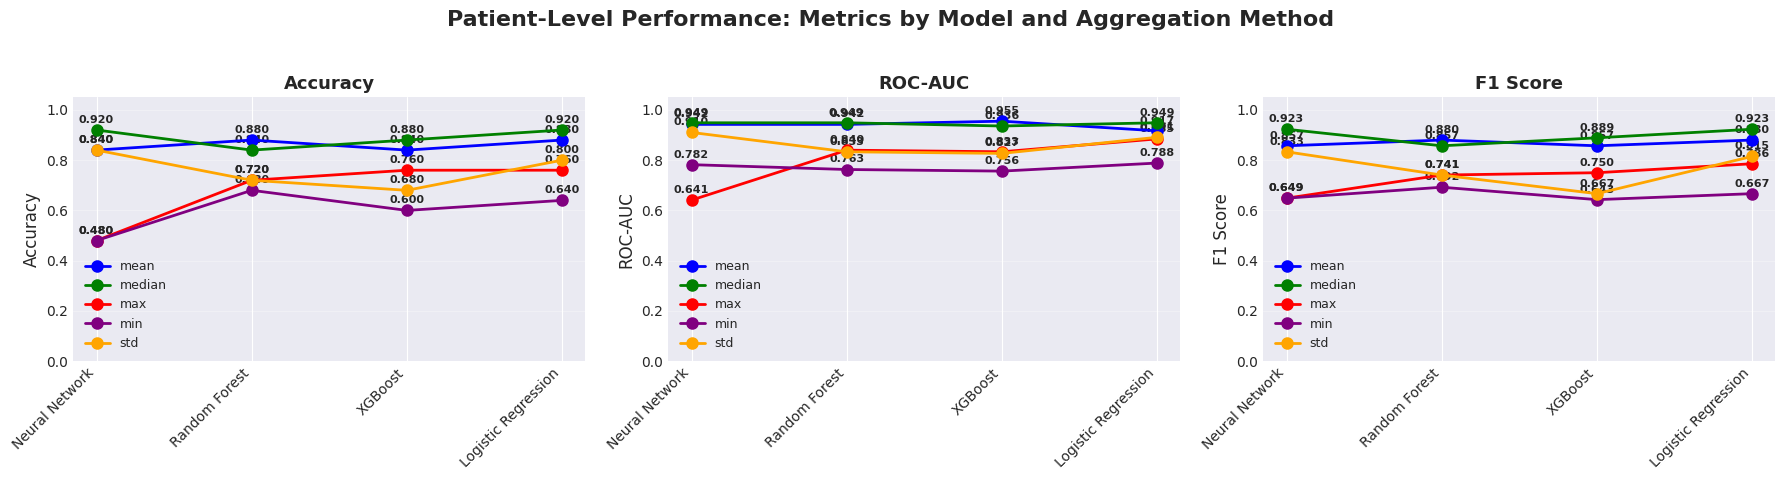

✓ Saved line chart visualization to: /home/Phenotype and Voice for PD/outputs/vae_standalone/patient_level_metrics_line_charts.png


In [49]:
# ============================================================
# Visualization: Patient-Level Results by Aggregation Method
# ============================================================

if len(patient_level_df) > 0:
    metrics = ['accuracy', 'roc_auc', 'f1']
    metric_labels = ['Accuracy', 'ROC-AUC', 'F1 Score']
    models = ['Neural Network', 'Random Forest', 'XGBoost', 'Logistic Regression']
    colors = {'mean': 'blue', 'median': 'green', 'max': 'red', 'min': 'purple', 'std': 'orange'}
    
    # Create figure with 3 subplots (one for each metric)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Patient-Level Performance: Metrics by Model and Aggregation Method', fontsize=16, fontweight='bold')
    
    # X-axis positions for models
    x_positions = np.arange(len(models))
    
    # Iterate over metrics
    for metric_idx, (metric, metric_label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[metric_idx]
        
        # Plot a line for each aggregation method
        for agg_method in PATIENT_AGG_METHODS:
            agg_values = []
            for model_name in models:
                model_results = patient_level_df[patient_level_df['model'] == model_name]
                agg_results = model_results[model_results['patient_aggregation'] == agg_method]
                if len(agg_results) > 0:
                    agg_values.append(agg_results[metric].values[0])
                else:
                    agg_values.append(np.nan)
            
            # Plot line connecting all models for this aggregation method
            valid_mask = ~np.isnan(agg_values)
            if valid_mask.any():
                ax.plot(x_positions[valid_mask], np.array(agg_values)[valid_mask], 
                       marker='o', color=colors[agg_method], label=agg_method,
                       linewidth=2, markersize=8, zorder=5)
                
                # Add value labels on points
                for i, val in enumerate(agg_values):
                    if not np.isnan(val):
                        ax.text(i, val + 0.02, f'{val:.3f}', 
                               ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(models, fontsize=10, rotation=45, ha='right')
        ax.set_ylabel(metric_label, fontsize=12)
        ax.set_title(metric_label, fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, 1.05])
        ax.legend(loc='best', fontsize=9, ncol=1)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(OUTPUT_DIR / 'patient_level_metrics_line_charts.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved line chart visualization to: {OUTPUT_DIR / 'patient_level_metrics_line_charts.png'}")
else:
    print("⚠ No results to visualize. Please run the training cell first.")
